# Anisotropy Processing

**Purpose:** Correct the signals from a spinning gold nanorod with 4-channel polarisation-resolved data, then reconstruct orientation and speed with the Fourkas model.

## Notebook workflow

| Step | Section | Description |
|------|---------|-------------|
| **1. Setup** | 1-2 | Imports and reusable model functions |
| **2. Data loading** | 3-4 | Select TDMS file and load raw channels |
| **3. SCMS ridge** | 5 | Geometric ridge extraction on (ax, ay) cloud |
| **4. Cycle detection** | 6 | Auto cycle window + manual override |
| **5. Track smoothing** | 7 | Savgol + B-spline + snap to SCMS ridge |
| **6. Phase lattice** | 8 | Arc-length phase lattice + nearest-match for shape fitting |
| **7. Channel correction** | 9 | Per-channel gain and T-matrix correction |
| **8. Fourkas calibration** | 10 | Set calibrated NA and compute A/B/C |
| **9. Shape fitting** | 11 | Alternating DE optimisation + L-BFGS-B polish |
| **10. Phase processing** | 12 | Apply fitted corrections and track continuous rotation phase |
| **11. Output figures** | 13 | Export figures (anisotropy, speed, lab angles) |

### Key variables to configure

- `tdms_path` -- path to input TDMS file (Section 3).
- `fit_start_s` / `fit_end_s` -- fit-window limits in seconds (Section 3).
- `a_manual` -- optional manual channel gains override (Section 3).
- `CYC_MANUAL_OVERRIDE` -- enable manual cycle slider (Section 6).
- `NA_CALIBRATED`, `USE_HOLE_CORRECTION`, `NA_in`, `NA_out` -- optical calibration controls (Section 10).
- `N_OUTER_ITERATIONS`, `DE_MAXITER`, `DE_POPSIZE`, `DE_TOL` -- shape-fit optimiser controls (Section 11).
- `PHASE_DECIMATION`, `PHASE_KDTREE_N_MODEL`, `PHASE_MAX_ROTATION_HZ`, `PHASE_WINDOW_SAFETY` -- continuity-constrained phase-tracking controls (Section 12).
- `data_t_start` / `data_t_end` -- processing window applied in Section 12.

#### For polarisation camera setup

- `a_manual = [1.0, 1.0, 1.0, 1.0]` can be used as a starting point.
- If needed, set `use_tmatrix = False` until your setup-specific T-matrix is calibrated.
- Replace `tdms_path` and the load logic in Section 4 with your acquisition pipeline.
- Use `NA = 1.3` as a default until calibration is available.
- For hole correction (Section 10), use `NA_in = 0.39` and `NA_out = 1.3` as the standard polarisation-camera annulus.


## Overview

The notebook reconstructs the orientation ($\theta$, $\phi$) and rotation speed of a single rotating gold nanorod from 4-channel polarisation-resolved intensity data, using the Fourkas anisotropy model.

### What corrections are applied

Three corrections sit between raw photon counts and a clean Fourkas anisotropy:

1. **Per-channel gain** `a = [a_90, a_45, a_135, a_0]` — per-detector amplitude differences. Setup-level; ideally calibrated once across many files. The default `a_manual` in Section 3 was characterised on 35+ rotor files (~2 % spread). A per-file fit (`a_manual = None`, Section 9) is available but only recommended for diagnostics; single-file gain fits scatter on dim or non-rotating tracks.
2. **T-matrix** `matcor` — 4×4 polarisation-mixing matrix that decouples nominal `0°/90°/45°/135°` channels from real instrument leakage. Also setup-level. The current matrix has residual off-diagonal coupling at the ~10 % level and is the leading source of `fa`/`fb` pegging in Section 11.
3. **Per-channel background** `b_0, b_90, b_45, b_135` — additive offsets fit per-file in Section 11, parameterised as `(dc, fa, fb)`.

The three corrections are not independent: small errors in gain or T-matrix are absorbed into the background fit and from there propagate into systematic bias on $\theta$ and $\phi$. Calibrating gain and T-matrix beforehand is therefore the most effective lever — the per-file background fit alone cannot compensate.

### How the background is fit

Background fitting (Sections 5–11) compares the *shape* of the data anisotropy cloud against the Fourkas-model family of closed curves, **assuming the rod rotates at a fixed cone half-angle around a fixed axis**. This is appropriate for bacterial flagellar motors and similar tethered rotors, but will misfit freely-rotating particles whose axis wanders on the timescale of the fit window. For such samples the shape-fit pipeline (Sections 5–11) needs to be replaced.

### Pipeline outline

- **Sections 5–8 — reference-cycle construction.** Build one clean closed curve in (a_x, a_y) space representing a single revolution.
    - **Section 5** runs SCMS on the full fit-window cloud (default ~1 s) to extract the geometric ridge, averaging over noise and the uneven angular sampling of individual revolutions.
    - **Section 6** detects one full revolution in the time-ordered raw trajectory (with a manual slider override when auto-detection fails).
    - **Section 7** smooths the cycle slice (Savgol + periodic B-spline) and snaps it onto the SCMS ridge — geometry from Section 5, ordering from Section 6.
    - **Section 8** lays an arc-length-uniform phase lattice on the merged track and assigns each phase sample its nearest raw point. The output is the phase-ordered fit subset.
- **Section 9 — channel correction.** Applies gain (from `a_manual` or fitted from the Section 8 subset) and T-matrix to produce the phase-ordered corrected channels used by the shape fit.
- **Section 10 — Fourkas calibration constants.** Computes A, B, C from the objective NA; annular (hole) path is on by default.
- **Section 11 — shape fit.** Joint optimisation of geometry $(\Theta_{\text{axis}}, \Phi_{\text{axis}}, \Lambda)$ and background $(dc, fa, fb)$ against the phase-ordered subset, via alternating differential evolution + L-BFGS-B polish.
- **Section 12 — full-window phase tracking.** Applies fitted corrections across the processing window and tracks continuous rotation phase with a KDTree + dynamic-programming matcher; a trajectory guard triggers geometry-only refits if the rod's axis drifts.
- **Section 13 — output figures.** Anisotropy shape, windowed speed, and lab-frame angle traces.


## TODO / planned diagnostics (not implemented yet)

### Shot-noise measurement

The four-channel detector is photon-counting; per-sample variance should follow Poisson statistics in the absence of excess instrument noise. Three independent ways to confirm and quantify:

(a) **Per-channel `var/mean` ratio.** Take a short window (a few ms — short enough that `theta`, `phi` barely move so rotational modulation is negligible), de-trend each channel with a low-order polynomial, and compute `var(residual) / mean(signal)`. Pure shot noise gives a constant ratio across windows of different mean intensity; growth with mean ⇒ multiplicative excess noise; constant offset above 1 ⇒ readout/dark contribution.

(b) **Allan deviation.** `Allan(τ) = ½·E[(x_{n+1}(τ) − x_n(τ))²]` over τ from 1 sample upward. White shot noise gives slope −1 in log Allan-σ vs τ; flattening or upturn at intermediate τ exposes 1/f or drift contributions. Five lines with `numpy.diff` on per-channel cumulative sums.

(c) **Spectral floor.** `scipy.signal.welch` per channel; the high-frequency plateau equals `2·mean·dt` (single-sided, photons² / Hz) under pure shot noise. Comparing measured plateau to predicted level gives "shot noise = X% of total variance".

Recommended order: (a) for a quick sanity check, then (c) for a quantitative figure.

### Smoothing of measured angle / speed

Once the shot-noise level is known per channel, propagate it through the Fourkas inversion to get the noise floor on `theta_lab`, `phi_lab`, and the windowed speed. Suggested calibration of the existing smoothers:

- **`PHASE_PSI_SAVGOL_WINDOW` (Section 12)** — pick the smallest window whose Savgol-smoothed `psi` σ matches the predicted shot-noise σ on `psi`. Anything larger blurs real rotation features; anything smaller leaves shot noise visible.
- **`speed_window_s` (Section 13 Figure 2)** — set so the window length equals roughly `5·σ_shot,psi / ω̇_target_resolution` where `ω̇` is the angular acceleration we want to resolve. For a steady rotor at ~50 Hz with shot-noise-dominated `psi`, 50 ms is usually a good starting point.
- **Cross-check against Allan deviation** of the unsmoothed `psi` — the smoothing window should sit at or below the τ where Allan-σ stops decreasing, so we are not smoothing through real motor dynamics.

### Open issue: bg fit pegging (`fa`/`fb` at ±1)

Tracked in `diagnostics_summary.md` and `Isum_background_response.md`. Short version: residual ~2 % `cos(2ψ)` component in pair-differences that the constant-bg model cannot capture. Recovery of single-rod `δa`, `δb` is unreliable until either (i) the T-matrix is recalibrated against a polarisation standard, or (ii) the wobble / rotating-bg hypotheses are tested. Geometry and phase tracking remain reliable in the meantime.

### Optical simulation for the complete hole effect (and maybe try to simulate noise and background as well)

## 1. Imports

In [193]:
from pathlib import Path
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from nptdms import TdmsFile
from scipy.optimize import minimize, differential_evolution

## 2. Function & model definitions

This cell defines all reusable functions and the physical models used throughout the notebook:

- **T-matrix correction** (`T_Icor_Matrix`) — 4×4 polarisation cross-talk correction matrix derived from measured optical transmission/reflection coefficients.
- **Channel gain fit** (`find_best_coeff_using_mat`) — finds per-channel multiplicative gains `[a_90, a_45, a_135]` by minimising the residual `(c0 + c90) - (c45 + c135)`.
- **Anisotropy** (`anisotropy_from_channels`) — computes `ax = (c0 - c90)/(c0 + c90)` and `ay = (c45 - c135)/(c45 + c135)`.
- **Fourkas model** (`fourkas_ABC`, `fourkas_template`) — coefficients A, B, C from the objective NA, and a forward model that generates the expected (ax, ay) closed curve for a rod spinning at cone half-angle Λ around axis (Θ, Φ).

In [194]:

# ── T correction matrix ───────────────────────────────────────────────────────
def T_Icor_Matrix():  # order: 0, 90, 45, 135, with 45 reflected
    ret = np.zeros([4, 4])
    ret[0][0] = 0.152  # transmitted
    ret[0][1] = 0
    ret[1][0] = 0
    ret[1][1] = 0.148  # reflected
    alpha = 0.455
    beta  = 0.009  # This is quite critical
    t     = 0.757  # transmitted in PBS
    r     = 0.741  # reflected
    ret[2][0] = -alpha * beta * r  # Reflected
    ret[2][1] =  alpha * beta * r
    ret[2][2] =  alpha * alpha * r
    ret[2][3] =  beta  * beta  * r
    ret[3][0] = -alpha * beta * t  # Transmitted
    ret[3][1] =  alpha * beta * t
    ret[3][2] =  beta  * beta  * t
    ret[3][3] =  alpha * alpha * t
    return np.linalg.inv(ret) / 8

# ── Gain fit ──────────────────────────────────────────────────────────────────
def _chcor_objective(params, ac, mat):
    a90, a45, a135 = params
    ap = np.copy(ac)
    ap[1, :] *= a90
    ap[2, :] *= a45
    ap[3, :] *= a135
    bc = np.dot(mat, ap)
    return np.sum((bc[0] + bc[1] - bc[2] - bc[3]) ** 2)

def find_best_coeff_using_mat(c0, c90, c45, c135, mat):
    ac = np.vstack((c0, c90, c45, c135)).astype(float)
    return minimize(partial(_chcor_objective, ac=ac, mat=mat), [1.0, 1.0, 1.0])

# ── Polarisation index mapping ────────────────────────────────────────────────
#   A small helper function to switch between different orders of polarizations 
#   depending on the conventions used.
_orientations = ["90", "45", "135", "0"]

def get_pol_ind(listpol):
    return [_orientations.index(p) for p in listpol]

# ── Pre-compute T matrix in stack order [c90, c45, c135, c0] ──────────────────
matcorb = T_Icor_Matrix()
_inds   = get_pol_ind(["0", "90", "45", "135"])
_Pmat   = np.zeros([4, 4])
for _i in range(4):
    _Pmat[_i, _inds[_i]] = 1
matcor = np.dot(np.linalg.inv(_Pmat), np.dot(matcorb, _Pmat))
del _inds, _Pmat, _i

# ── Anisotropy ────────────────────────────────────────────────────────────────
def anisotropy_from_channels(c0, c90, c45, c135):
    denom_x = c0 + c90
    denom_y = c45 + c135
    ax = np.where(denom_x > 0, (c0 - c90)   / denom_x, 0.0)
    ay = np.where(denom_y > 0, (c45 - c135) / denom_y, 0.0)
    return ax, ay

# ── Fourkas ───────────────────────────────────────────────────────────────────
def fourkas_ABC(alpha):
    """Coefficients A, B, C as functions of collection half-angle α."""
    ca = np.cos(alpha)
    A  = 1/6  - ca/4               + (ca**3)/12
    B  =        ca/8               - (ca**3)/8
    C  = 7/48 - ca/16 - (ca**2)/16 - (ca**3)/48
    return A, B, C

# ── Forward model: Rodrigues rotation + Fourkas ──────────────────────────────
def fourkas_template(Theta_axis_deg, Phi_axis_deg, Lambda_deg, A, B, C,
                     N_model=720):
    """Generate model anisotropy curve for given rotation geometry.

    Parameters
    ----------
    Theta_axis_deg, Phi_axis_deg : rotation axis direction (degrees)
    Lambda_deg                   : cone half-angle (degrees)
    A, B, C                      : Fourkas coefficients
    N_model                      : number of points on the model curve

    Returns
    -------
    ax_model, ay_model : arrays of shape (N_model,)
    """
    theta_ax = np.radians(Theta_axis_deg)
    phi_ax   = np.radians(Phi_axis_deg)
    lam      = np.radians(Lambda_deg)

    # Rotation axis unit vector
    kx = np.sin(theta_ax) * np.cos(phi_ax)
    ky = np.sin(theta_ax) * np.sin(phi_ax)
    kz = np.cos(theta_ax)
    k_hat = np.array([kx, ky, kz])

    # Orthonormal basis (k_hat, e1, e2)
    if abs(kz) < 0.9999:
        e1 = np.array([0.0, 0.0, 1.0]) - kz * k_hat
        e1 /= np.linalg.norm(e1)
    else:
        e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.cross(k_hat, e1)

    # Rodrigues rotation: d(ψ) = cos(Λ)·k̂ + sin(Λ)·[cos(ψ)·e1 + sin(ψ)·e2]
    psi = np.linspace(0.0, 2.0 * np.pi, N_model, endpoint=False)
    d = (  np.cos(lam) * k_hat[np.newaxis, :]
         + np.sin(lam) * (np.cos(psi)[:, np.newaxis] * e1[np.newaxis, :]
                        + np.sin(psi)[:, np.newaxis] * e2[np.newaxis, :]) )

    theta_psi = np.arccos(np.clip(d[:, 2], -1.0, 1.0))
    phi_psi   = np.arctan2(d[:, 1], d[:, 0])

    # Forward Fourkas: θ → r → (ax, ay)
    s2 = np.sin(theta_psi) ** 2
    r  = C * s2 / (A + B * s2)
    ax_model = r * np.cos(2.0 * phi_psi)
    ay_model = r * np.sin(2.0 * phi_psi)

    return ax_model, ay_model

### Why the rigid-rotation geometry has only 3 static parameters

`fourkas_template` parametrises the rod's long-axis direction $\hat{\mathbf m}(\psi)$ — the dipole the Fourkas signal sees — with $(\Theta_{\text{axis}}, \Phi_{\text{axis}}, \Lambda)$. A naive count would be **four**: 2 angles for the motor axis $\hat{\mathbf k}$ and 2 angles for the rod's lab-frame direction. The intuitive reason it collapses to three:

**Pick the rod's tip on the unit sphere.** A rigid rotation about $\hat{\mathbf k}$ moves that point along the latitude circle of $\hat{\mathbf k}$ that it sits on. The latitude is set by a single number — $\Lambda = \angle(\hat{\mathbf m}, \hat{\mathbf k})$ — and that latitude is **the only thing the loop shape depends on**. The longitudinal position around the latitude (call it $\alpha$) is just the starting point of the orbit; a different starting point traces the *same* circle, just with a relabelled zero of $\psi$.

So the would-be 4th parameter $\alpha$ is mathematically a phase shift between motor angle and signal phase — and the motor itself provides no independent zero of $\psi$, so the shift is unmeasurable. **Changing $\alpha$ never changes the $(a_x, a_y)$ loop, only where you say "$\psi = 0$" along it.**

Practical consequences:

- **How the rod is glued doesn't need its own parameter.** Radial, tangential, or anything in between — they all land at *some* $(\Lambda, \alpha)$ on the cone around $\hat{\mathbf k}$. $\Lambda$ is what we fit; $\alpha$ vanishes into a phase reference. A tangentially glued rod gives the **same loop shape** as a radially glued one at the same $\Lambda$, merely 90° out of phase in $\psi$.
- **The model assumes rigid rotation about a fixed $\hat{\mathbf k}$.** If $\Lambda$ varies within a cycle (wobble, hook flexion, axis drift), the static 3-parameter description fails — that is a *dynamical* failure, not a missing static DOF. The trajectory guard in Section 12 catches slow axis drift; intra-cycle wobble would need a time-dependent $\Lambda(\psi)$ extension.

See `Fourkas_simulation.ipynb` (last two cells) for an explicit numerical demo: starting from a 4-input description $(\Theta_{\text{axis}}, \Phi_{\text{axis}}, \theta_0, \phi_0)$ with no use of Λ/α, three different $(\theta_0, \phi_0)$ that share the same latitude on the cone produce one loop with three different $\psi=0$ marks; changing the latitude changes the loop shape.

## 3. File Selection and Configuration

Set the path to your TDMS file and choose the fit-window time range.

**User-configurable parameters:**
- `tdms_path` — full path to the `.tdms` data file.
- `a_manual` — per-channel gain in stack order `[a_90, a_45, a_135, a_0]`. Set to `None` to fall back to the data-driven fit in Section 9.
- `fit_start_s` / `fit_end_s` — fit-window range (seconds) used for reference extraction and parameter estimation.
- `dec_correction` — decimation factor for the fit window (`1` = no decimation).
- `use_tmatrix` — set `True` to apply T-matrix correction; set `False` for uncalibrated alternative setups.


In [195]:
# ── File ──────────────────────────────────────────────────────────────────────
tdms_path = Path(r"C:\Users\denny\workspace\pyqtrod\data\Patricia\20250311\file.tdms")

# ── Output folder detection ──────────────────────────────────────────────────
# Detect "data" folder in the path and replace with "data_analysed"
_tdms_parts = tdms_path.parts
try:
    _data_idx = list(_tdms_parts).index("data")
except ValueError:
    _data_idx = max(0, len(_tdms_parts) - 2)  # fallback: parent of file
_output_dir = Path(*_tdms_parts[:_data_idx]) / "data_analysed" / Path(*_tdms_parts[_data_idx+1:]).with_suffix("")
_output_dir.mkdir(parents=True, exist_ok=True)

# Relative filename (everything after \data\)
_relative_filename = str(Path(*_tdms_parts[_data_idx+1:]))

print(f"Output folder: {_output_dir}")
print(f"Relative name: {_relative_filename}")

# ── Channel-correction coefficients ──────────────────────────────────────────
# o, a all use the same physical stack order: [c90, c45, c135, c0]
#
# a: per-channel gain — set to None to auto-calculate from data
# a_manual = [1.08, 1.16, 1.02, 1.0]   # e.g. default [a_90, a_45, a_135, a_0] = [1.0, 1.2, 1.0, 1.0]
a_manual = None

# Time window for the coefficient fit (None = use all data)
fit_start_s    = 30.0
fit_end_s      = 31.0
dec_correction = 1   # decimation applied during the fit

# ── T-matrix correction toggle ───────────────────────────────────────────────
# Set to True to apply the optical T-matrix correction, False to skip it
use_tmatrix = True

print(f"File : {tdms_path.name}")
print(f"Exists: {tdms_path.exists()}")
print(f"T-matrix correction: {'ON' if use_tmatrix else 'OFF'}")

Output folder: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file
Relative name: Patricia\20250311\file.tdms
File : file.tdms
Exists: True
T-matrix correction: ON


## 4. Load raw data

Read four polarisation channels (0°, 90°, 45°, 135°) from the TDMS file and build the time axis.

In [196]:

# ── Load raw channel intensities from TDMS file ───────────────────────────────
tdms_obj  = TdmsFile.open(str(tdms_path))
group     = tdms_obj.groups()[0]
channels  = group.channels()
datasize  = len(channels[0])

try:
    time_inc = float(channels[0].properties["wf_increment"])
    time_off = float(channels[0].properties["wf_start_offset"])
except KeyError:
    time_inc = 4e-6
    time_off = 0.0
    print("Warning: no time metadata — using time_inc=4e-6 s")

freq   = 1.0 / time_inc
time_s = time_off + time_inc * np.arange(datasize)

idx      = get_pol_ind(["0", "90", "45", "135"])
c0_raw   = np.asarray(channels[idx[0]][:], dtype=float)
c90_raw  = np.asarray(channels[idx[1]][:], dtype=float)
c45_raw  = np.asarray(channels[idx[2]][:], dtype=float)
c135_raw = np.asarray(channels[idx[3]][:], dtype=float)

print(f"Loaded: {tdms_path.name}")
print(f"  {datasize:,} points  |  {freq:.0f} Hz  |  duration: {time_s[-1]:.1f} s")


Loaded: file.tdms
  77,750,000 points  |  250000 Hz  |  duration: 311.0 s


## 5. SCMS ridge extraction

Decimate raw channels over the fit window, compute raw anisotropy `_ax_raw, _ay_raw`, and run **Subspace Constrained Mean Shift (SCMS)** on the pooled `(ax, ay)` cloud to extract a clean geometric ridge.

Filters applied to the SCMS seeds:
- KDE density gate (`SCMS_DENSITY_PCTL`)
- Local-covariance anisotropy ratio gate (`SCMS_RATIO_MIN`)
- Connected-components filter (`SCMS_CONNECT_RADIUS`, `SCMS_CONNECT_MIN_SIZE`) drops stray singletons.

Output: `_ob_ridge` — the SCMS ridge geometry used by Section 7 for snapping.

> Note: SCMS is purely geometric. If your data has multiple revolutions over the same loop (e.g. near-vertical axis), the ridge is identical to a single-loop case; the loop count is handled by Section 8.


Fit window: 250000 decimated samples, t = 30.000 – 31.000 s
[Option B] SCMS: kept 3000/3000 ridge pts  (h=0.02, iters=25)
[Option B] connectivity: 145 comps, top sizes=[2633, 29, 25, 21, 21], kept 2779/3000 (radius=0.01, min_size=6)


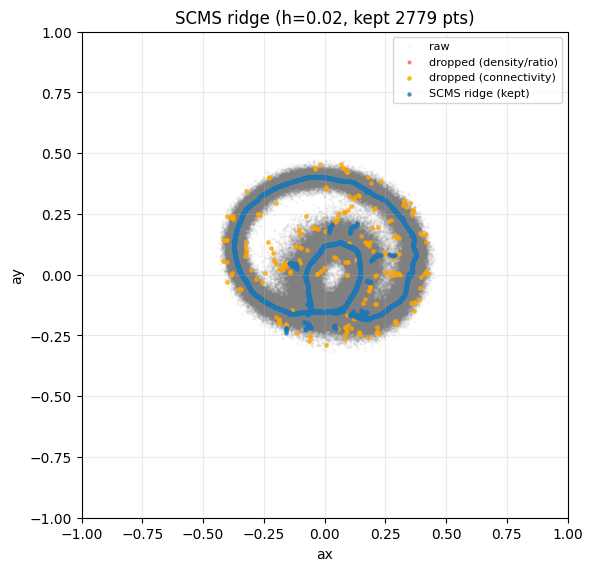

In [197]:
# ── Data preparation ──────────────────────────────────────────────────────────
# Decimate raw channels over the fit window and compute raw anisotropy.
N_SUBSAMPLE  = 90    # phase points fed to shape fitting (used by Section 8 too)
FORCE_UNIQUE = False # phase-lattice uniqueness (Section 8)

fit_s = int((fit_start_s - time_off) / time_inc) if fit_start_s is not None else 0
fit_e = int((fit_end_s   - time_off) / time_inc) if fit_end_s   is not None else datasize
fit_s = max(0, min(fit_s, datasize))
fit_e = max(fit_s, min(fit_e, datasize))

_c0_dec   = c0_raw [fit_s:fit_e:dec_correction]
_c90_dec  = c90_raw[fit_s:fit_e:dec_correction]
_c45_dec  = c45_raw[fit_s:fit_e:dec_correction]
_c135_dec = c135_raw[fit_s:fit_e:dec_correction]
_t_dec    = time_s [fit_s:fit_e:dec_correction]

_ax_raw, _ay_raw = anisotropy_from_channels(_c0_dec, _c90_dec, _c45_dec, _c135_dec)
if len(_t_dec) > 0:
    print(f"Fit window: {len(_ax_raw)} decimated samples, "
          f"t = {_t_dec[0]:.3f} – {_t_dec[-1]:.3f} s")

from scipy.spatial import cKDTree as _OB_KDTree
from scipy.signal import find_peaks as _OB_find_peaks, peak_widths as _OB_peak_widths
from scipy.signal import savgol_filter as _OB_savgol
from scipy.interpolate import splprep as _OB_splprep, splev as _OB_splev

# --- SCMS knobs (diagnostic background only) --------------------------------
SCMS_BANDWIDTH    = 0.020
SCMS_N_SEEDS      = 3000
SCMS_N_ITERS      = 25
SCMS_TOL          = 1e-5
SCMS_DATA_CAP     = 8000
SCMS_SEED_BATCH   = 500
SCMS_DENSITY_PCTL = 0
SCMS_RATIO_MIN    = 0
# --- connectivity filter: keep large connected components on ridge ----------
SCMS_CONNECT_RADIUS    = 0.01  # ridge pts within this distance are connected
SCMS_CONNECT_MIN_SIZE  = 6     # drop components with fewer than this many points (2 = drop singletons)
# --- cycle-detection knobs (ported from Fourkas_processing.ipynb) -----------
CYC_WINDOW        = 200
CYC_STEP          = 5
CYC_CLOSURE_FAC   = 1.0
CYC_SEARCH_LIMIT  = None
# --- cycle smoothing (Savgol on raw cycle, in time order, periodic) ---------
CYC_SAVGOL_WINDOW = 201   # odd, in raw samples (matches Fourkas_processing.ipynb)
CYC_SAVGOL_ORDER  = 3
# --- periodic B-spline smoothing of the closed cycle ------------------------
CYC_SPLINE_S      = 0.5   # splprep smoothing parameter (matches original)
# --- snap final spline curve onto SCMS ridge --------------------------------
CYC_SNAP_TO_SCMS    = True
# --- post-snap smoothing of the merged track --------------------------------
CYC_POST_SMOOTH     = True
CYC_POST_SAVGOL_WIN = 51   # odd, in merged-track samples
CYC_POST_SAVGOL_ORDER = 3
CYC_POST_SPLINE_S   = 0.05  # final periodic B-spline smoothing on snapped track
# --- merge-track resolution -------------------------------------------------
MERGE_TRACK_N     = max(4 * N_SUBSAMPLE, 480)


def _ob_scms(pts, h, n_seeds, n_iters, tol, data_cap, seed_batch):
    rng = np.random.default_rng(0)
    n = len(pts)
    if n > data_cap:
        sub = rng.choice(n, size=data_cap, replace=False)
        data = pts[sub]
    else:
        data = pts
    seed_idx = rng.choice(len(data), size=min(n_seeds, len(data)), replace=False)
    seeds = data[seed_idx].copy()
    inv2h2 = 1.0 / (2.0 * h * h)
    final_ratio = np.zeros(len(seeds))

    def _step(s_batch, store_ratio, ratio_out, idx0):
        diff = data[None, :, :] - s_batch[:, None, :]
        r2 = np.sum(diff * diff, axis=2)
        w = np.exp(-r2 * inv2h2)
        w_sum = w.sum(axis=1, keepdims=True) + 1e-30
        m = (w[:, :, None] * data[None, :, :]).sum(axis=1) / w_sum
        wt = w[:, :, None]
        cov = np.einsum("nij,nik->njk", wt * diff, diff) / w_sum[:, :, None]
        evals, evecs = np.linalg.eigh(cov)
        v_minor = evecs[:, :, 0]
        proj = np.sum((m - s_batch) * v_minor, axis=1, keepdims=True) * v_minor
        if store_ratio:
            ratio_out[idx0:idx0 + len(s_batch)] = (
                evals[:, 1] / np.maximum(evals[:, 0], 1e-30)
            )
        return s_batch + proj

    for it in range(n_iters):
        seeds_new = np.empty_like(seeds)
        store = (it == n_iters - 1)
        for b0 in range(0, len(seeds), seed_batch):
            b1 = min(b0 + seed_batch, len(seeds))
            seeds_new[b0:b1] = _step(seeds[b0:b1], store, final_ratio, b0)
        max_step = np.max(np.linalg.norm(seeds_new - seeds, axis=1))
        seeds = seeds_new
        if max_step < tol:
            if not store:
                for b0 in range(0, len(seeds), seed_batch):
                    b1 = min(b0 + seed_batch, len(seeds))
                    _step(seeds[b0:b1], True, final_ratio, b0)
            break

    density = np.empty(len(seeds))
    for b0 in range(0, len(seeds), seed_batch):
        b1 = min(b0 + seed_batch, len(seeds))
        diff = data[None, :, :] - seeds[b0:b1, None, :]
        r2 = np.sum(diff * diff, axis=2)
        density[b0:b1] = np.exp(-r2 * inv2h2).sum(axis=1)
    return seeds, final_ratio, density


def _ob_detect_cycle(ax, ay, window=200, search_limit=None, step=5, closure_factor=1.0):
    traj = np.column_stack([ax, ay])
    n = len(traj)
    if search_limit is None:
        search_limit = min(n // 2, 100_000)
    start_idx = 0
    ref_tree = _OB_KDTree(traj[start_idx:start_idx + window])
    n_sample = max(2, window // 10)
    dists_close = np.linalg.norm(
        traj[start_idx] - traj[start_idx:start_idx + n_sample], axis=1)
    dist_thresh = np.median(dists_close) * closure_factor
    i_list = np.arange(start_idx + window, start_idx + search_limit, step)
    if len(i_list) == 0:
        return start_idx, min(start_idx + search_limit, n)
    scores = []
    for i in i_list:
        end = min(i + window, n)
        tree2 = _OB_KDTree(traj[i:end])
        scores.append(tree2.count_neighbors(ref_tree, dist_thresh))
    scores = np.array(scores, dtype=float)
    prom_div = 2
    peaks = np.array([], dtype=int)
    while len(peaks) == 0 and prom_div < 128:
        peaks = _OB_find_peaks(scores, prominence=window / prom_div)[0]
        prom_div *= 2
    if len(peaks) == 0:
        return start_idx, int(i_list[np.argmax(scores)])
    _, _, _, right_ips = _OB_peak_widths(scores, peaks, rel_height=0.5)
    right_ips = np.round(right_ips).astype(int)
    peak_ind = 0
    while peak_ind < len(peaks) - 1:
        if np.min(scores[: peaks[peak_ind]]) > 2 * np.min(scores):
            peak_ind += 1
        else:
            break
    for k in range(peak_ind, min(peak_ind + 3, len(peaks))):
        if scores[peaks[k]] > 1.5 * scores[peaks[peak_ind]]:
            peak_ind = k
    end_idx = i_list[min(right_ips[peak_ind], len(i_list) - 1)]
    return int(start_idx), int(end_idx)


def _ob_smooth_cycle_2d(ax_seg, ay_seg, smoothing=0.5, num_points=500,
                        resample_n=500):
    """Periodic B-spline smooth of a 2-D cycle (matches Fourkas_processing.ipynb)."""
    pts = np.column_stack([ax_seg, ay_seg])
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])
    diffs = np.diff(pts, axis=0)
    seg_len = np.hypot(diffs[:, 0], diffs[:, 1])
    cum_arc = np.concatenate([[0], np.cumsum(seg_len)])
    total_arc = cum_arc[-1]
    if total_arc == 0:
        return ax_seg, ay_seg
    arc_uniform = np.linspace(0, total_arc, resample_n, endpoint=False)
    rx = np.interp(arc_uniform, cum_arc, pts[:, 0], period=total_arc)
    ry = np.interp(arc_uniform, cum_arc, pts[:, 1], period=total_arc)
    pts_uniform = np.column_stack([rx, ry])
    pts_uniform = np.vstack([pts_uniform, pts_uniform[0]])
    if smoothing is None:
        smoothing = 0.01 * resample_n
    tck, _ = _OB_splprep(pts_uniform.T, per=True, s=smoothing)
    u = np.linspace(0, 1, num_points, endpoint=False)
    sx, sy = _OB_splev(u, tck)
    return np.asarray(sx), np.asarray(sy)


# 1) SCMS ridge (diagnostic shape, background only)
_ob_pool = np.column_stack([_ax_raw, _ay_raw])
_ob_pool = _ob_pool[np.all(np.isfinite(_ob_pool), axis=1)]
_ob_seeds, _ob_ratio, _ob_density = _ob_scms(
    _ob_pool, SCMS_BANDWIDTH, SCMS_N_SEEDS, SCMS_N_ITERS, SCMS_TOL,
    SCMS_DATA_CAP, SCMS_SEED_BATCH,
)
_ob_d_thr = np.percentile(_ob_density, SCMS_DENSITY_PCTL)
_ob_keep = (_ob_density >= _ob_d_thr) & (_ob_ratio >= SCMS_RATIO_MIN)
_ob_ridge_pre = _ob_seeds[_ob_keep]
print(f"[Option B] SCMS: kept {_ob_keep.sum()}/{len(_ob_seeds)} ridge pts  "
      f"(h={SCMS_BANDWIDTH}, iters={SCMS_N_ITERS})")

# --- connectivity filter: keep large connected components -------------------
from scipy.sparse import csr_matrix as _OB_csr
from scipy.sparse.csgraph import connected_components as _OB_cc
if len(_ob_ridge_pre) > 1:
    _ob_ctree = _OB_KDTree(_ob_ridge_pre)
    _ob_pairs = _ob_ctree.query_pairs(r=SCMS_CONNECT_RADIUS, output_type="ndarray")
    _ob_nr = len(_ob_ridge_pre)
    if len(_ob_pairs):
        rows = np.concatenate([_ob_pairs[:, 0], _ob_pairs[:, 1]])
        cols = np.concatenate([_ob_pairs[:, 1], _ob_pairs[:, 0]])
        data = np.ones(len(rows), dtype=np.uint8)
        _ob_graph = _OB_csr((data, (rows, cols)), shape=(_ob_nr, _ob_nr))
    else:
        _ob_graph = _OB_csr((_ob_nr, _ob_nr))
    _ob_ncomp, _ob_labels = _OB_cc(_ob_graph, directed=False)
    _ob_sizes = np.bincount(_ob_labels)
    _ob_keep_lbl = np.where(_ob_sizes >= SCMS_CONNECT_MIN_SIZE)[0]
    _ob_cc_mask = np.isin(_ob_labels, _ob_keep_lbl)
    _ob_ridge = _ob_ridge_pre[_ob_cc_mask]
    print(f"[Option B] connectivity: {_ob_ncomp} comps, top sizes="
          f"{sorted(_ob_sizes.tolist(), reverse=True)[:5]}, kept "
          f"{_ob_cc_mask.sum()}/{len(_ob_ridge_pre)} "
          f"(radius={SCMS_CONNECT_RADIUS}, min_size={SCMS_CONNECT_MIN_SIZE})")
else:
    _ob_ridge = _ob_ridge_pre
    _ob_cc_mask = np.ones(len(_ob_ridge_pre), dtype=bool)

# -- Diagnostics: SCMS ridge --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.scatter(_ax_raw, _ay_raw, s=1, alpha=0.06, c='grey', rasterized=True, label='raw')
ax.scatter(_ob_seeds[~_ob_keep, 0], _ob_seeds[~_ob_keep, 1], s=4, c='red', alpha=0.4,
           label='dropped (density/ratio)')
ax.scatter(_ob_ridge_pre[~_ob_cc_mask, 0], _ob_ridge_pre[~_ob_cc_mask, 1], s=6, c='orange',
           alpha=0.7, label='dropped (connectivity)')
ax.scatter(_ob_ridge[:, 0], _ob_ridge[:, 1], s=5, c='tab:blue', alpha=0.7,
           label='SCMS ridge (kept)')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal')
ax.set_xlabel('ax'); ax.set_ylabel('ay'); ax.grid(alpha=0.25)
ax.set_title(f'SCMS ridge (h={SCMS_BANDWIDTH}, kept {len(_ob_ridge)} pts)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6. Cycle detection (auto + manual override)

Detects one full revolution `[_ob_cyc_start, _ob_cyc_end]` in the time-ordered raw `(_ax_raw, _ay_raw)` trajectory using `_ob_detect_cycle` (KD-tree closure score on a sliding window).

**Manual override:** if auto detection fails, set `CYC_MANUAL_OVERRIDE = True` to display interactive sliders for manually selecting the cycle indices. After clicking *Apply selection*, re-run Section 9 to rebuild the merged track from the new cycle.


[Option B] cycle window: [0, 1395]  (1395 samples / 250000)
Manual override ON but no indices set — use the slider, then paste the printed values into CYC_MANUAL_START / CYC_MANUAL_END for next time.


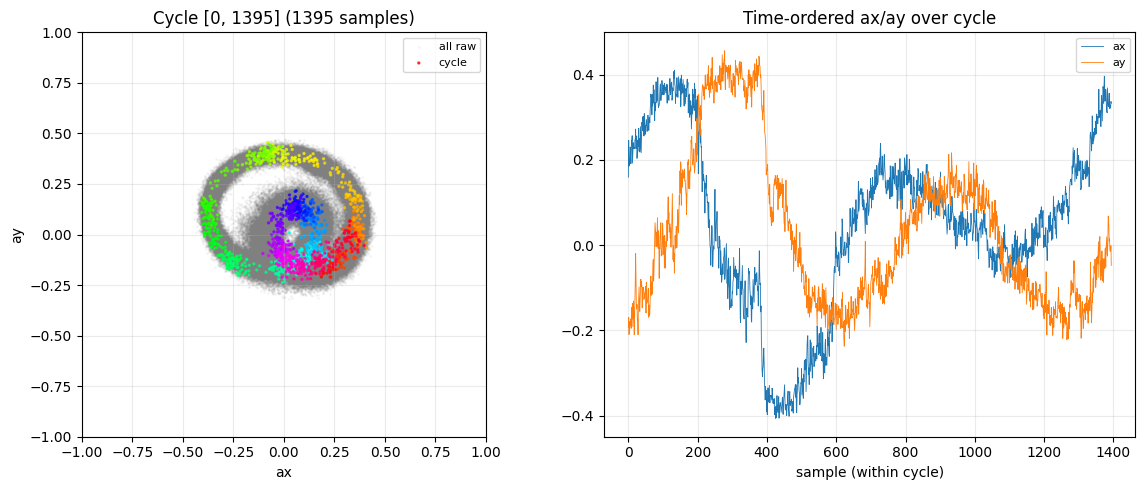

In [198]:
# 2) Cycle detection on RAW time-ordered trajectory
_ob_cyc_start, _ob_cyc_end = _ob_detect_cycle(
    _ax_raw, _ay_raw,
    window=CYC_WINDOW, step=CYC_STEP,
    search_limit=CYC_SEARCH_LIMIT, closure_factor=CYC_CLOSURE_FAC,
)
_ob_n_cyc = _ob_cyc_end - _ob_cyc_start
print(f"[Option B] cycle window: [{_ob_cyc_start}, {_ob_cyc_end}]  "
      f"({_ob_n_cyc} samples / {len(_ax_raw)})")
if _ob_n_cyc < 20:
    raise RuntimeError("Option B cycle window too short; check fit_start/end.")

# -- Manual cycle override (optional fallback) -------------------------------
# Set CYC_MANUAL_OVERRIDE = True to enable manual cycle selection. Then:
#   - If CYC_MANUAL_START and CYC_MANUAL_END are BOTH set (not None), use them
#     directly — no slider. Use this on re-runs once you know the indices.
#   - If either is None, display interactive sliders to pick the indices. After
#     clicking 'Apply selection', copy the printed start/end into
#     CYC_MANUAL_START / CYC_MANUAL_END so the next run skips the slider.
CYC_MANUAL_OVERRIDE = True
CYC_MANUAL_START = None   # int index, or None to use the slider
CYC_MANUAL_END   = None   # int index, or None to use the slider

if CYC_MANUAL_OVERRIDE and (CYC_MANUAL_START is not None) and (CYC_MANUAL_END is not None):
    # Direct manual indices — no slider.
    _ob_cyc_start = int(CYC_MANUAL_START)
    _ob_cyc_end   = int(max(_ob_cyc_start + 1, int(CYC_MANUAL_END)))
    _ob_cyc_start = int(np.clip(_ob_cyc_start, 0, len(_ax_raw) - 2))
    _ob_cyc_end   = int(np.clip(_ob_cyc_end, _ob_cyc_start + 1, len(_ax_raw)))
    _ob_n_cyc = _ob_cyc_end - _ob_cyc_start
    if _ob_n_cyc < 20:
        raise RuntimeError(
            f"Manual cycle window too short ({_ob_n_cyc} samples). "
            "Widen CYC_MANUAL_START / CYC_MANUAL_END."
        )
    print(f"Manual cycle indices: [{_ob_cyc_start}, {_ob_cyc_end}] "
          f"({_ob_n_cyc} samples). Slider skipped.")
elif CYC_MANUAL_OVERRIDE:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    print("Manual override ON but no indices set — use the slider, then paste the "
          "printed values into CYC_MANUAL_START / CYC_MANUAL_END for next time.")

    _n_dec = len(_ax_raw)
    _slider_start = widgets.IntSlider(
        value=_ob_cyc_start, min=0, max=_n_dec - 1, step=1,
        description='Start idx:', continuous_update=False,
        layout=widgets.Layout(width='90%'),
        style={'description_width': '80px'},
    )
    _slider_end = widgets.IntSlider(
        value=_ob_cyc_end, min=1, max=_n_dec, step=1,
        description='End idx:', continuous_update=False,
        layout=widgets.Layout(width='90%'),
        style={'description_width': '80px'},
    )
    _plot_out = widgets.Output()
    _status_out = widgets.Output()

    def _redraw(*_args):
        s, e = _slider_start.value, max(_slider_start.value + 1, _slider_end.value)
        with _plot_out:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
            axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.1, c='grey',
                            rasterized=True, label='all decimated')
            axes[0].scatter(_ax_raw[s:e], _ay_raw[s:e], s=2, alpha=0.5,
                            c='tab:blue', rasterized=True, label='selected')
            axes[0].set(xlabel='ax', ylabel='ay', title='Cycle selection',
                        xlim=(-1, 1), ylim=(-1, 1), aspect='equal')
            axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

            axes[1].plot(_ax_raw[s:e], '-', lw=0.6, c='tab:blue', label='ax')
            axes[1].plot(_ay_raw[s:e], '-', lw=0.6, c='tab:orange', label='ay')
            axes[1].set(xlabel='sample (within selection)', title='Time-ordered ax/ay')
            axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
            plt.tight_layout(); plt.show()

    def _apply(btn):
        global _ob_cyc_start, _ob_cyc_end, _ob_n_cyc
        _ob_cyc_start = int(_slider_start.value)
        _ob_cyc_end   = int(max(_ob_cyc_start + 1, _slider_end.value))
        _ob_n_cyc = _ob_cyc_end - _ob_cyc_start
        with _status_out:
            clear_output(wait=True)
            print(f"Applied manual cycle: [{_ob_cyc_start}, {_ob_cyc_end}]  "
                  f"({_ob_n_cyc} samples).  Re-run Section 9 to rebuild the merged track.")
            print(f"To skip the slider next time, set:")
            print(f"    CYC_MANUAL_START = {_ob_cyc_start}")
            print(f"    CYC_MANUAL_END   = {_ob_cyc_end}")

    # Clear observers left over from a previous run of this cell before
    # re-registering — otherwise re-running stacks duplicate listeners and
    # each slider move fires several redraws (multiple plots appear).
    _slider_start.unobserve_all()
    _slider_end.unobserve_all()
    _slider_start.observe(_redraw, names='value')
    _slider_end.observe(_redraw, names='value')

    _apply_btn = widgets.Button(description='Apply selection', button_style='success',
                                icon='check', layout=widgets.Layout(width='200px'))
    _apply_btn.on_click(_apply)

    _redraw()
    display(widgets.VBox([_slider_start, _slider_end, _apply_btn, _status_out, _plot_out]))
else:
    print(f"Manual override disabled — using auto-detected cycle "
          f"[{_ob_cyc_start}, {_ob_cyc_end}] ({_ob_n_cyc} samples).")

# -- Diagnostics: cycle window on raw cloud ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.06, c='grey', rasterized=True, label='all raw')
axes[0].scatter(_ax_raw[_ob_cyc_start:_ob_cyc_end], _ay_raw[_ob_cyc_start:_ob_cyc_end],
                s=2, c=np.linspace(0, 1, _ob_n_cyc), cmap='hsv', alpha=0.7, label='cycle')
axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1); axes[0].set_aspect('equal')
axes[0].set_xlabel('ax'); axes[0].set_ylabel('ay'); axes[0].grid(alpha=0.25)
axes[0].set_title(f'Cycle [{_ob_cyc_start}, {_ob_cyc_end}] ({_ob_n_cyc} samples)')
axes[0].legend(fontsize=8)
axes[1].plot(_ax_raw[_ob_cyc_start:_ob_cyc_end], '-', lw=0.6, c='tab:blue', label='ax')
axes[1].plot(_ay_raw[_ob_cyc_start:_ob_cyc_end], '-', lw=0.6, c='tab:orange', label='ay')
axes[1].set_xlabel('sample (within cycle)'); axes[1].grid(alpha=0.25)
axes[1].set_title('Time-ordered ax/ay over cycle')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Cycle smoothing and snap to ridge

Builds the final merged trajectory from the cycle slice:

1. **Periodic Savgol** (`CYC_SAVGOL_WINDOW`) on the raw cycle slice — denoised time-ordered trajectory.
2. **Periodic B-spline** (`splprep(per=True, s=CYC_SPLINE_S)`) — closed smooth curve resampled uniformly in arc length.
3. **Snap** each spline sample to its nearest SCMS ridge point (geometry from Section 5, ordering from the Section 6 cycle slice / periodic B-spline).
4. **Post-snap smoothing** (Savgol + B-spline) for a clean closed curve.

Output: `_sx_merge_track`, `_sy_merge_track` — used by Section 8 (phase lattice).


[Option B] Savgol smoothing: window=201 samples, order=3
[Option B] merged track: 480 pts (spline -> snapped to SCMS ridge)
[Option B] post-smooth: Savgol win=51, spline s=0.05 -> 480 pts


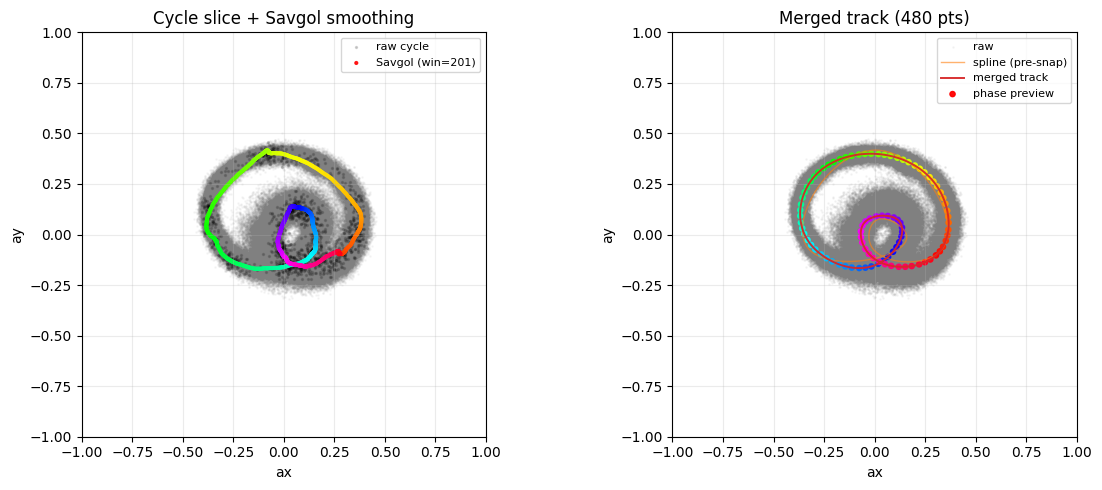

In [199]:
# 3) Periodic Savgol smoothing of the raw cycle slice (in time order)
_ob_cx_raw = _ax_raw[_ob_cyc_start:_ob_cyc_end]
_ob_cy_raw = _ay_raw[_ob_cyc_start:_ob_cyc_end]
_ob_sg_win = min(CYC_SAVGOL_WINDOW, _ob_n_cyc // 2 * 2 - 1)
if _ob_sg_win < CYC_SAVGOL_ORDER + 2:
    _ob_sg_win = CYC_SAVGOL_ORDER + 2
    if _ob_sg_win % 2 == 0:
        _ob_sg_win += 1
_ob_cx_sm = _OB_savgol(_ob_cx_raw, _ob_sg_win, CYC_SAVGOL_ORDER, mode="wrap")
_ob_cy_sm = _OB_savgol(_ob_cy_raw, _ob_sg_win, CYC_SAVGOL_ORDER, mode="wrap")
print(f"[Option B] Savgol smoothing: window={_ob_sg_win} samples, "
      f"order={CYC_SAVGOL_ORDER}")

# 4) Periodic B-spline smoothing of the closed cycle (matches original)
_ob_sx_spl, _ob_sy_spl = _ob_smooth_cycle_2d(
    _ob_cx_sm, _ob_cy_sm,
    smoothing=CYC_SPLINE_S,
    num_points=MERGE_TRACK_N,
    resample_n=max(MERGE_TRACK_N, 500),
)

# 5) Snap smooth spline onto SCMS ridge (geometry from SCMS, ordering from cycle)
if CYC_SNAP_TO_SCMS and len(_ob_ridge) > 0:
    _ob_tree = _OB_KDTree(_ob_ridge)
    _, _ob_nn = _ob_tree.query(np.column_stack([_ob_sx_spl, _ob_sy_spl]))
    _sx_merge_track = _ob_ridge[_ob_nn, 0]
    _sy_merge_track = _ob_ridge[_ob_nn, 1]
    print(f"[Option B] merged track: {len(_sx_merge_track)} pts (spline -> snapped to SCMS ridge)")
else:
    _sx_merge_track, _sy_merge_track = _ob_sx_spl, _ob_sy_spl
    print(f"[Option B] merged track: {len(_sx_merge_track)} pts (periodic B-spline, s={CYC_SPLINE_S})")
_touch_pt = None  # not used by Option B

# 6) Post-snap smoothing: Savgol (periodic) + final B-spline on the merged track
if CYC_POST_SMOOTH and len(_sx_merge_track) > CYC_POST_SAVGOL_ORDER + 2:
    _ob_post_n = len(_sx_merge_track)
    _ob_post_win = min(CYC_POST_SAVGOL_WIN, _ob_post_n - (1 - _ob_post_n % 2))
    if _ob_post_win % 2 == 0:
        _ob_post_win -= 1
    if _ob_post_win < CYC_POST_SAVGOL_ORDER + 2:
        _ob_post_win = CYC_POST_SAVGOL_ORDER + 2
        if _ob_post_win % 2 == 0:
            _ob_post_win += 1
    _sx_merge_track = _OB_savgol(_sx_merge_track, _ob_post_win, CYC_POST_SAVGOL_ORDER, mode="wrap")
    _sy_merge_track = _OB_savgol(_sy_merge_track, _ob_post_win, CYC_POST_SAVGOL_ORDER, mode="wrap")
    _sx_merge_track, _sy_merge_track = _ob_smooth_cycle_2d(
        _sx_merge_track, _sy_merge_track,
        smoothing=CYC_POST_SPLINE_S,
        num_points=MERGE_TRACK_N,
        resample_n=max(MERGE_TRACK_N, 500),
    )
    print(f"[Option B] post-smooth: Savgol win={_ob_post_win}, spline s={CYC_POST_SPLINE_S} -> {len(_sx_merge_track)} pts")

# -- Diagnostics: merged track ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
_ob_t_color = np.linspace(0, 1, _ob_n_cyc)
axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.05, c='grey', rasterized=True)
axes[0].scatter(_ob_cx_raw, _ob_cy_raw, s=2, c='black', alpha=0.15, label='raw cycle')
axes[0].scatter(_ob_cx_sm, _ob_cy_sm, s=4, c=_ob_t_color, cmap='hsv', alpha=0.85,
                label=f'Savgol (win={_ob_sg_win})')
axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1); axes[0].set_aspect('equal')
axes[0].set_xlabel('ax'); axes[0].set_ylabel('ay'); axes[0].grid(alpha=0.25)
axes[0].set_title('Cycle slice + Savgol smoothing'); axes[0].legend(fontsize=8)

axes[1].scatter(_ax_raw, _ay_raw, s=1, alpha=0.06, c='grey', rasterized=True, label='raw')
axes[1].plot(_ob_sx_spl, _ob_sy_spl, '-', c='tab:orange', lw=1.0, alpha=0.6, label='spline (pre-snap)')
axes[1].plot(_sx_merge_track, _sy_merge_track, '-', c='tab:red', lw=1.4, alpha=0.95,
             label='merged track')
_ob_lat = np.linspace(0, len(_sx_merge_track), N_SUBSAMPLE, endpoint=False).astype(int)
axes[1].scatter(_sx_merge_track[_ob_lat], _sy_merge_track[_ob_lat],
                s=14, c=np.linspace(0, 1, N_SUBSAMPLE), cmap='hsv', alpha=0.95,
                label='phase preview')
axes[1].set_xlim(-1, 1); axes[1].set_ylim(-1, 1); axes[1].set_aspect('equal')
axes[1].set_xlabel('ax'); axes[1].set_ylabel('ay'); axes[1].grid(alpha=0.25)
axes[1].set_title(f'Merged track ({len(_sx_merge_track)} pts)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. Phase lattice and nearest-match

Build `N_SUBSAMPLE` arc-length-evenly spaced phase samples on the merged trajectory from Section 7, anchor phase 0 at the leftmost sample, and assign each phase point its nearest raw point from the full fit window.

The matched arrays (`c0_fit`, `c90_fit`, `c45_fit`, `c135_fit` and `_ax_sub`, `_ay_sub`) are explicitly **ordered by merged-track phase**, not by acquisition time. Channel correction (Section 9) and shape fitting (Section 11) consume them in this order.

### Why arc-length spacing here (and not in Section 12)

The phase lattice in this section is **uniform in arc length** along the closed (a_x, a_y) curve. The shape-fit cost in Section 11 weighs every region of the curve equally, so each lattice point must subtend the same arc. Sampling uniformly in $\psi$ here would over-weight slow-moving stretches and under-weight the fast-moving ones.

Section 12 uses the opposite convention: the template there is regenerated uniform in $\psi$ via `fourkas_template`, because the goal at that stage is to recover $\psi$ for each data point.

### `FORCE_UNIQUE` — when to keep it OFF

`FORCE_UNIQUE` (set in Section 5) controls whether the nearest-match step requires a **distinct** raw point per phase sample. Default: `False`.

- **Single-loop case** (typical): either setting works; `True` slightly improves diversity at sparse phases.
- **Double-loop / multi-traversal case** (e.g. near-vertical axis $\Theta_{\text{axis}} \approx 0$ where the anisotropy ring is traversed twice per mechanical revolution, or a manually selected window in Section 6 covering ≥ 2 traversals of the same closed curve): **must keep `FORCE_UNIQUE = False`**. Phase indices `i` and `i + N/2` then sit at the same geometric location and would compete for the same nearest raw points; uniqueness starves half the lattice and inflates match distances. Closest-distance assignment (the `False` path) is the correct behaviour — each phase sample independently picks its best raw match, and the channel intensities at those raw points are still genuine data the model should reproduce.
- **Sparse fit window** (`fit_end_s - fit_start_s` short relative to one rotation): `False`, for the same starvation reason.


Phase-matching for shape fitting:
  source: merged track
  N phase points: 90
  phase parameterization: one full 0..2pi turn on the selected merged trajectory
  matched unique raw points: 90/90
  distance: mean=0.0005, max=0.0013
  fit arrays rebuilt: 90 points (phase-ordered)


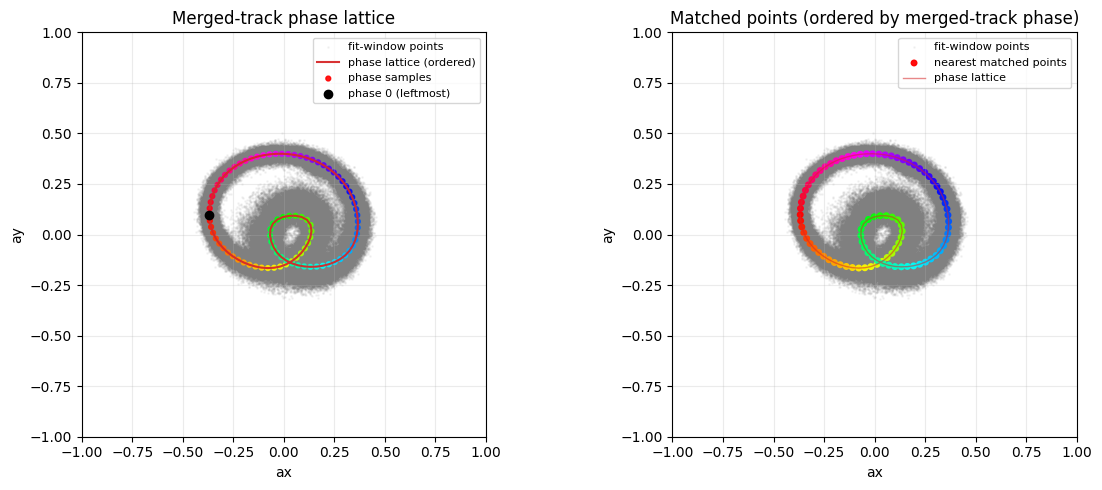

In [200]:
# ── Phase-ordered matching from merged track (for shape fitting) ───────────────
# Build N_SUBSAMPLE evenly spaced phase points on the merged track, set phase 0 to
# the leftmost merged-track point, and match each phase point to its nearest raw
# point over the full fit window. The selected fit arrays are ordered by merged-track
# phase (not by original time/index order).

if ('_sx_merge_track' not in globals()) or (_sx_merge_track is None) or (len(_sx_merge_track) < 3):
    raise RuntimeError(
        "Merged trajectory `_sx_merge_track` is not available. "
        "Run the reference-extraction cell first."
    )

_sx_phase_src = np.asarray(_sx_merge_track, dtype=float)
_sy_phase_src = np.asarray(_sy_merge_track, dtype=float)

_phase_pts0 = np.column_stack([_sx_phase_src, _sy_phase_src])

# Remove duplicated closure point if present.
if np.linalg.norm(_phase_pts0[0] - _phase_pts0[-1]) < 1e-12:
    _phase_pts0 = _phase_pts0[:-1]

# Closed arc-length parametrization.
_phase_closed = np.vstack([_phase_pts0, _phase_pts0[0]])
_phase_dxy = np.diff(_phase_closed, axis=0)
_phase_ds = np.hypot(_phase_dxy[:, 0], _phase_dxy[:, 1])
_phase_s = np.concatenate([[0.0], np.cumsum(_phase_ds)])
_phase_L = float(_phase_s[-1])
if _phase_L <= 1e-12:
    raise RuntimeError('Phase source has near-zero arc length.')

# Uniform phase lattice with endpoint=False (last point is one step before wrap).
_phase_su = np.linspace(0.0, _phase_L, N_SUBSAMPLE, endpoint=False)
_sx_phase = np.interp(_phase_su, _phase_s, _phase_closed[:, 0])
_sy_phase = np.interp(_phase_su, _phase_s, _phase_closed[:, 1])

# Enforce phase=0 at the leftmost sampled phase point.
_i_left = int(np.argmin(_sx_phase))
_sx_ref = np.roll(_sx_phase, -_i_left)
_sy_ref = np.roll(_sy_phase, -_i_left)

_ref_pts = np.column_stack([_sx_ref, _sy_ref])
_raw_pts_full = np.column_stack([_ax_raw, _ay_raw])
_all_d = np.linalg.norm(_raw_pts_full[None, :, :] - _ref_pts[:, None, :], axis=2)

_matched_idx = np.argmin(_all_d, axis=1)
_matched_dist = _all_d[np.arange(N_SUBSAMPLE), _matched_idx]

# Optional uniqueness across matched raw points (kept distance-optimal greedily).
if FORCE_UNIQUE:
    _order = np.argsort(_matched_dist)
    _taken = np.zeros(len(_ax_raw), dtype=bool)
    _idx_u = np.empty_like(_matched_idx)
    for _ri in _order:
        _j = int(_matched_idx[_ri])
        if not _taken[_j]:
            _idx_u[_ri] = _j
            _taken[_j] = True
        else:
            _cand = np.argsort(_all_d[_ri])
            for _jj in _cand:
                if not _taken[_jj]:
                    _idx_u[_ri] = int(_jj)
                    _taken[_jj] = True
                    break
    _matched_idx = _idx_u
    _matched_dist = np.linalg.norm(_raw_pts_full[_matched_idx] - _ref_pts, axis=1)

# Keep these arrays explicitly phase-ordered for downstream shape fitting.
_phase_order = np.arange(N_SUBSAMPLE)
_phase_frac = _phase_order / float(N_SUBSAMPLE)

_ax_sub = _ax_raw[_matched_idx]
_ay_sub = _ay_raw[_matched_idx]
_n_unique = len(np.unique(_matched_idx))

c0_fit = _c0_dec[_matched_idx]
c90_fit = _c90_dec[_matched_idx]
c45_fit = _c45_dec[_matched_idx]
c135_fit = _c135_dec[_matched_idx]

print('Phase-matching for shape fitting:')
print('  source: merged track')
print(f'  N phase points: {N_SUBSAMPLE}')
print('  phase parameterization: one full 0..2pi turn on the selected merged trajectory')
print(f'  matched unique raw points: {_n_unique}/{N_SUBSAMPLE}')
print(f'  distance: mean={np.mean(_matched_dist):.4f}, max={np.max(_matched_dist):.4f}')
print(f'  fit arrays rebuilt: {len(c0_fit)} points (phase-ordered)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
axes[0].scatter(_ax_raw, _ay_raw, s=1, alpha=0.07, c='grey', rasterized=True, label='fit-window points')
axes[0].plot(_sx_ref, _sy_ref, '-', c='tab:red', lw=1.5, alpha=0.95, label='phase lattice (ordered)')
axes[0].scatter(_sx_ref, _sy_ref, s=12, c=np.linspace(0, 1, N_SUBSAMPLE), cmap='hsv', alpha=0.9, label='phase samples')
axes[0].scatter(_sx_ref[0], _sy_ref[0], s=36, c='k', zorder=5, label='phase 0 (leftmost)')
axes[0].set_title('Merged-track phase lattice')
axes[0].legend(fontsize=8)

axes[1].scatter(_ax_raw, _ay_raw, s=1, alpha=0.07, c='grey', rasterized=True, label='fit-window points')
axes[1].scatter(_ax_sub, _ay_sub, s=16, c=_phase_frac, cmap='hsv', alpha=0.95, label='nearest matched points')
axes[1].plot(_sx_ref, _sy_ref, '-', c='tab:red', lw=1.0, alpha=0.55, label='phase lattice')
axes[1].set_title('Matched points (ordered by merged-track phase)')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.set_xlabel('ax')
    ax.set_ylabel('ay')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Channel correction

Builds the per-channel gain vector `a = [a_90, a_45, a_135, a_0]` and applies gain → T-matrix to produce `tcor_fit_sub` for shape fitting.

- **If `a_manual` is set** (recommended) the gain values from Section 3 are used directly. No per-file gain fit is run. This is the default behaviour because the instrument gain has been characterised across many files and rotors and is stable to ~2 %.
- **If `a_manual is None`** the cell falls back to `find_best_coeff_using_mat`, which solves `a_90, a_45, a_135` from the phase-ordered fit subset.

If any channel goes negative after gain application, a warning is printed — usually indicates dropouts/blinks in the raw signal that should be masked out upstream.


In [201]:
# ── Channel correction (phase-ordered fit segment) ────────────────────────────
# c0_fit, c90_fit, c45_fit, c135_fit are built in Section 8 from merged-track phase matching.

# Stack-order index map [c0, c90, c45, c135] -> positions in the [c90, c45, c135, c0] stack.
# Used here and re-used by all downstream cells operating on `tcor_*` stacks.
_idx_fit = get_pol_ind(["0", "90", "45", "135"])

if not use_tmatrix:
    matcor = np.eye(4)
    print("T-matrix correction disabled — using identity matrix.")

if a_manual is not None:
    a = list(a_manual)
    print(f"Channel correction: using manual a = {[f'{v:.4f}' for v in a]}")
else:
    gain_fit = find_best_coeff_using_mat(c0_fit, c90_fit, c45_fit, c135_fit, matcorb)
    l90, l45, l135 = gain_fit.x
    a = [1.0, 1.0, 1.0, 1.0]
    a[get_pol_ind(["90"])[0]] = float(l90)
    a[get_pol_ind(["45"])[0]] = float(l45)
    a[get_pol_ind(["135"])[0]] = float(l135)
    print(f"Channel correction: computed a = {[f'{v:.4f}' for v in a]}")

print(f"Gain   a = {[f'{v:.4g}' for v in a]}")
if any(v < 0 for v in a):
    print(f"WARNING: negative channel coefficient — {a}")

fit_stack = np.vstack((c90_fit, c45_fit, c135_fit, c0_fit)).astype(float)
for i in range(4):
    fit_stack[i] = a[i] * fit_stack[i]

_neg_per_ch = [int(np.sum(fit_stack[i] < 0)) for i in range(4)]
if any(_neg_per_ch):
    _ch_labels = ["c90", "c45", "c135", "c0"]
    print("WARNING: negative samples after gain in fit segment — "
          + ", ".join(f"{lbl}={n}" for lbl, n in zip(_ch_labels, _neg_per_ch))
          + " (consider masking dropouts upstream).")


tcor_fit_sub = np.dot(matcor, fit_stack)
del fit_stack

print(f"Gain + T-matrix applied to fit segment ({tcor_fit_sub.shape[1]} pts).")

Channel correction: computed a = ['0.8347', '1.1477', '1.2666', '1.0000']
Gain   a = ['0.8347', '1.148', '1.267', '1']
Gain + T-matrix applied to fit segment (90 pts).


## 10. Fourkas calibration constants

Set `NA_CALIBRATED` (effective NA from your calibration procedure) and refractive index `nw`.
Computes the Fourkas A, B, C coefficients and the saturation anisotropy radius `R_sat = C / (A + B)`.

### Hole-correction toggle

Set `USE_HOLE_CORRECTION = True` to switch from the legacy full-cone Fourkas formula to an
**annular-collection** path that integrates over the actual BFP annulus (inner hole to outer rim).

| Parameter | Meaning | Default |
|-----------|---------|--------|
| `USE_HOLE_CORRECTION` | Enable annular (hole) path | `True` |
| `NA_out` | Outer numerical aperture of collection annulus | `1.3` |
| `NA_in`  | Inner numerical aperture (hole edge) | `0.38` |

**Annular integrals** (beta = aperture polar angle):

$$J_1 = \int_{\alpha_{in}}^{\alpha_{out}} \left[2\cos^2\beta + \tfrac{3}{4}\sin^4\beta\right]\sin\beta\,d\beta$$
$$J_2 = \int_{\alpha_{in}}^{\alpha_{out}} \tfrac{1}{4}\sin^4\beta\,\sin\beta\,d\beta$$
$$J_3 = \int_{\alpha_{in}}^{\alpha_{out}} \sin^2\beta\cos^2\beta\,\sin\beta\,d\beta$$

**Mapping to Fourkas A, B, C:**
$$C = J_1 - J_2, \quad A = 2J_3, \quad B = J_1 + J_2 - 2J_3$$


In [202]:
# ── Fourkas calibration constants ─────────────────────────────────────────────
from scipy.integrate import quad

NA_CALIBRATED = 1.28671   # effective NA from calibration (original NA = 1.3)
nw            = 1.33      # refractive index of immersion medium

# ── Hole-correction toggle ─────────────────────────────────────────────────────
USE_HOLE_CORRECTION = True  # set True to use annular (hole) collection path

# Annular collection NA limits (only used when USE_HOLE_CORRECTION = True)
NA_out = 1.3    # outer NA of collection annulus
NA_in  = 0.38   # inner NA (hole edge)

if USE_HOLE_CORRECTION:
    # ── Annular (hole) path ────────────────────────────────────────────────────
    alpha_out = np.arcsin(NA_out / nw)   # outer half-angle
    alpha_in  = np.arcsin(NA_in  / nw)   # inner half-angle (hole)

    # Integrands (integration variable beta = aperture polar angle)
    J1, _ = quad(lambda b: (2*np.cos(b)**2 + 0.75*np.sin(b)**4) * np.sin(b),
                 alpha_in, alpha_out)
    J2, _ = quad(lambda b: 0.25 * np.sin(b)**4 * np.sin(b),
                 alpha_in, alpha_out)
    J3, _ = quad(lambda b: np.sin(b)**2 * np.cos(b)**2 * np.sin(b),
                 alpha_in, alpha_out)

    # Map annular J-values to Fourkas-style coefficients
    C_cal = J1 - J2
    A_cal = 2 * J3
    B_cal = J1 + J2 - 2 * J3

    print(f"Hole correction ON  (NA_in={NA_in}, NA_out={NA_out}, n={nw})")
    print(f"alpha_in={np.degrees(alpha_in):.4f}\u00b0  alpha_out={np.degrees(alpha_out):.4f}\u00b0")
    print(f"J1={J1:.6f}  J2={J2:.6f}  J3={J3:.6f}")
else:
    # ── Legacy path (full-cone Fourkas) ───────────────────────────────────────
    alpha_calib   = np.arcsin(NA_CALIBRATED / nw)
    A_cal, B_cal, C_cal = fourkas_ABC(alpha_calib)

    print(f"Hole correction OFF — legacy Fourkas path")
    print(f"NA_calibrated = {NA_CALIBRATED}  (original NA = 1.3)")
    print(f"\u03b1 = {np.degrees(alpha_calib):.4f}\u00b0")

R_SAT = C_cal / (A_cal + B_cal)

print(f"A={A_cal:.6f}  B={B_cal:.6f}  C={C_cal:.6f}")
print(f"r_sat = {R_SAT:.5f}")

_c0_fc   = tcor_fit_sub[_idx_fit[0]]
_c90_fc  = tcor_fit_sub[_idx_fit[1]]
_c45_fc  = tcor_fit_sub[_idx_fit[2]]
_c135_fc = tcor_fit_sub[_idx_fit[3]]

_ax_fit, _ay_fit = anisotropy_from_channels(_c0_fc, _c90_fc, _c45_fc, _c135_fc)

print(f"\nFit segment: {tcor_fit_sub.shape[1]:,} points")
print(f"Anisotropy range: ax \u2208 [{_ax_fit.min():.4f}, {_ax_fit.max():.4f}],  "
      f"ay \u2208 [{_ay_fit.min():.4f}, {_ay_fit.max():.4f}]")


Hole correction ON  (NA_in=0.38, NA_out=1.3, n=1.33)
alpha_in=16.6015°  alpha_out=77.8075°
J1=0.826623  J2=0.082060  J3=0.128657
A=0.257315  B=0.651368  C=0.744563
r_sat = 0.81939

Fit segment: 90 points
Anisotropy range: ax ∈ [-0.2996, 0.4308],  ay ∈ [-0.2032, 0.3663]


## 11. Shape fitting

Core optimisation cell. Fits 6 parameters to the phase-ordered anisotropy fit subset (`N_SUBSAMPLE = 90` phase-ordered points from the merged-track lattice in Section 8):

| Parameter | Meaning |
|-----------|---------|
| **Theta_axis** | Polar angle of the rotation axis (degrees) |
| **Phi_axis** | Azimuthal angle of the rotation axis (degrees) |
| **Lambda** | Cone half-angle (degrees) |
| **dc** | Total per-channel background intensity (sum of paired backgrounds) |
| **fa** | Fractional 0°/90° background asymmetry |
| **fb** | Fractional 45°/135° background asymmetry |

**Background parametrization.** Backgrounds for the four polarisation channels are derived from `(dc, fa, fb)` as

$$b_0 = \tfrac{dc + fa\cdot dc}{2},\quad b_{90} = \tfrac{dc - fa\cdot dc}{2},\quad b_{45} = \tfrac{dc + fb\cdot dc}{2},\quad b_{135} = \tfrac{dc - fb\cdot dc}{2}$$

so `dc` is the *sum* of paired channel backgrounds (`b_0 + b_90 = b_45 + b_135 = dc`) and `fa`, `fb ∈ [-1, 1]` set the asymmetry within each pair.

**Algorithm:** Alternating differential evolution (DE):
1. geometry fit with background fixed;
2. background fit with geometry fixed;
then repeated for `N_OUTER_ITERATIONS`, followed by joint L-BFGS-B polish.

The reported 1σ uncertainties come from a finite-difference Hessian of the cost at the optimum and are approximate (the cost has interpolation/`min(fwd,rev)` discontinuities).

Tune with: `N_OUTER_ITERATIONS`, `DE_MAXITER`, `DE_POPSIZE`, `DE_TOL`.

**Known caveat — `fa`/`fb` pegging.** On many real files the background asymmetries `fa` and/or `fb` converge to ±1 (the bound). This is a residual symptom of the gain × T-matrix × background degeneracy: with the current T-matrix, the optimiser absorbs uncorrected off-diagonal coupling into the asymmetry parameters. Geometry (`Theta_axis`, `Phi_axis`, `Lambda`) and the per-channel backgrounds reconstruct correctly even when this happens, so downstream phase tracking should be unaffected.

Fit channel data for shape fitting: 90 points
Model phase domain: fourkas_template uses psi in [0, 2pi) for each evaluation (N_model=720 in fit).
δc upper bound: 0.4217

Running 4-iteration alternating optimization:
  Stage 1: DE on (Θ, Φ, Λ) with background fixed
  Stage 2: DE on (δc, fa, fb) with geometry fixed

Outer iteration 1/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.0000, fa=0.0000, fb=0.0000
    → Θ=9.13°  Φ=42.51°  Λ=18.37°  cost=0.006989
  Stage 2: fit (δc, fa, fb) | fixed Θ=9.13°, Φ=42.51°, Λ=18.37°
    → δc=0.0386  fa=1.0000  fb=-0.1663  cost=0.001667
Outer iteration 2/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.0386, fa=1.0000, fb=-0.1663
    → Θ=9.70°  Φ=45.70°  Λ=19.23°  cost=0.001042
  Stage 2: fit (δc, fa, fb) | fixed Θ=9.70°, Φ=45.70°, Λ=19.23°
    → δc=0.0386  fa=1.0000  fb=-0.1794  cost=0.001041
Outer iteration 3/4
  Stage 1: fit (Θ, Φ, Λ) | fixed δc=0.0386, fa=1.0000, fb=-0.1794
    → Θ=9.70°  Φ=-133.89°  Λ=19.22°  cost=0.00104
  Stage 2: fit (δc, fa, fb) | fixed Θ=9.70°

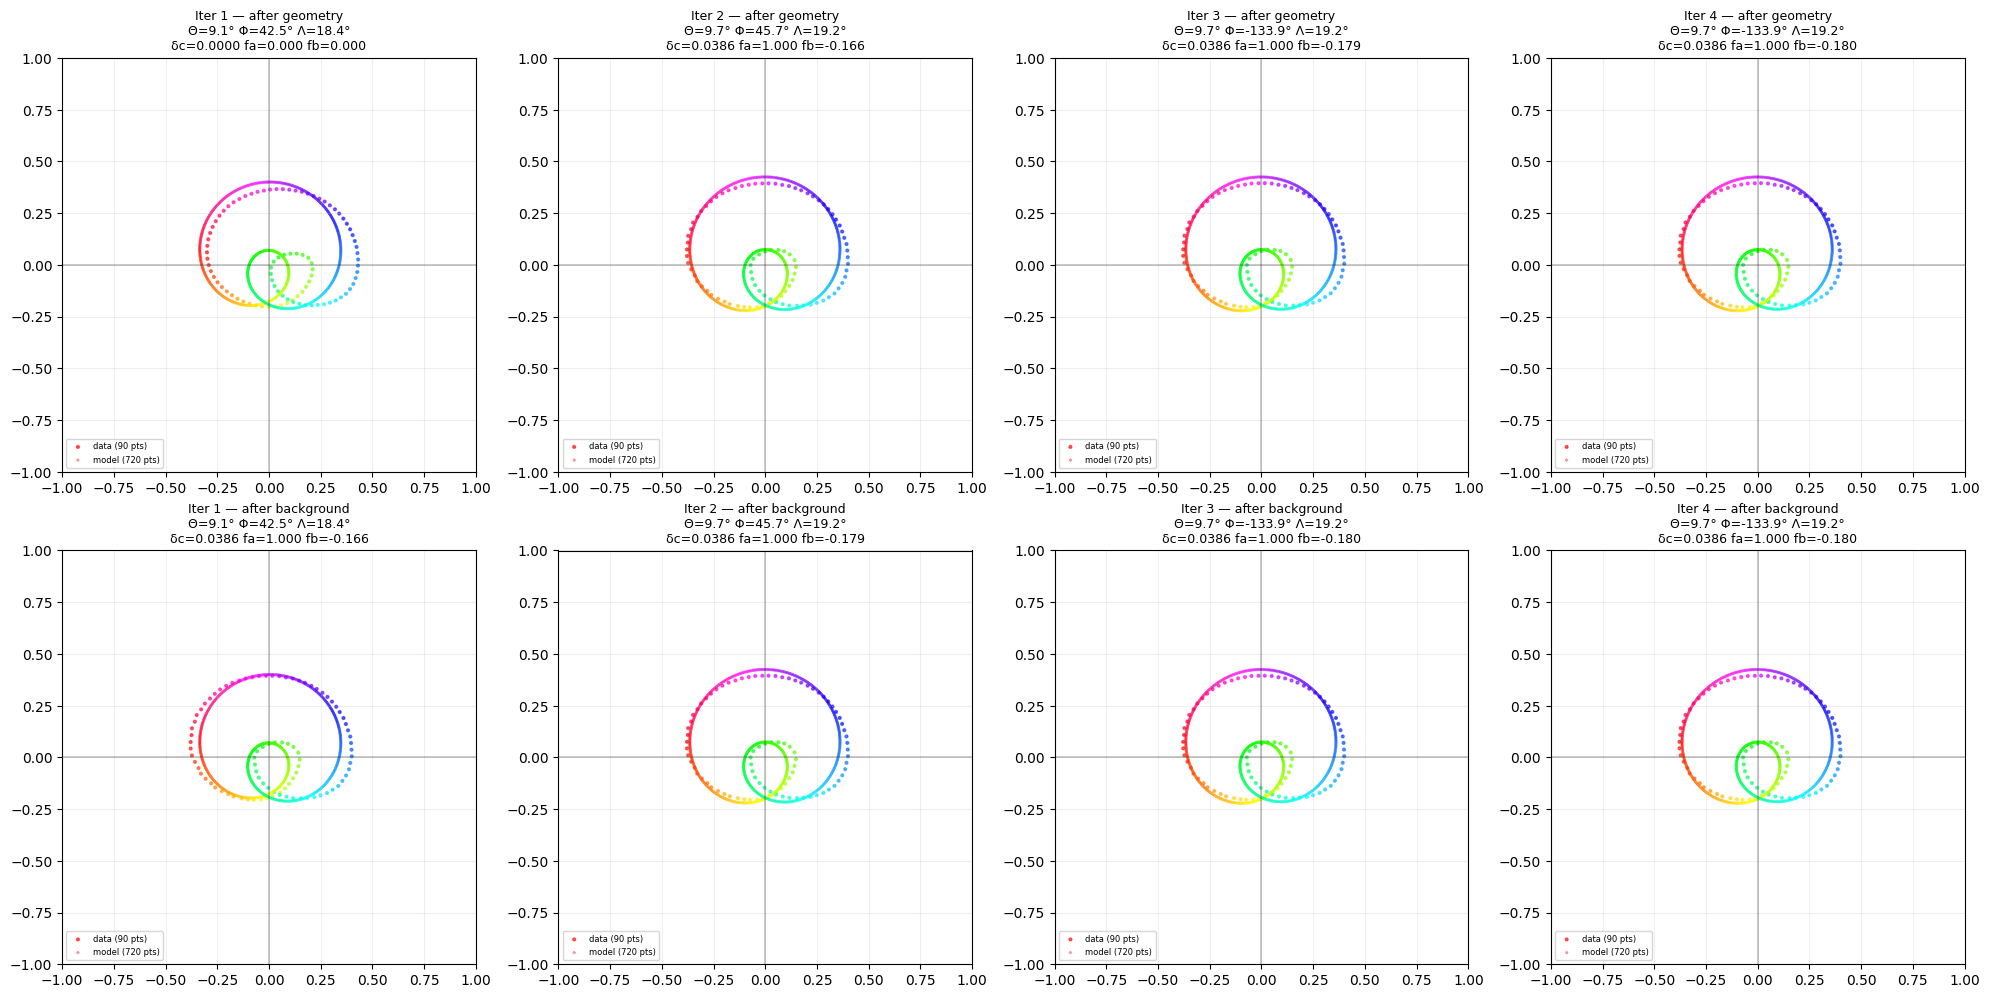


Final fit:
Θ_axis = 9.695°
Φ_axis = -133.885°
Λ      = 19.219°
δc     = 0.038566
fa     = 1.000000
fb     = -0.179684
Cost   = 0.00104011

Derived channel backgrounds:
b0   = 0.038566
b90  = 0.000000
b45  = 0.015818
b135 = 0.022748

Approximate 1σ uncertainties (Hessian inverse):
σ(Θ_axis) = 0.004403
σ(Φ_axis) = 0.004403
σ(Λ)      = 0.004403
σ(δc)     = 0.001142
σ(fa)     = 0.001142
σ(fb)     = 11.66


In [203]:
# ══════════════════════════════════════════════════════════════════════════════
# SHAPE FIT — Arc-length matching with two-stage alternating optimisation
# ══════════════════════════════════════════════════════════════════════════════
# tcor_fit_sub contains the phase-ordered fit segment (gain + T-matrix
# corrected). We use all points directly for the fit.

# ── User-configurable optimisation parameters ────────────────────────────
N_OUTER_ITERATIONS = 4
DE_MAXITER = 200
DE_POPSIZE = 15
DE_TOL     = 1e-6
N_SHAPE_FIT_RESAMPLE = 360  # uniform arc-length samples used in shape_fit_cost

# ── Arc-length helpers ───────────────────────────────────────────────────────
def _cumulative_arclen(ax, ay):
    dx = np.diff(ax)
    dy = np.diff(ay)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate([[0.0], np.cumsum(ds)])
    total = s[-1]
    if total > 0:
        s /= total
    return s

def _reorder_from_leftmost(ax, ay):
    i0 = int(np.argmin(ax))
    return np.roll(ax, -i0), np.roll(ay, -i0)

def _interp_curve_at_fractions(ax, ay, fracs):
    s = _cumulative_arclen(ax, ay)
    return np.interp(fracs, s, ax), np.interp(fracs, s, ay)

def _resample_uniform_arclen_closed(ax, ay, n):
    """Return n samples uniformly spaced in arc length on the closed curve."""
    ax_c = np.concatenate([ax, ax[:1]])
    ay_c = np.concatenate([ay, ay[:1]])
    s = _cumulative_arclen(ax_c, ay_c)
    fracs = np.linspace(0.0, 1.0, n, endpoint=False)
    return np.interp(fracs, s, ax_c), np.interp(fracs, s, ay_c)

# ── Extract fit-segment channel data ─────────────────────────────────────
_c0_cyc   = tcor_fit_sub[_idx_fit[0]]
_c90_cyc  = tcor_fit_sub[_idx_fit[1]]
_c45_cyc  = tcor_fit_sub[_idx_fit[2]]
_c135_cyc = tcor_fit_sub[_idx_fit[3]]

print(f"Fit channel data for shape fitting: {len(_c0_cyc)} points")
print("Model phase domain: fourkas_template uses psi in [0, 2pi) for each evaluation (N_model=720 in fit).")

# ── Cost function — arc-length matched residuals ─────────────────────────
def shape_fit_cost(params, cyc_c0, cyc_c90, cyc_c45, cyc_c135, A, B, C):
    Theta_ax, Phi_ax, Lam, dc, fa, fb = params
    da = fa * dc
    db = fb * dc
    b0   = (dc + da) / 2
    b90  = (dc - da) / 2
    b45  = (dc + db) / 2
    b135 = (dc - db) / 2

    c0_adj   = cyc_c0 - b0
    c90_adj  = cyc_c90 - b90
    c45_adj  = cyc_c45 - b45
    c135_adj = cyc_c135 - b135

    valid = (c0_adj > 0) & (c90_adj > 0) & (c45_adj > 0) & (c135_adj > 0)
    if valid.sum() < 20:
        return 1e6

    ax_d = (c0_adj[valid] - c90_adj[valid]) / (c0_adj[valid] + c90_adj[valid])
    ay_d = (c45_adj[valid] - c135_adj[valid]) / (c45_adj[valid] + c135_adj[valid])

    ax_d_r, ay_d_r = _reorder_from_leftmost(ax_d, ay_d)

    ax_m, ay_m = fourkas_template(Theta_ax, Phi_ax, Lam, A, B, C, N_model=720)
    if len(ax_m) < 5:
        return 1e6
    ax_m_r, ay_m_r = _reorder_from_leftmost(ax_m, ay_m)

    # Resample BOTH data and model to a common uniform arc-length grid so
    # the comparison is parameterisation-consistent (both uniform in arc
    # length, anchored at the leftmost point).
    n_match = max(int(N_SHAPE_FIT_RESAMPLE), len(ax_d_r))
    ax_d_u, ay_d_u = _resample_uniform_arclen_closed(ax_d_r, ay_d_r, n_match)
    ax_m_u, ay_m_u = _resample_uniform_arclen_closed(ax_m_r, ay_m_r, n_match)
    cost_fwd = np.mean((ax_d_u - ax_m_u)**2 + (ay_d_u - ay_m_u)**2)

    ax_m_rev_r, ay_m_rev_r = _reorder_from_leftmost(ax_m[::-1], ay_m[::-1])
    ax_m_rev_u, ay_m_rev_u = _resample_uniform_arclen_closed(ax_m_rev_r, ay_m_rev_r, n_match)
    cost_rev = np.mean((ax_d_u - ax_m_rev_u)**2 + (ay_d_u - ay_m_rev_u)**2)

    return min(cost_fwd, cost_rev)

# ── δc upper bound ───────────────────────────────────────────────────────
dc_upper = max(0.0, min(float(np.min(_c0_cyc) + np.min(_c90_cyc)),
                        float(np.min(_c45_cyc) + np.min(_c135_cyc))))
print(f"δc upper bound: {dc_upper:.4f}")

# ── Parameter bounds ─────────────────────────────────────────────────────
_bounds_geom = [(0.0, 90.0), (-180.0, 180.0), (0.0, 90.0)]
_bounds_bg   = [(0.0, dc_upper), (-1.0, 1.0), (-1.0, 1.0)]  # fa, fb in [-1, 1] keeps b_k >= 0.
_bounds_all  = _bounds_geom + _bounds_bg

def _geom_cost(geom_params, dc, fa, fb, ec0, ec90, ec45, ec135, A, B, C):
    return shape_fit_cost([*geom_params, dc, fa, fb], ec0, ec90, ec45, ec135, A, B, C)

def _bg_cost(bg_params, Theta, Phi, Lam, ec0, ec90, ec45, ec135, A, B, C):
    return shape_fit_cost([Theta, Phi, Lam, *bg_params], ec0, ec90, ec45, ec135, A, B, C)

# ── Alternating optimization with diagnostics ────────────────────────────
_cur_dc, _cur_fa, _cur_fb = 0.0, 0.0, 0.0
_cur_Th, _cur_Ph, _cur_Lm = 45.0, 0.0, 20.0

print(f"\nRunning {N_OUTER_ITERATIONS}-iteration alternating optimization:")
print("  Stage 1: DE on (Θ, Φ, Λ) with background fixed")
print("  Stage 2: DE on (δc, fa, fb) with geometry fixed\n")

_diag_axes = plt.subplots(2, N_OUTER_ITERATIONS, figsize=(5 * N_OUTER_ITERATIONS, 10), dpi=100)[1]

for _outer in range(N_OUTER_ITERATIONS):
    print(f"{'='*70}")
    print(f"Outer iteration {_outer+1}/{N_OUTER_ITERATIONS}")
    print(f"{'='*70}")

    print(f"  Stage 1: fit (Θ, Φ, Λ) | fixed δc={_cur_dc:.4f}, fa={_cur_fa:.4f}, fb={_cur_fb:.4f}")
    _res_geom = differential_evolution(
        _geom_cost,
        bounds=_bounds_geom,
        args=(_cur_dc, _cur_fa, _cur_fb,
              _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc,
              A_cal, B_cal, C_cal),
        maxiter=DE_MAXITER, popsize=DE_POPSIZE, tol=DE_TOL,
        seed=42 + _outer, polish=True, disp=False, workers=1,
    )
    _cur_Th, _cur_Ph, _cur_Lm = _res_geom.x
    print(f"    → Θ={_cur_Th:.2f}°  Φ={_cur_Ph:.2f}°  Λ={_cur_Lm:.2f}°  cost={_res_geom.fun:.4g}")

    _da_d = _cur_fa * _cur_dc
    _db_d = _cur_fb * _cur_dc
    _c0_d   = _c0_cyc   - (_cur_dc + _da_d) / 2
    _c90_d  = _c90_cyc  - (_cur_dc - _da_d) / 2
    _c45_d  = _c45_cyc  - (_cur_dc + _db_d) / 2
    _c135_d = _c135_cyc - (_cur_dc - _db_d) / 2
    _v_d = (_c0_d > 0) & (_c90_d > 0) & (_c45_d > 0) & (_c135_d > 0)
    _ax_d = (_c0_d[_v_d] - _c90_d[_v_d]) / (_c0_d[_v_d] + _c90_d[_v_d])
    _ay_d = (_c45_d[_v_d] - _c135_d[_v_d]) / (_c45_d[_v_d] + _c135_d[_v_d])

    _ax_mr, _ay_mr = fourkas_template(_cur_Th, _cur_Ph, _cur_Lm, A_cal, B_cal, C_cal, N_model=720)

    _ax_d_r, _ay_d_r = _reorder_from_leftmost(_ax_d, _ay_d)
    _s_d_diag = _cumulative_arclen(_ax_d_r, _ay_d_r)
    _ax_m_r, _ay_m_r = _reorder_from_leftmost(_ax_mr, _ay_mr)
    _s_m_diag = _cumulative_arclen(_ax_m_r, _ay_m_r)

    _a1 = _diag_axes[0, _outer]
    _a1.scatter(_ax_d_r, _ay_d_r, s=4, c=_s_d_diag, cmap='hsv', alpha=0.6, label=f'data ({len(_ax_d)} pts)')
    _a1.scatter(_ax_m_r, _ay_m_r, s=2, c=_s_m_diag, cmap='hsv', alpha=0.4, marker='x', label=f'model ({len(_ax_mr)} pts)')
    _a1.set_title(
        f"Iter {_outer+1} — after geometry\n"
        f"Θ={_cur_Th:.1f}° Φ={_cur_Ph:.1f}° Λ={_cur_Lm:.1f}°\n"
        f"δc={_cur_dc:.4f} fa={_cur_fa:.3f} fb={_cur_fb:.3f}",
        fontsize=9,
    )
    _a1.set_xlim(-1, 1)
    _a1.set_ylim(-1, 1)
    _a1.set_aspect('equal')
    _a1.axhline(0, color='k', lw=0.3)
    _a1.axvline(0, color='k', lw=0.3)
    _a1.grid(alpha=0.2)
    _a1.legend(fontsize=6, loc='lower left')

    print(f"  Stage 2: fit (δc, fa, fb) | fixed Θ={_cur_Th:.2f}°, Φ={_cur_Ph:.2f}°, Λ={_cur_Lm:.2f}°")
    _res_bg = differential_evolution(
        _bg_cost,
        bounds=_bounds_bg,
        args=(_cur_Th, _cur_Ph, _cur_Lm,
              _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc,
              A_cal, B_cal, C_cal),
        maxiter=DE_MAXITER, popsize=DE_POPSIZE, tol=DE_TOL,
        seed=42 + _outer, polish=True, disp=False, workers=1,
    )
    _cur_dc, _cur_fa, _cur_fb = _res_bg.x
    print(f"    → δc={_cur_dc:.4f}  fa={_cur_fa:.4f}  fb={_cur_fb:.4f}  cost={_res_bg.fun:.4g}")

    _da_d2 = _cur_fa * _cur_dc
    _db_d2 = _cur_fb * _cur_dc
    _c0_d2   = _c0_cyc   - (_cur_dc + _da_d2) / 2
    _c90_d2  = _c90_cyc  - (_cur_dc - _da_d2) / 2
    _c45_d2  = _c45_cyc  - (_cur_dc + _db_d2) / 2
    _c135_d2 = _c135_cyc - (_cur_dc - _db_d2) / 2
    _v_d2 = (_c0_d2 > 0) & (_c90_d2 > 0) & (_c45_d2 > 0) & (_c135_d2 > 0)
    _ax_d2 = (_c0_d2[_v_d2] - _c90_d2[_v_d2]) / (_c0_d2[_v_d2] + _c90_d2[_v_d2])
    _ay_d2 = (_c45_d2[_v_d2] - _c135_d2[_v_d2]) / (_c45_d2[_v_d2] + _c135_d2[_v_d2])

    _ax_mr2, _ay_mr2 = fourkas_template(_cur_Th, _cur_Ph, _cur_Lm, A_cal, B_cal, C_cal, N_model=720)

    _ax_d2_r, _ay_d2_r = _reorder_from_leftmost(_ax_d2, _ay_d2)
    _s_d2_diag = _cumulative_arclen(_ax_d2_r, _ay_d2_r)
    _ax_m2_r, _ay_m2_r = _reorder_from_leftmost(_ax_mr2, _ay_mr2)
    _s_m2_diag = _cumulative_arclen(_ax_m2_r, _ay_m2_r)

    _a2 = _diag_axes[1, _outer]
    _a2.scatter(_ax_d2_r, _ay_d2_r, s=4, c=_s_d2_diag, cmap='hsv', alpha=0.6, label=f'data ({len(_ax_d2)} pts)')
    _a2.scatter(_ax_m2_r, _ay_m2_r, s=2, c=_s_m2_diag, cmap='hsv', alpha=0.4, marker='x', label=f'model ({len(_ax_mr2)} pts)')
    _a2.set_title(
        f"Iter {_outer+1} — after background\n"
        f"Θ={_cur_Th:.1f}° Φ={_cur_Ph:.1f}° Λ={_cur_Lm:.1f}°\n"
        f"δc={_cur_dc:.4f} fa={_cur_fa:.3f} fb={_cur_fb:.3f}",
        fontsize=9,
    )
    _a2.set_xlim(-1, 1)
    _a2.set_ylim(-1, 1)
    _a2.set_aspect('equal')
    _a2.axhline(0, color='k', lw=0.3)
    _a2.axvline(0, color='k', lw=0.3)
    _a2.grid(alpha=0.2)
    _a2.legend(fontsize=6, loc='lower left')

plt.tight_layout()
plt.show()

# ── Final joint polish ───────────────────────────────────────────────────
x0 = [_cur_Th, _cur_Ph, _cur_Lm, _cur_dc, _cur_fa, _cur_fb]
shape_fit_res = minimize(
    shape_fit_cost,
    x0,
    args=(_c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal),
    bounds=_bounds_all,
    method='L-BFGS-B',
)

Theta_axis_fitted, Phi_axis_fitted, Lambda_fitted, dc_fitted, fa_fitted, fb_fitted = shape_fit_res.x
print(f"\nFinal fit:")
print(f"Θ_axis = {Theta_axis_fitted:.3f}°")
print(f"Φ_axis = {Phi_axis_fitted:.3f}°")
print(f"Λ      = {Lambda_fitted:.3f}°")
print(f"δc     = {dc_fitted:.6f}")
print(f"fa     = {fa_fitted:.6f}")
print(f"fb     = {fb_fitted:.6f}")
print(f"Cost   = {shape_fit_res.fun:.6g}")

# ── Background decomposition ─────────────────────────────────────────────
da_fitted = fa_fitted * dc_fitted
db_fitted = fb_fitted * dc_fitted
b0_fitted   = (dc_fitted + da_fitted) / 2
b90_fitted  = (dc_fitted - da_fitted) / 2
b45_fitted  = (dc_fitted + db_fitted) / 2
b135_fitted = (dc_fitted - db_fitted) / 2

print("\nDerived channel backgrounds:")
print(f"b0   = {b0_fitted:.6f}")
print(f"b90  = {b90_fitted:.6f}")
print(f"b45  = {b45_fitted:.6f}")
print(f"b135 = {b135_fitted:.6f}")

# ── Numerical Hessian uncertainty estimate ───────────────────────────────
def numerical_hessian(func, x, eps=1e-5):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n), dtype=float)
    f0 = func(x)
    for i in range(n):
        xi_p = x.copy(); xi_p[i] += eps
        xi_m = x.copy(); xi_m[i] -= eps
        f_ip = func(xi_p)
        f_im = func(xi_m)
        H[i, i] = (f_ip - 2 * f0 + f_im) / (eps ** 2)
        for j in range(i + 1, n):
            x_pp = x.copy(); x_pp[i] += eps; x_pp[j] += eps
            x_pm = x.copy(); x_pm[i] += eps; x_pm[j] -= eps
            x_mp = x.copy(); x_mp[i] -= eps; x_mp[j] += eps
            x_mm = x.copy(); x_mm[i] -= eps; x_mm[j] -= eps
            f_pp = func(x_pp)
            f_pm = func(x_pm)
            f_mp = func(x_mp)
            f_mm = func(x_mm)
            hij = (f_pp - f_pm - f_mp + f_mm) / (4 * eps ** 2)
            H[i, j] = hij
            H[j, i] = hij
    return H

_obj = lambda p: shape_fit_cost(p, _c0_cyc, _c90_cyc, _c45_cyc, _c135_cyc, A_cal, B_cal, C_cal)
H = numerical_hessian(_obj, shape_fit_res.x, eps=1e-5)

try:
    cov = np.linalg.inv(H)
    diag = np.diag(cov)
    uncertainties = np.sqrt(np.abs(diag))
except np.linalg.LinAlgError:
    cov = np.full_like(H, np.nan)
    uncertainties = np.full(6, np.nan)

print("\nApproximate 1σ uncertainties (Hessian inverse):")
print(f"σ(Θ_axis) = {uncertainties[0]:.4g}")
print(f"σ(Φ_axis) = {uncertainties[1]:.4g}")
print(f"σ(Λ)      = {uncertainties[2]:.4g}")
print(f"σ(δc)     = {uncertainties[3]:.4g}")
print(f"σ(fa)     = {uncertainties[4]:.4g}")
print(f"σ(fb)     = {uncertainties[5]:.4g}")

## 12. Processed-window phase processing

Applies fitted corrections to all decimated points in the selected time window and reconstructs a continuous rotation phase `psi` by tracking each point against a uniformly-in-$\psi$ Fourkas template.

- `psi` is the tracked rotation-frame phase (continuous/unwrapped). It **always** runs and is the single primary output — the speed cell (Section 13) consumes only `psi`.
- `theta_lab` / `phi_lab` are **optional** lab-frame orientation angles, fully independent of speed.

### Two independent switches (no more tangled "modes")

| Switch | Where | Effect |
|--------|-------|--------|
| `RECONSTRUCT_LAB_ANGLES` | this cell | `False` (default): `theta_lab` / `phi_lab` left as `NaN` (speed-only workflow). `True`: reconstruct them from per-segment axis geometry + tracked `psi`. **Does not affect `psi` or speed.** |
| `SPEED_ESTIMATOR` | Section 13 | `"slope"` (default) vs `"per_rev"` — how $d\psi/dt$ is turned into a speed trace. |

This replaces the former single `ANGLE_RECONSTRUCTION_MODE` flag.

**On the removed angle modes.** The old `phase` / `phase_guided` pair produced **identical** speed (both $d\psi/dt$ of the same `psi`) and differed only in whether lab angles were exported — so that distinction is now the `RECONSTRUCT_LAB_ANGLES` boolean. The old `direct_fourkas` / `phase_guided` paths were the **angle-reconstruction** routes and give a *genuinely useful, accurate orientation* — angle is a first-class quantity alongside speed:

- `direct_fourkas`: invert the Fourkas equations point-by-point from $(a_x, a_y)$ → the most direct $\theta/\phi$, modulo the usual degeneracy ($\theta$ vs $180-\theta$, $\phi$ vs $\phi+\pi$).
- `phase_guided`: same Fourkas inversion with the degeneracy resolved using tracked `psi` → the most accurate angle reconstruction.

They are not on this pass's path **only because we are focused on speed right now**. The angles are not distorted; what is distorted is using $d\phi/dt$ (lab-frame) as a *speed*, which the `psi` tracker fixes. Ideal end state: **speed from the `psi` projection + angle from phase-guided Fourkas**. The `RECONSTRUCT_LAB_ANGLES = True` route here is a lighter geometry-from-`psi` angle; re-add the Fourkas angle reconstruction when angle output is the goal.

### Continuity-constrained local-window tracker

For each decimated point in time order:

1. **Candidate restriction.** Only template indices within $\pm W$ of the previous matched index are considered (circular). This is the core fix: a memoryless global nearest-neighbour cannot tell $\psi$ from $\psi+\pi$ where the anisotropy curve overlaps itself (near-vertical axis), and noise flips it between branches. The hard window makes branch jumps **impossible** as long as $W$ sits between the largest real per-sample step and the branch separation ($\approx N/2$).
2. **Nearest within window**, then **continuous sub-index projection** onto the local template polyline (kills the $2\pi/N$ quantisation that would otherwise inject noise into $d\psi/dt$).
3. **Signed shortest-path step**, hard-clamped to the window, accumulated into a continuous unwrapped `psi`. Negative steps are allowed, so reverse rotation / back-steps survive.

`W` is derived from physics in the cell: $W = \lceil N\, f_\text{max}\, D / f_s \cdot \text{safety}\rceil$, clamped below $N/3$. Tune via `PHASE_MAX_ROTATION_HZ` and `PHASE_WINDOW_SAFETY`. The cell prints the realised window, the observed max step, and a window-saturation percentage — if saturation is high, real motion exceeds the window (raise `PHASE_MAX_ROTATION_HZ` or lower `PHASE_DECIMATION`).

### Template spacing: uniform in $\psi$ here (cf. arc-length in Section 8)

`fourkas_template` builds its template at `psi = linspace(0, 2π, N_model, endpoint=False)` — uniform in the **rotation-frame angle** $\psi$. The recovered index (continuous, via sub-index projection) maps to $\psi = \text{idx} \cdot (2\pi / N)$, so $\psi$ comes out in genuine radians of mechanical rotation. This is exactly the coordinate whose time derivative is undistorted speed.

This is the opposite choice from Section 8, where the lattice is uniform in **arc length** because that section has no rotation-axis assumption yet and feeds a shape-fit cost that should weigh every part of the closed curve equally. Principle in both cases: *sample uniformly in the variable each sample should fairly represent.*

### Trajectory-change guard

If `ENABLE_TRAJECTORY_GUARD = True`, the cell periodically checks the KDTree mismatch metric on a short window (`CHECK_WINDOW_S`) every `RECHECK_PERIOD_S`. When the metric exceeds `MISMATCH_TRIGGER_FACTOR × baseline_metric`, a **geometry-only** L-BFGS-B refit is launched (only `Theta_axis`, `Phi_axis`, `Lambda`; backgrounds and `A_cal/B_cal/C_cal` frozen). After a refit the baseline is reset and a new phase segment opens; the tracker re-seeds at the boundary while preserving the running revolution count so `psi` stays continuous.

### Caveat: opinionated defaults

- `PHASE_PSI_SMOOTH = False` by default — psi is left raw so the speed cell can show genuine fast dynamics. Turn on only if you specifically want a pre-smoothed phase.
- `SPEED_ENFORCE_MONOTONIC_PSI = False` (Section 13) — reverse rotation is kept. Set `True` to project `psi` to its running maximum and suppress backward motion.

In [204]:
# ══════════════════════════════════════════════════════════════════════════════
# PROCESSED WINDOW — phase mapping + optional trajectory-change guard
# ══════════════════════════════════════════════════════════════════════════════

# Processing window: this is the data that will be processed downstream.
data_t_start = None     # s — processing window start (use None for full raw range)
data_t_end   = None     # s — processing window end (use None for full raw range)

# Optional extra plotting sub-window within the processed data.
plot_t_start = None  # s — figure-only window start (None => no extra clipping)
plot_t_end   = None  # s — figure-only window end (None => no extra clipping)

# ── What this cell produces ────────────────────────────────────────────────────
# The continuity-constrained tracker (below) ALWAYS runs and produces `psi`, the
# continuous rotation-frame phase. `psi` is the primary output and the only thing
# the speed cell (Section 13) consumes — speed is always dψ/dt of `psi`.
#
# Lab-frame orientation angles (theta_lab, phi_lab) are an OPTIONAL extra and are
# completely independent of the speed calculation:
#   RECONSTRUCT_LAB_ANGLES = False -> theta_lab / phi_lab left as NaN (speed-only).
#   RECONSTRUCT_LAB_ANGLES = True  -> reconstruct them from the per-segment axis
#                                     geometry + tracked psi (for orientation plots).
#
# NOTE: the former ANGLE_RECONSTRUCTION_MODE flag (phase / phase_guided /
# direct_fourkas) was removed. Those modes were about LAB-ANGLE reconstruction,
# which is its own useful quantity (the rod's orientation, distinct from its
# rotation speed):
#   - direct_fourkas : invert the Fourkas equations point-by-point from (a_x, a_y)
#                      -> the most direct theta/phi estimate, but with the usual
#                      degeneracy (theta vs 180-theta, phi vs phi+pi).
#   - phase_guided   : same direct Fourkas inversion, degeneracy resolved using the
#                      tracked phase -> the most accurate angle reconstruction.
# They are off this pass's path only because we are focused on SPEED. The angles
# themselves are perfectly good; what is distorted is using d(phi)/dt as a speed
# (lab-frame phi gets compressed/stretched when the axis is tilted -- exactly the
# problem the psi tracker fixes). Ideal end state: speed from the psi projection
# (this cell) + angle from phase_guided Fourkas. Re-add the Fourkas angle
# reconstruction when angle output is wanted; meanwhile RECONSTRUCT_LAB_ANGLES = True
# gives a quick geometry-based theta/phi from psi (no Fourkas inversion).
RECONSTRUCT_LAB_ANGLES = False

# ── Trajectory-change guard (geometry refit; background fixed) ────────────────
# Periodically re-evaluates the kdtree mismatch metric on a short rolling window.
# If the metric exceeds MISMATCH_TRIGGER_FACTOR x baseline, a geometry-only
# refit is launched and a new phase segment is opened. Backgrounds are fixed.
ENABLE_TRAJECTORY_GUARD   = False   # turn off to force a single-segment fit
CHECK_WINDOW_S            = 1.0    # s, length of the rolling check window
RECHECK_PERIOD_S          = 10.0   # s, how often to evaluate the metric
MISMATCH_TRIGGER_FACTOR   = 3.0    # x baseline metric => trigger refit
GEOMETRY_REFIT_MIN_POINTS = 200    # skip refit if window has fewer points

# ── Phase tracking controls (continuity-constrained local-window matcher) ─────
# Each decimated data point (in time order) is matched to the nearest template
# index inside a HARD window of +/- W around the previous match, then refined to a
# continuous (sub-index) phase by projecting onto the local template polyline.
# The window enforces temporal continuity and makes branch jumps near self-
# intersections impossible, provided   max_real_step < W < N/2 (branch separation).
# W is derived from physics:  W = ceil(N * f_max * D / fs * safety).
#   - too small  -> window saturates at high speed (real motion exceeds W, undertracked)
#   - too large  -> noise can hop to the wrong branch near a self-approach
PHASE_DECIMATION        = 10      # raw->phase decimation factor (250 kHz / 10 = 25 kHz)
PHASE_KDTREE_N_MODEL    = 360     # template points per turn (uniform in rotation psi)
PHASE_MAX_ROTATION_HZ   = 2000.0  # physical upper bound on |rotation rate| (BFM)
PHASE_WINDOW_SAFETY     = 2.0     # window = safety x expected max per-sample index step
PHASE_PSI_SMOOTH        = False   # Savgol-smooth tracked psi (OFF: keep raw dynamics)
PHASE_PSI_SAVGOL_WINDOW = 61      # odd window length, in decimated samples
PHASE_PSI_SAVGOL_POLY   = 2       # Savgol polynomial order

from scipy.spatial import cKDTree
from scipy.optimize import minimize
from scipy.signal import savgol_filter

# Apply a and T matrix to full raw timeline
raw_stack = np.vstack((c90_raw, c45_raw, c135_raw, c0_raw)).astype(float)
for i in range(4):
    raw_stack[i] = a[i] * raw_stack[i]
tcor_stack = np.dot(matcor, raw_stack)
del raw_stack

# Subtract fitted per-channel backgrounds
c0   = tcor_stack[_idx_fit[0]] - b0_fitted
c90  = tcor_stack[_idx_fit[1]] - b90_fitted
c45  = tcor_stack[_idx_fit[2]] - b45_fitted
c135 = tcor_stack[_idx_fit[3]] - b135_fitted

# Keep pre-subtraction channels for background/signal diagnostics
c0_nocor   = tcor_stack[_idx_fit[0]]
c90_nocor  = tcor_stack[_idx_fit[1]]
c45_nocor  = tcor_stack[_idx_fit[2]]
c135_nocor = tcor_stack[_idx_fit[3]]

# ── Apply processing mask early (this data is what gets processed) ────────────
_process_mask = np.ones(len(time_s), dtype=bool)
if data_t_start is not None:
    _process_mask &= time_s >= data_t_start
if data_t_end is not None:
    _process_mask &= time_s <= data_t_end
if not np.any(_process_mask):
    raise RuntimeError("Processing window is empty. Adjust data_t_start / data_t_end.")

time_proc = time_s[_process_mask]
c0 = c0[_process_mask]
c90 = c90[_process_mask]
c45 = c45[_process_mask]
c135 = c135[_process_mask]
c0_nocor = c0_nocor[_process_mask]
c90_nocor = c90_nocor[_process_mask]
c45_nocor = c45_nocor[_process_mask]
c135_nocor = c135_nocor[_process_mask]

# Full-resolution anisotropy (used by pre/post comparison cell)
anis_x, anis_y = anisotropy_from_channels(c0, c90, c45, c135)
anis_x_nocor, anis_y_nocor = anisotropy_from_channels(c0_nocor, c90_nocor, c45_nocor, c135_nocor)

# Decimated points for phase tracking and angle reconstruction
_D = int(max(1, PHASE_DECIMATION))
_time_phase = time_proc[::_D]
_ax_phase = anis_x[::_D]
_ay_phase = anis_y[::_D]
_data_pts = np.column_stack([_ax_phase, _ay_phase])

# ── Helpers for mismatch + geometry-only refit ───────────────────────────────
def _window_metric(theta_deg, phi_deg, lam_deg, ax_w, ay_w, A, B, C, n_model=360):
    """Mean squared kdtree distance from window points to the Fourkas template."""
    if len(ax_w) < 4:
        return np.nan
    ax_m, ay_m = fourkas_template(theta_deg, phi_deg, lam_deg, A, B, C, N_model=int(max(60, n_model)))
    tree = cKDTree(np.column_stack([ax_m, ay_m]))
    d, _ = tree.query(np.column_stack([ax_w, ay_w]), k=1)
    return float(np.mean(d * d))

def _fit_geometry_only(theta0, phi0, lam0, ax_w, ay_w, A, B, C, n_model=360):
    """Refit (theta_axis, phi_axis, Lambda) on a window; background is fixed."""
    if len(ax_w) < GEOMETRY_REFIT_MIN_POINTS:
        return theta0, phi0, lam0, np.nan, False

    def _cost(p):
        th, ph, lm = p
        return _window_metric(th, ph, lm, ax_w, ay_w, A, B, C, n_model=n_model)

    res = minimize(
        _cost,
        x0=np.array([theta0, phi0, lam0], dtype=float),
        bounds=[(0.0, 90.0), (-180.0, 180.0), (0.0, 90.0)],
        method="L-BFGS-B",
    )
    if not res.success:
        return theta0, phi0, lam0, np.nan, False
    return float(res.x[0]), float(res.x[1]), float(res.x[2]), float(res.fun), True

# ── Build geometry segments using periodic guard checks ───────────────────────
_M = len(_time_phase)
phase_segment_ranges = []
phase_segment_params = []
phase_refit_events = []

_theta0 = float(Theta_axis_fitted)
_phi0 = float(Phi_axis_fitted)
_lam0 = float(Lambda_fitted)

if (_M < 5) or (not ENABLE_TRAJECTORY_GUARD):
    phase_segment_ranges = [(0, _M)]
    phase_segment_params = [(_theta0, _phi0, _lam0)]
    _baseline_metric = np.nan
else:
    _i_base_s = 0
    _i_base_e = int(np.searchsorted(_time_phase, _time_phase[0] + CHECK_WINDOW_S, side="left"))
    _i_base_e = max(_i_base_e, min(_M, _i_base_s + 5))

    _baseline_metric = _window_metric(
        _theta0, _phi0, _lam0,
        _ax_phase[_i_base_s:_i_base_e], _ay_phase[_i_base_s:_i_base_e],
        A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
    )

    _breaks = [0]
    _params = [(_theta0, _phi0, _lam0)]
    _cur_theta, _cur_phi, _cur_lam = _theta0, _phi0, _lam0

    if np.isfinite(_baseline_metric) and _baseline_metric > 0:
        _t_check = float(_time_phase[0] + RECHECK_PERIOD_S)
        _t_end = float(_time_phase[-1])
        while _t_check < _t_end:
            _iw_s = int(np.searchsorted(_time_phase, _t_check, side="left"))
            _iw_e = int(np.searchsorted(_time_phase, _t_check + CHECK_WINDOW_S, side="left"))
            _iw_e = min(_M, max(_iw_e, _iw_s + 5))

            if _iw_s >= _M - 5:
                break

            _metric = _window_metric(
                _cur_theta, _cur_phi, _cur_lam,
                _ax_phase[_iw_s:_iw_e], _ay_phase[_iw_s:_iw_e],
                A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
            )

            if np.isfinite(_metric) and (_metric > MISMATCH_TRIGGER_FACTOR * _baseline_metric):
                _new_theta, _new_phi, _new_lam, _new_cost, _ok = _fit_geometry_only(
                    _cur_theta, _cur_phi, _cur_lam,
                    _ax_phase[_iw_s:_iw_e], _ay_phase[_iw_s:_iw_e],
                    A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
                )
                if _ok:
                    if _iw_s > _breaks[-1] + 2:
                        _breaks.append(_iw_s)
                        _params.append((_new_theta, _new_phi, _new_lam))
                    phase_refit_events.append({
                        "t": float(_time_phase[_iw_s]),
                        "idx": int(_iw_s),
                        "metric_before": float(_metric),
                        "baseline_metric_before": float(_baseline_metric),
                        "theta_old": float(_cur_theta),
                        "phi_old": float(_cur_phi),
                        "lam_old": float(_cur_lam),
                        "theta_new": float(_new_theta),
                        "phi_new": float(_new_phi),
                        "lam_new": float(_new_lam),
                        "fit_cost": float(_new_cost),
                    })

                    _rb_s = _iw_s
                    _rb_e = int(np.searchsorted(_time_phase, _time_phase[_rb_s] + CHECK_WINDOW_S, side="left"))
                    _rb_e = min(_M, max(_rb_e, _rb_s + 5))
                    _baseline_new = _window_metric(
                        _new_theta, _new_phi, _new_lam,
                        _ax_phase[_rb_s:_rb_e], _ay_phase[_rb_s:_rb_e],
                        A_cal, B_cal, C_cal, n_model=PHASE_KDTREE_N_MODEL,
                    )
                    if np.isfinite(_baseline_new) and (_baseline_new > 0):
                        _baseline_metric = float(_baseline_new)
                    _cur_theta, _cur_phi, _cur_lam = _new_theta, _new_phi, _new_lam

            _t_check += RECHECK_PERIOD_S

    _breaks.append(_M)
    for _si in range(len(_params)):
        phase_segment_ranges.append((_breaks[_si], _breaks[_si + 1]))
        phase_segment_params.append(_params[_si])

# ── Segment-wise local-window phase tracking (continuity-constrained) ─────────
# Template resolution (uniform in psi). Sub-index projection makes the recovered
# psi continuous, so a moderate N is enough; finer N mainly sharpens the polyline.
_N = int(max(60, PHASE_KDTREE_N_MODEL))

# Physically-derived continuity window (template-index units per decimated sample).
# A real rotation of at most PHASE_MAX_ROTATION_HZ advances at most N*f_max/fs_eff
# indices per sample; we allow PHASE_WINDOW_SAFETY x that, clamped below N/3 so it
# can never reach the antipodal branch (~N/2 away) at a near-vertical self-overlap.
_fs_eff = float(freq) / float(_D)
_max_step_expected = _N * float(PHASE_MAX_ROTATION_HZ) / _fs_eff
_W = int(np.ceil(_max_step_expected * float(PHASE_WINDOW_SAFETY)))
_W = int(np.clip(_W, 3, max(3, _N // 3)))
_offsets = np.arange(-_W, _W + 1)

psi = np.empty(_M, dtype=float)
_idx_path = np.empty(_M, dtype=int)
_step_idx = np.zeros(_M, dtype=float)
theta_axis_used = np.empty(_M, dtype=float)
phi_axis_used = np.empty(_M, dtype=float)
lambda_used = np.empty(_M, dtype=float)

def _build_model(theta_deg, phi_deg, lam_deg, n_model):
    ax_m, ay_m = fourkas_template(theta_deg, phi_deg, lam_deg, A_cal, B_cal, C_cal, N_model=n_model)
    return np.column_stack([ax_m, ay_m])

def _subindex_project(pt, model_pts, j, n):
    """Continuous fractional index near integer index j: project pt onto the two
    adjacent template segments [j-1, j] and [j, j+1] (circular) and keep the
    closer foot point. Returns a fractional index whose integer part is j-1 or j."""
    best_frac = float(j)
    best_d2 = np.inf
    for j0 in (j - 1, j):
        a0 = model_pts[j0 % n]
        b0v = model_pts[(j0 + 1) % n]
        abx = b0v[0] - a0[0]
        aby = b0v[1] - a0[1]
        denom = abx * abx + aby * aby
        if denom <= 1e-30:
            continue
        t = ((pt[0] - a0[0]) * abx + (pt[1] - a0[1]) * aby) / denom
        if t < 0.0:
            t = 0.0
        elif t > 1.0:
            t = 1.0
        fx = a0[0] + t * abx - pt[0]
        fy = a0[1] + t * aby - pt[1]
        d2 = fx * fx + fy * fy
        if d2 < best_d2:
            best_d2 = d2
            best_frac = j0 + t
    return best_frac

_cum = 0.0           # continuous (unwrapped) template index
_have_prev = False
_n_saturated = 0     # samples whose best integer index hit the window edge (undertracked)

for (_s, _e), (_th_seg, _ph_seg, _lam_seg) in zip(phase_segment_ranges, phase_segment_params):
    if _e - _s <= 0:
        continue

    theta_axis_used[_s:_e] = _th_seg
    phi_axis_used[_s:_e] = _ph_seg
    lambda_used[_s:_e] = _lam_seg

    _model_pts = _build_model(_th_seg, _ph_seg, _lam_seg, _N)

    for _ii in range(_e - _s):
        _g = _s + _ii
        _pt = _data_pts[_g]

        if (not _have_prev) or (_ii == 0):
            # Seed (first point) or re-seed at a geometry-segment boundary: pick the
            # globally nearest template index, then preserve the running revolution
            # count so psi stays continuous across the boundary.
            _d2_all = (_model_pts[:, 0] - _pt[0]) ** 2 + (_model_pts[:, 1] - _pt[1]) ** 2
            _j = int(np.argmin(_d2_all))
            _frac = _subindex_project(_pt, _model_pts, _j, _N)
            if not _have_prev:
                _cum = _frac
                _have_prev = True
            else:
                _cum = _frac + _N * np.round((_cum - _frac) / _N)
            _idx_path[_g] = int(_j) % _N
            _step_idx[_g] = 0.0
            psi[_g] = (2.0 * np.pi / _N) * _cum
            continue

        # Restrict candidates to +/- W around the current position (hard window).
        _center = int(np.round(_cum)) % _N
        _cands = (_center + _offsets) % _N
        _mc = _model_pts[_cands]
        _d2 = (_mc[:, 0] - _pt[0]) ** 2 + (_mc[:, 1] - _pt[1]) ** 2
        _j = int(_cands[int(np.argmin(_d2))])

        # Flag undertracking: best integer index sitting on the window edge means
        # the true step may exceed W (raise PHASE_MAX_ROTATION_HZ or lower decimation).
        _jrel = ((_j - _center + _N // 2) % _N) - _N // 2
        if abs(_jrel) >= _W:
            _n_saturated += 1

        # Continuous sub-index refinement, then shortest-path signed step.
        _frac = _subindex_project(_pt, _model_pts, _j, _N)
        _prev_frac = _cum % _N
        _step = (_frac - _prev_frac + _N / 2.0) % _N - _N / 2.0
        # Hard clamp (W+1 allows the sub-index spill past the integer window edge).
        if _step > _W + 1.0:
            _step = float(_W + 1.0)
        elif _step < -(_W + 1.0):
            _step = float(-(_W + 1.0))

        _cum += _step
        _idx_path[_g] = int(_j) % _N
        _step_idx[_g] = _step
        psi[_g] = (2.0 * np.pi / _N) * _cum

if PHASE_PSI_SMOOTH and len(psi) >= 7:
    _w = int(max(7, PHASE_PSI_SAVGOL_WINDOW))
    if _w % 2 == 0:
        _w += 1
    _w = min(_w, len(psi) - (1 - len(psi) % 2))
    if _w >= 7 and _w > PHASE_PSI_SAVGOL_POLY:
        psi = savgol_filter(psi, _w, int(PHASE_PSI_SAVGOL_POLY), mode="interp")

# ── Optional lab-frame orientation angles (psi is always the primary output) ──
# Independent of speed. When RECONSTRUCT_LAB_ANGLES is True, rebuild the rod
# direction per geometry segment from (axis k-hat, basis e1/e2, cone half-angle
# Lambda) + tracked psi, then read off lab-frame theta/phi. Otherwise leave NaN.
# (This is the geometry-from-psi route. The most ACCURATE angle would instead come
# from a direct/phase-guided Fourkas inversion -- see the NOTE at the top -- which
# is intentionally left out of this speed-focused pass.)
def _basis_from_axis(theta_deg, phi_deg):
    th = np.radians(theta_deg)
    ph = np.radians(phi_deg)
    kx = np.sin(th) * np.cos(ph)
    ky = np.sin(th) * np.sin(ph)
    kz = np.cos(th)
    khat = np.array([kx, ky, kz])
    if abs(kz) < 0.9999:
        e1 = np.array([0.0, 0.0, 1.0]) - kz * khat
        e1 /= np.linalg.norm(e1)
    else:
        e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.cross(khat, e1)
    return khat, e1, e2

if RECONSTRUCT_LAB_ANGLES:
    theta_lab = np.empty(_M, dtype=float)
    phi_lab = np.empty(_M, dtype=float)
    for (_s, _e), (_th_seg, _ph_seg, _lam_seg) in zip(phase_segment_ranges, phase_segment_params):
        if _e - _s <= 0:
            continue
        _khat, _e1, _e2 = _basis_from_axis(_th_seg, _ph_seg)
        _psi_seg = psi[_s:_e]
        _lam_seg_rad = np.radians(_lam_seg)
        _d_seg = (
            np.cos(_lam_seg_rad) * _khat[None, :]
            + np.sin(_lam_seg_rad)
            * (np.cos(_psi_seg)[:, None] * _e1[None, :] + np.sin(_psi_seg)[:, None] * _e2[None, :])
        )
        theta_lab[_s:_e] = np.degrees(np.arccos(np.clip(_d_seg[:, 2], -1.0, 1.0)))
        phi_lab[_s:_e] = np.arctan2(_d_seg[:, 1], _d_seg[:, 0])
    phi_lab = np.unwrap(phi_lab)
else:
    theta_lab = np.full(_M, np.nan, dtype=float)
    phi_lab = np.full(_M, np.nan, dtype=float)

# Mask for section-11 figures (on processed timeline)
_mask = np.ones(len(time_proc), dtype=bool)
if plot_t_start is not None:
    _mask &= time_proc >= plot_t_start
if plot_t_end is not None:
    _mask &= time_proc <= plot_t_end

# ── Background-to-signal diagnostics ──────────────────────────────────────────
def _bg_ratio_stats(b_val, c_arr):
    c_pos = c_arr[c_arr > 0]
    if len(c_pos) == 0:
        return {"representative": None, "range": [None, None]}
    r_rep = abs(b_val) / float(np.median(c_pos))
    r_min = abs(b_val) / float(np.max(c_pos))
    r_max = abs(b_val) / float(np.min(c_pos))
    return {"representative": r_rep, "range": [r_min, r_max]}

_bg_ratio_c0 = _bg_ratio_stats(b0_fitted, c0_nocor)
_bg_ratio_c90 = _bg_ratio_stats(b90_fitted, c90_nocor)
_bg_ratio_c45 = _bg_ratio_stats(b45_fitted, c45_nocor)
_bg_ratio_c135 = _bg_ratio_stats(b135_fitted, c135_nocor)

print(f"Raw points available: {len(time_s):,}")
print(f"Processed points after window: {len(time_proc):,} (window={data_t_start}..{data_t_end} s)")
print(f"Phase-tracking points used: {len(_time_phase):,} (decimation={_D}x, fs_eff={_fs_eff:.1f} Hz)")
print(f"Template phase points (one turn): {_N}")
print(f"Continuity window: +/-{_W} idx  (expected max step ~{_max_step_expected:.1f} idx @ {PHASE_MAX_ROTATION_HZ:.0f} Hz; branch sep ~{_N // 2})")
_max_obs_step = float(np.max(np.abs(_step_idx))) if _M > 0 else 0.0
_sat_pct = 100.0 * _n_saturated / max(1, _M)
print(f"Observed max |step|: {_max_obs_step:.2f} idx; window-saturated samples: {_n_saturated} ({_sat_pct:.2f}%)")
if _W >= _N // 2:
    print("  WARNING: window reaches the antipodal branch (W >= N/2); branch jumps possible. Lower PHASE_MAX_ROTATION_HZ/safety or raise N.")
if _sat_pct > 1.0:
    print("  WARNING: >1% of samples saturate the window; real motion may exceed it. Raise PHASE_MAX_ROTATION_HZ or lower PHASE_DECIMATION.")
print(f"Generated phase samples: {len(psi):,}")
print(f"psi (rotation-frame): min={np.nanmin(psi):.4f}  max={np.nanmax(psi):.4f} rad")
print(f"RECONSTRUCT_LAB_ANGLES={RECONSTRUCT_LAB_ANGLES}")
if RECONSTRUCT_LAB_ANGLES:
    print(f"theta_lab: min={np.nanmin(theta_lab):.2f} deg  mean={np.nanmean(theta_lab):.2f} deg  max={np.nanmax(theta_lab):.2f} deg")
    print(f"phi_lab:   min={np.nanmin(phi_lab):.4f}  max={np.nanmax(phi_lab):.4f} rad")
else:
    print("theta_lab / phi_lab: not reconstructed (speed-only); psi is the primary output.")
print(f"Trajectory guard: {'ON' if ENABLE_TRAJECTORY_GUARD else 'OFF'}")
if ENABLE_TRAJECTORY_GUARD:
    print(f"  baseline mismatch metric={_baseline_metric:.6g}")
    print(f"  trigger factor={MISMATCH_TRIGGER_FACTOR:.3f}, check_window={CHECK_WINDOW_S}s, recheck_period={RECHECK_PERIOD_S}s")
    print(f"  geometry segments={len(phase_segment_ranges)}  refits={len(phase_refit_events)}")
    if len(phase_refit_events) > 0:
        for _ev in phase_refit_events:
            print(
                f"    refit @ t={_ev['t']:.3f}s | metric={_ev['metric_before']:.6g} "
                f"({(_ev['metric_before']/_ev['baseline_metric_before']):.2f}x baseline) | "
                f"Theta: {_ev['theta_old']:.2f}->{_ev['theta_new']:.2f}, "
                f"Phi: {_ev['phi_old']:.2f}->{_ev['phi_new']:.2f}, "
                f"Lambda: {_ev['lam_old']:.2f}->{_ev['lam_new']:.2f}"
            )
        print("  NOTE: baseline is reset after each successful refit on a new 1 s window.")
print("Background/signal ratios:")
print("  representative = |b|/median(c), range = [|b|/max(c), |b|/min(c)")
print(f"  c0:   rep={_bg_ratio_c0['representative']:.5f}  range={_bg_ratio_c0['range']}")
print(f"  c90:  rep={_bg_ratio_c90['representative']:.5f}  range={_bg_ratio_c90['range']}")
print(f"  c45:  rep={_bg_ratio_c45['representative']:.5f}  range={_bg_ratio_c45['range']}")
print(f"  c135: rep={_bg_ratio_c135['representative']:.5f}  range={_bg_ratio_c135['range']}")

Raw points available: 77,750,000
Processed points after window: 77,750,000 (window=None..None s)
Phase-tracking points used: 7,775,000 (decimation=10x, fs_eff=25000.0 Hz)
Template phase points (one turn): 360
Continuity window: +/-58 idx  (expected max step ~28.8 idx @ 2000 Hz; branch sep ~180)
Observed max |step|: 59.00 idx; window-saturated samples: 1849 (0.02%)
Generated phase samples: 7,775,000
psi (rotation-frame): min=5.9810  max=380211.6557 rad
RECONSTRUCT_LAB_ANGLES=False
theta_lab / phi_lab: not reconstructed (speed-only); psi is the primary output.
Trajectory guard: OFF
Background/signal ratios:
  representative = |b|/median(c), range = [|b|/max(c), |b|/min(c)
  c0:   rep=0.12254  range=[0.061369035919232755, 0.21673916211813657]
  c90:  rep=0.00000  range=[2.884056108402293e-10, 9.691157639540007e-10]
  c45:  rep=0.05433  range=[0.026259282565220057, 0.08877266371478537]
  c135: rep=0.07481  range=[0.04386884053253729, 0.12137543740049642]


# 13. Speed & rotation overview  *(AUTO — run for every file)*

Everything from here on works from the tracked rotation phase `psi` (radians) on
its decimated time grid — no re-tracking. The next cell defines a small **shared
toolkit** that every downstream section reuses:

| helper | what it gives you |
|--------|-------------------|
| `speed_at_dt(dt, t0, t1)` | windowed-slope speed in **Hz** at a chosen averaging time `dt` |
| `ROT_REGIONS`, `STOP_REGIONS`, `CLEAN_ROT` | auto-detected rotating vs stopped stretches |
| `fit_steps(t0, t1, dt, penk)` | penalised changepoint step fit (levels, steps, dwells, SNR) |
| `omega_adev(t0, t1)` | overlapping Allan deviation of the rotation rate (Hz) |

Then three standard outputs: **anisotropy shape**, **speed time-series + region
map**, and the **speed histogram** with KDE peaks (candidate quantised levels).

### The one knob that runs through everything: the averaging time `dt`

Speed is the windowed slope $\dot\psi/2\pi$ over a window of width `dt`, and the
step detector then runs on that speed — so a single `dt` couples **angle → speed →
steps**. Choosing it is a physical trade-off, not a cosmetic one:

- **Lower floor — the compliant linkage.** The rod is tied to the motor through a
  flexible hook. Brownian torque on the rod, filtered by its rotational drag
  $\zeta$ and the linkage stiffness $\kappa$, is an Ornstein–Uhlenbeck *wobble*
  with relaxation time $\tau_c=\zeta/\kappa$ (corner $f_c=1/2\pi\tau_c\approx
  10\,$Hz, i.e. $\tau_c\approx 15$–$20\,$ms). **Below $\tau_c$ the rod angle
  reports elastic wobble, not the motor's instantaneous rate** — *no* choice of
  `dt` recovers motor dynamics faster than the linkage. This sets the smallest
  physically meaningful `dt`.
- **Upper bound — real dynamics.** Too large a `dt` smears genuine speed changes
  (steps, stator switches) into ramps.
- **Where to sit.** Pick `dt` near the **Allan-deviation minimum** (§14): large
  enough to be above the linkage corner, small enough to stay below the shortest
  dwell you care about.

> **Note on small-`dt` behaviour (changed).** The continuity-constrained tracker
> in §12 now does **continuous sub-index projection**, which removed the old
> $2\pi/N$ quantisation and branch-flip *artifacts*. The remaining small-`dt`
> noise is therefore **physical** (photon shot noise propagated into `psi`, plus
> linkage wobble), not a tracking glitch — small-`dt` traces are honest, just
> noisy.


In [205]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 13 — shared analysis toolkit  (define once, reused by every section below)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
try:
    import allantools
except Exception:
    allantools = None

# decimated phase grid (aligned to psi) ----------------------------------------
_TPH   = time_proc[::PHASE_DECIMATION][: len(psi)]
_DTP   = float(np.median(np.diff(_TPH)))
_FS_EFF = 1.0 / _DTP

# output folder for saved figures (data_analysed mirror of the source path) -----
try:
    _output_dir
except NameError:
    _rel = Path(tdms_path).with_suffix("")
    try:
        _rel = _rel.relative_to(Path.cwd())
    except Exception:
        _rel = Path(*_rel.parts[-3:])
    _output_dir = Path("data_analysed") / _rel
_output_dir = Path(_output_dir); _output_dir.mkdir(parents=True, exist_ok=True)


def speed_at_dt(dt, t0=None, t1=None, overlap=0.0):
    """Windowed linear-slope speed of psi over [t0,t1] -> (t_centres, speed_Hz)."""
    npw = max(5, int(round(dt / _DTP)))
    stp = max(1, int(round(npw * (1.0 - overlap))))
    sel = np.ones(len(psi), bool)
    if t0 is not None: sel &= _TPH >= t0
    if t1 is not None: sel &= _TPH <= t1
    p = psi[sel]; t = _TPH[sel]
    if len(p) < npw:
        return np.array([]), np.array([])
    n = 1 + (len(p) - npw) // stp
    tc = np.empty(n); v = np.empty(n)
    for w in range(n):
        a = w * stp; b = a + npw; tt = t[a:b] - t[a]
        v[w]  = np.polyfit(tt, p[a:b], 1)[0] / (2.0 * np.pi)
        tc[w] = 0.5 * (t[a] + t[b - 1])
    return tc, v


# --- rotating vs stopped region detection -------------------------------------
ROT_DT, ROT_THRESH, ROT_MINLEN = 0.2, 25.0, 3.0   # window, |speed| Hz cut, min length s

def _morph(mask, n):
    m = mask.copy()
    for fill in (False, True):                     # close gaps then drop short runs
        i = 0
        while i < len(m):
            if m[i] == fill:
                j = i
                while j < len(m) and m[j] == fill:
                    j += 1
                short = (j - i) < n
                if fill is False and short and i > 0 and j < len(m):
                    m[i:j] = True
                if fill is True and short:
                    m[i:j] = False
                i = j
            else:
                i += 1
    return m

def _runs(mask, tc):
    out = []; i = 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]:
                j += 1
            out.append((float(tc[i]), float(tc[j - 1]))); i = j
        else:
            i += 1
    return out

def detect_regions(thresh=ROT_THRESH, dt=ROT_DT, minlen=ROT_MINLEN):
    tc, v = speed_at_dt(dt, overlap=0.0)
    rot = _morph(np.abs(v) > thresh, max(1, int(round(minlen / dt))))
    return _runs(rot, tc), _runs(~rot, tc), tc, v

ROT_REGIONS, STOP_REGIONS, _RM_T, _RM_V = detect_regions()
CLEAN_ROT = max(ROT_REGIONS, key=lambda r: r[1] - r[0]) if ROT_REGIONS else (float(_TPH[0]), float(_TPH[-1]))


def fit_steps(t0=None, t1=None, dt=0.2, penk=3.0, noise=None, overlap=0.0):
    """Penalised L2 changepoint fit of |speed| -> dict(t,v,fit,edges,levels,steps,dwells,snr,sigma_w,dt)."""
    tc, v = speed_at_dt(dt, t0=t0, t1=t1, overlap=overlap)
    v = np.abs(v); n = len(v)
    out = dict(t=tc, v=v, fit=v.copy(), edges=np.array([]), levels=np.array([]),
               steps=np.array([]), dwells=np.array([]), snr=np.array([]),
               sigma_w=np.nan, dt=dt)
    if n < 6:
        return out
    if noise is None:
        d = np.diff(v)
        noise = max(1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2), 1.0)
    cs  = np.concatenate([[0.0], np.cumsum(v)])
    cs2 = np.concatenate([[0.0], np.cumsum(v * v)])
    def sc(i, j):
        m = (cs[j] - cs[i]) / (j - i)
        return (cs2[j] - cs2[i]) - 2 * m * (cs[j] - cs[i]) + (j - i) * m * m
    pen = penk * (noise ** 2) * np.log(n)
    best = np.full(n + 1, np.inf); best[0] = -pen; back = np.zeros(n + 1, int)
    for j in range(1, n + 1):
        bj = np.inf; bk = 0
        for i in range(j):
            c_ = best[i] + sc(i, j) + pen
            if c_ < bj:
                bj = c_; bk = i
        best[j] = bj; back[j] = bk
    bnds = []; j = n
    while j > 0:
        i = back[j]; bnds.append((i, j)); j = i
    bnds = bnds[::-1]
    lv = np.array([(cs[b] - cs[a]) / (b - a) for a, b in bnds])
    fit = np.empty(n)
    for (a, b), l in zip(bnds, lv):
        fit[a:b] = l
    steps = np.diff(lv); sig_w = float(np.std(v - fit))
    out.update(fit=fit, levels=lv, steps=steps, sigma_w=sig_w,
               edges=np.array([tc[a] for a, b in bnds[1:]]),
               dwells=np.array([tc[b - 1] - tc[a] + dt for a, b in bnds]),
               snr=np.abs(steps) / max(sig_w, 1e-6))
    return out


def omega_adev(t0, t1, n=40):
    """Overlapping Allan deviation of the rotation rate on [t0,t1] -> (tau, sigma_Hz)."""
    if allantools is None:
        return np.array([]), np.array([])
    sel = (_TPH >= t0) & (_TPH <= t1)
    pw = psi[sel].astype(float); tw = _TPH[sel]
    if len(pw) < 1000:
        return np.array([]), np.array([])
    taus = np.logspace(np.log10(2.0 / _FS_EFF), np.log10((tw[-1] - tw[0]) / 5.0), n)
    tau, adev, _, _ = allantools.oadev(pw, rate=_FS_EFF, data_type="phase", taus=taus)
    ah = adev / (2.0 * np.pi); ok = np.isfinite(ah) & (ah > 0)
    return tau[ok], ah[ok]


def track_psi_segment(ax_seg, ay_seg, fs=None, theta=None, phi=None, lam=None,
                      n_model=None, max_rot_hz=None, safety=None):
    """Run the continuity-constrained local-window tracker on a SHORT segment of
    FULL-resolution anisotropy (ax_seg, ay_seg) and return continuous psi (rad),
    one value per input sample (NO decimation). This is the same algorithm as the
    Section-12 tracker, applied on demand to a short window so psi can be obtained
    at the native sample rate without rerunning the whole pipeline. Uses the single
    fitted geometry (Theta/Phi/Lambda_axis_fitted) and calibration A/B/C_cal."""
    ax_seg = np.asarray(ax_seg, float); ay_seg = np.asarray(ay_seg, float)
    m = ax_seg.size
    out = np.full(m, np.nan)
    if m == 0:
        return out
    n  = int(max(60, n_model if n_model is not None else PHASE_KDTREE_N_MODEL))
    th = float(Theta_axis_fitted if theta is None else theta)
    ph = float(Phi_axis_fitted   if phi   is None else phi)
    lm = float(Lambda_fitted     if lam   is None else lam)
    fsv = float(freq if fs is None else fs)
    fmx = float(PHASE_MAX_ROTATION_HZ if max_rot_hz is None else max_rot_hz)
    sf  = float(PHASE_WINDOW_SAFETY   if safety     is None else safety)
    ax_m, ay_m = fourkas_template(th, ph, lm, A_cal, B_cal, C_cal, N_model=n)
    model = np.column_stack([ax_m, ay_m])
    W = int(np.clip(int(np.ceil(n * fmx / fsv * sf)), 3, max(3, n // 3)))
    offs = np.arange(-W, W + 1)
    pts = np.column_stack([ax_seg, ay_seg])

    def _sub(pt, j):
        best_frac = float(j); best_d2 = np.inf
        for j0 in (j - 1, j):
            a0 = model[j0 % n]; b0 = model[(j0 + 1) % n]
            abx = b0[0] - a0[0]; aby = b0[1] - a0[1]
            den = abx * abx + aby * aby
            if den <= 1e-30:
                continue
            t = ((pt[0] - a0[0]) * abx + (pt[1] - a0[1]) * aby) / den
            t = 0.0 if t < 0.0 else (1.0 if t > 1.0 else t)
            fx = a0[0] + t * abx - pt[0]; fy = a0[1] + t * aby - pt[1]
            d2 = fx * fx + fy * fy
            if d2 < best_d2:
                best_d2 = d2; best_frac = j0 + t
        return best_frac

    # seed at globally nearest template index
    d2 = (model[:, 0] - pts[0, 0]) ** 2 + (model[:, 1] - pts[0, 1]) ** 2
    cum = _sub(pts[0], int(np.argmin(d2)))
    out[0] = (2.0 * np.pi / n) * cum
    for i in range(1, m):
        pt = pts[i]
        center = int(np.round(cum)) % n
        cands = (center + offs) % n
        mc = model[cands]
        dd = (mc[:, 0] - pt[0]) ** 2 + (mc[:, 1] - pt[1]) ** 2
        j = int(cands[int(np.argmin(dd))])
        frac = _sub(pt, j)
        step = (frac - (cum % n) + n / 2.0) % n - n / 2.0
        if step > W + 1.0:
            step = float(W + 1.0)
        elif step < -(W + 1.0):
            step = float(-(W + 1.0))
        cum += step
        out[i] = (2.0 * np.pi / n) * cum
    return out


print(f"file      : {Path(tdms_path).name}")
print(f"duration  : {_TPH[0]:.1f}–{_TPH[-1]:.1f} s  ({_TPH[-1]-_TPH[0]:.1f} s), "
      f"{len(psi):,} pts @ {_FS_EFF:.0f} Hz")
print(f"rotating  : {[(round(a,1), round(b,1)) for a, b in ROT_REGIONS]}")
print(f"stopped   : {[(round(a,1), round(b,1)) for a, b in STOP_REGIONS]}")
print(f"CLEAN_ROT : {tuple(round(x,1) for x in CLEAN_ROT)}")
print("toolkit ready: speed_at_dt · detect_regions · fit_steps · omega_adev · track_psi_segment")


file      : file.tdms
duration  : 0.0–311.0 s  (311.0 s), 7,775,000 pts @ 25000 Hz
rotating  : [(0.1, 310.9)]
stopped   : []
CLEAN_ROT : (0.1, 310.9)
toolkit ready: speed_at_dt · detect_regions · fit_steps · omega_adev · track_psi_segment


## 13b. Hunting for clean 26-fold step segments  *(ARCHIVED — already run)*

> Completed: the scan produced clean candidates and the figures are saved under
> `…/13b_step_scan/`. The code cells below are **disabled** (`RUN_13B = False`);
> flip the flag to `True` to re-run.

A fast, whole-trace scan for places where the rod shows resolvable BFM steps.

**Why this works.** The full `CLEAN_ROT` trace is cut into equal **angular** slices
(every `SLICE_ANGLE_DEG` of φ). Each slice covers the same rotation, so the slices
that last the **most samples** are the **slowest** patches — exactly where one
`1/26`-rev step lasts long enough to be seen. We score only the longest `N_SCAN`.

**What counts as a good segment.** A penalised piecewise-constant fit is run on φ,
then a step is *accepted* only if it is (i) ≈ `1/26` rev (13.85°), (ii) flanked by
genuinely **flat** dwells, and (iii) the slice is **bursty** (high Gini of the
per-sample increments). These guards stop a smooth ramp from being sliced into fake
equal steps. The score is the **longest run of consecutive accepted steps** — i.e.
the "2–3 steps in a row, each ~1/26 rev apart" we are looking for.

Uses **Fourkas φ only** (fast); the psi cross-check on the winners is in 13c.


In [206]:
# ── 13b. Scan many angular slices to find clean 26-fold step segments ──────────
# ARCHIVED: already run; results saved to <output>/13b_step_scan/.
# Flip RUN_13B = True to re-run.
#
# Strategy (Fourkas φ only; psi can be revisited later on the winners):
#   1. φ_lab = (1/2)·unwrap(arctan2(anis_y, anis_x)) on the decimated grid (fast).
#   2. Tile the whole SCAN_REGION into fixed-ANGULAR-WIDTH slices by cutting φ every
#      SLICE_ANGLE_DEG (180° = half a turn). Each slice spans the SAME rotation, so
#      the ones lasting the MOST samples are the SLOWEST patches — where 26-fold
#      steps are best resolved.
#   3. Score the N_SCAN longest slices for staircase structure and rank them.
#
# Anti-"invented steps" guards (a smooth ramp must NOT score well):
#   • penalised piecewise-constant fit; penalty tied to the WITHIN-DWELL noise σ
#     (not to the step size) so it won't manufacture 13.85° levels.
#   • FLATNESS  : each accepted dwell must be genuinely flat (std « step). A ramp
#     sliced into "steps" has sloped dwells -> fails.
#   • SIZE      : accepted level jumps must be ≈ 1/26 rev (13.85°) within STEP_TOL.
#   • CONCENTRATION (Gini of per-sample +increments): stepping is bursty (dwell≈0 +
#     rare big jumps) -> high Gini; a uniform ramp -> Gini≈0.
#   Score = longest run of CONSECUTIVE accepted ~13.85° steps (what the eye wants:
#   2–3 steps in a row, each ~1/26 rev apart).
RUN_13B = False
if not RUN_13B:
    print("13b archived — skipped (set RUN_13B = True to re-run).")
else:
    SCAN_REGION     = CLEAN_ROT     # (t0,t1) to tile; default the main rotating region
    SLICE_ANGLE_DEG = 180.0         # angular width of each slice (180 = half a turn)
    N_SCAN          = 100           # how many of the LONGEST slices to score
    STEP_DEG        = 360.0 / MOTOR_STEPS_PER_REV   # one BFM step ≈ 13.85°
    STEP_TOL        = 0.45          # accept |Δlevel − STEP_DEG| ≤ STEP_TOL·STEP_DEG
    FLAT_FRAC       = 0.35          # dwell is "flat" if std < FLAT_FRAC·STEP_DEG
    MIN_DWELL_SAMP  = 3             # min samples in a dwell to count
    DP_PEN_K        = 4.0           # changepoint penalty strength (×σ²·log n)
    MAX_FIT_PTS     = 600           # cap pts per slice for the O(n²) fit (decimate if more)

    def _gini(x):
        x = np.sort(np.asarray(x, float))
        n = x.size
        if n == 0 or x.sum() <= 0:
            return 0.0
        return float((2.0 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

    def _fit_levels(y, sigma, penk):
        """Penalised L2 piecewise-constant fit -> (bnds list[(a,b)], levels array)."""
        n = len(y)
        if n < 4:
            return [(0, n)], np.array([y.mean() if n else 0.0])
        cs  = np.concatenate([[0.0], np.cumsum(y)])
        cs2 = np.concatenate([[0.0], np.cumsum(y * y)])
        pen = penk * sigma * sigma * np.log(n)
        best = np.full(n + 1, np.inf); best[0] = -pen
        back = np.zeros(n + 1, int)
        for j in range(1, n + 1):
            i = np.arange(j)
            seglen = (j - i)
            m = (cs[j] - cs[i]) / seglen
            cost = best[i] + (cs2[j] - cs2[i]) - 2 * m * (cs[j] - cs[i]) + seglen * m * m + pen
            k = int(np.argmin(cost))
            best[j] = cost[k]; back[j] = i[k]
        bnds = []; j = n
        while j > 0:
            i = back[j]; bnds.append((i, j)); j = i
        bnds = bnds[::-1]
        levels = np.array([(cs[b] - cs[a]) / (b - a) for a, b in bnds])
        return bnds, levels

    def score_staircase(t, phi_deg):
        """Score one slice for 26-fold staircase structure. Returns a dict or None."""
        n = len(phi_deg)
        if n < 4 * MIN_DWELL_SAMP:
            return None
        net = phi_deg[-1] - phi_deg[0]
        s = 1.0 if net >= 0 else -1.0
        y0 = s * (phi_deg - phi_deg[0])          # monotone-up, zeroed (deg)
        tr = t - t[0]
        # within-dwell noise from the 2nd difference (robust to steps)
        sigma = 1.4826 * np.median(np.abs(np.diff(y0, 2))) / np.sqrt(6.0)
        sigma = float(max(sigma, 1e-3))
        # cap points for the O(n²) fit
        q = max(1, int(np.ceil(n / MAX_FIT_PTS)))
        yf = y0[::q]; tf = tr[::q]
        bnds, levels = _fit_levels(yf, sigma, DP_PEN_K)
        steps = np.diff(levels)
        flat  = np.array([np.std(yf[a:b]) for a, b in bnds])
        dlen  = np.array([(b - a) for a, b in bnds])
        _mind = max(2, MIN_DWELL_SAMP // q)
        good = np.zeros(len(steps), bool)
        for k in range(len(steps)):
            okstep = abs(steps[k] - STEP_DEG) <= STEP_TOL * STEP_DEG
            okflat = (flat[k] < FLAT_FRAC * STEP_DEG) and (flat[k + 1] < FLAT_FRAC * STEP_DEG)
            okdwl  = (dlen[k] >= _mind) and (dlen[k + 1] >= _mind)
            good[k] = okstep and okflat and okdwl
        longest = cur = 0
        for gk in good:
            cur = cur + 1 if gk else 0
            longest = max(longest, cur)
        inc = np.diff(y0); inc = inc[inc > 0]
        gini = _gini(inc)
        return dict(n=n, dur=float(t[-1] - t[0]), sign=s, sigma=sigma,
                    n_good=int(longest), n_steps=int(len(steps)), gini=float(gini),
                    mean_step=float(np.mean(steps[good])) if good.any() else np.nan,
                    tf=tf, yf=yf, bnds=bnds, levels=levels, tr=tr, y0=y0)

    # ── build φ on the decimated grid and tile the whole region by angle ──────────
    _npsi = len(psi)
    _axd = anis_x[::PHASE_DECIMATION][:_npsi]
    _ayd = anis_y[::PHASE_DECIMATION][:_npsi]
    _phi_deg_full = np.degrees(np.unwrap(np.arctan2(_ayd, _axd)) / 2.0)
    _tg = _TPH

    _sel = (_tg >= SCAN_REGION[0]) & (_tg <= SCAN_REGION[1])
    _phi_deg = _phi_deg_full[_sel]
    _t_deg = _tg[_sel]

    _b = np.floor((_phi_deg - _phi_deg[0]) / SLICE_ANGLE_DEG).astype(np.int64)
    _chg = np.flatnonzero(np.diff(_b) != 0) + 1
    _starts = np.concatenate([[0], _chg])
    _ends = np.concatenate([_chg, [len(_b)]])
    _lens = _ends - _starts
    _order = np.argsort(_lens)[::-1][:N_SCAN]     # longest (slowest) slices first

    _scan_cands = []
    for _k in _order:
        a, b = int(_starts[_k]), int(_ends[_k])
        if b - a < 4 * MIN_DWELL_SAMP:
            continue
        sc = score_staircase(_t_deg[a:b], _phi_deg[a:b])
        if sc is None:
            continue
        sc["t_start"] = float(_t_deg[a]); sc["t_end"] = float(_t_deg[b - 1])
        _scan_cands.append(sc)

    # rank: most consecutive good steps, then highest concentration (Gini)
    _scan_cands.sort(key=lambda d: (d["n_good"], d["gini"]), reverse=True)

    print(f"region {SCAN_REGION[0]:.1f}–{SCAN_REGION[1]:.1f} s tiled into "
          f"{len(_lens):,} × {SLICE_ANGLE_DEG:g}° slices; scored the {len(_scan_cands)} longest.")
    print(f"longest slice durations: "
          f"{np.round(np.sort(_lens)[::-1][:8] * _DTP * 1e3, 1).tolist()} ms ...")
    print(f"step target = {STEP_DEG:.2f}°  (1/{MOTOR_STEPS_PER_REV} rev),  tol ±{STEP_TOL*100:.0f}%")
    print(f"\ntop candidates (rank: consecutive good steps, then Gini):")
    print(f"{'#':>2} {'t_start(s)':>10} {'dur(ms)':>8} {'good':>4} {'steps':>5} "
          f"{'gini':>5} {'mstep°':>7}")
    for _i, d in enumerate(_scan_cands[:20]):
        print(f"{_i+1:>2} {d['t_start']:>10.3f} {d['dur']*1e3:>8.1f} {d['n_good']:>4} "
              f"{d['n_steps']:>5} {d['gini']:>5.2f} {d['mean_step']:>7.2f}")


13b archived — skipped (set RUN_13B = True to re-run).


In [207]:
# ── 13b-ii. Plot the top-ranked candidate step segments (Fourkas φ) ───────────
# ARCHIVED: already run; figures saved to <output>/13b_step_scan/.
# Flip RUN_13B = True (in the scan cell above) to re-run.
#
# Eyeball the winners: φ vs time in 1/26-rev STEP UNITS (so a true 26-fold step
# lands on an integer gridline), with the fitted dwell levels (orange). Optionally
# overlay the FULL-rate φ (250 kHz) under the decimated fit for a crisp view.
if not RUN_13B:
    print("13b-ii archived — skipped (set RUN_13B = True in the scan cell to re-run).")
else:
    SHOW_TOP        = 12
    FULLRES_OVERLAY = True     # overlay full-rate φ (250 kHz) under the decimated fit

    _scan_dir = _output_dir / "13b_step_scan"
    _scan_dir.mkdir(parents=True, exist_ok=True)

    def _plot_candidate(ax, d, full=True):
        if full:
            mfr = (time_proc >= d["t_start"]) & (time_proc <= d["t_end"])
            if np.any(mfr):
                tfr = time_proc[mfr]
                yfr = d["sign"] * np.degrees(np.unwrap(np.arctan2(anis_y[mfr], anis_x[mfr])) / 2.0)
                yfr = yfr - yfr[0]
                ax.plot((tfr - tfr[0]) * 1e3, yfr / STEP_DEG, "-", lw=0.5,
                        color="0.75", zorder=1, label="φ full-res")
        ax.plot(d["tr"] * 1e3, d["y0"] / STEP_DEG, "-", lw=0.9, color="tab:green",
                alpha=0.9, zorder=2, label="φ decimated")
        for (a, b), lv in zip(d["bnds"], d["levels"]):
            ax.plot([d["tf"][a] * 1e3, d["tf"][min(b, len(d["tf"]) - 1)] * 1e3],
                    [lv / STEP_DEG, lv / STEP_DEG], "-", lw=2.0, color="tab:orange", zorder=3)
        _ylo, _yhi = ax.get_ylim()
        for _g in range(int(np.floor(_ylo)), int(np.ceil(_yhi)) + 1):
            ax.axhline(_g, color="0.9", lw=0.5, zorder=0)

    _nshow = min(SHOW_TOP, len(_scan_cands))
    _ncols = 3
    _nrows = max(1, int(np.ceil(_nshow / _ncols)))
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.0 * _ncols, 3.0 * _nrows),
                             dpi=120, squeeze=False)
    for _i in range(_nrows * _ncols):
        ax = axes[_i // _ncols][_i % _ncols]
        if _i >= _nshow:
            ax.axis("off"); continue
        d = _scan_cands[_i]
        _plot_candidate(ax, d, full=FULLRES_OVERLAY)
        ax.set_title(f"#{_i+1}  t={d['t_start']:.2f}s  {d['dur']*1e3:.1f}ms\n"
                     f"good={d['n_good']} gini={d['gini']:.2f} mstep={d['mean_step']:.1f}°",
                     fontsize=8)
        ax.set_xlabel("time (ms)", fontsize=8)
        ax.set_ylabel("angle (1/26-rev steps)", fontsize=8)
        ax.grid(alpha=0.15)
    fig.suptitle(f"top {_nshow} candidate 26-fold step segments — {Path(tdms_path).name}  "
                 f"(grid = 1/{MOTOR_STEPS_PER_REV} rev; orange = fitted dwell levels)", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(_scan_dir / "13b_top_candidates.png", dpi=130, bbox_inches="tight")
    plt.show()

    # save each winner individually
    for _i in range(_nshow):
        d = _scan_cands[_i]
        figi, axi = plt.subplots(figsize=(7, 4), dpi=130)
        _plot_candidate(axi, d, full=FULLRES_OVERLAY)
        axi.set_xlabel("time (ms)"); axi.set_ylabel("angle (1/26-rev steps)")
        axi.set_title(f"#{_i+1}  t={d['t_start']:.3f}s  {d['dur']*1e3:.1f}ms  "
                      f"good={d['n_good']} steps, gini={d['gini']:.2f}, "
                      f"mean step={d['mean_step']:.2f}°")
        axi.legend(fontsize=8); axi.grid(alpha=0.2)
        figi.tight_layout()
        figi.savefig(_scan_dir / f"cand_{_i+1:02d}_t{d['t_start']:.3f}s.png",
                     dpi=130, bbox_inches="tight")
        plt.close(figi)

    print(f"saved overview + {_nshow} individual candidate plots in: {_scan_dir}")


13b-ii archived — skipped (set RUN_13B = True in the scan cell to re-run).


## 13c. Winners — step fit + histogram on the 13b slice (φ and psi)  *(ARCHIVED — already run)*

> Completed: figures saved under `…/13c_winner_stepfits/`. The code cell below is
> **disabled** (`RUN_13C = False`); flip the flag to `True` to re-run.

Take the top candidates from 13b and look at each on **its own 13b angular slice**
(the slow ~180° patch that scored well), on the **same decimated grid**. Growing
the window to a full revolution mixes in the faster parts of the turn where the
dwells are short and the steps blur — which is why that version looked messier — so
here we keep exactly the slice that 13b found. For every winner, **4 panels**:

| | trace + step fit | histogram |
|---|---|---|
| **raw Fourkas φ** | the exact 13b fit (1/26-rev step units) | lab-azimuth mod 360° |
| **phase-guided psi** | same fit over the identical time window | psi mod 360° |

The φ panel reproduces 13b exactly; psi is computed over the same window and
decimated to the same grid for a like-for-like comparison. psi removes the
within-turn geometric distortion of raw φ, so its dwells should sit more cleanly
on the 1/26-rev grid.


In [208]:
# ── 13c. Winners: step-fit + histogram on the SAME 13b slice, φ and psi ───────
# ARCHIVED: already run; figures saved to <output>/13c_winner_stepfits/.
# Flip RUN_13C = True to re-run (needs the 13b scan cell to have run first, so its
# score_staircase / _scan_cands are available).
#
# Each winner is shown on its own 13b angular slice, on the same decimated grid,
# so the φ panel reproduces 13b exactly; psi is computed over the identical time
# window for a like-for-like comparison.  => 4 panels per winner:
#     φ trace+stepfit | φ histogram
#     psi trace+stepfit | psi histogram
RUN_13C = False
if not RUN_13C:
    print("13c archived — skipped (set RUN_13C = True to re-run).")
else:
    N_WINNERS   = 6        # how many of the top 13b candidates to expand
    HIST_BINS_F = 72       # histogram bins over 0–360°

    _fit_dir = _output_dir / "13c_winner_stepfits"
    _fit_dir.mkdir(parents=True, exist_ok=True)
    _binsF = np.linspace(0, 360, HIST_BINS_F + 1)
    _axd_all = anis_x[::PHASE_DECIMATION][:len(psi)]
    _ayd_all = anis_y[::PHASE_DECIMATION][:len(psi)]

    def _plot_trace_steps(ax, d, color, label):
        """Angle vs time in 1/26-rev STEP units + fitted dwell levels (orange)."""
        ax.plot(d["tr"] * 1e3, d["y0"] / STEP_DEG, "-", lw=0.7, color=color,
                alpha=0.9, zorder=2, label=label)
        for (a, b), lv in zip(d["bnds"], d["levels"]):
            ax.plot([d["tf"][a] * 1e3, d["tf"][min(b, len(d["tf"]) - 1)] * 1e3],
                    [lv / STEP_DEG, lv / STEP_DEG], "-", lw=2.0, color="tab:orange", zorder=3)
        _ylo, _yhi = ax.get_ylim()
        for _g in range(int(np.floor(_ylo)), int(np.ceil(_yhi)) + 1):
            ax.axhline(_g, color="0.9", lw=0.5, zorder=0)
        ax.set_xlabel("time in slice (ms)"); ax.set_ylabel("angle (1/26-rev steps)")
        ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.15)

    def _plot_hist(ax, ang_deg, color, label):
        ax.hist(ang_deg % 360.0, bins=_binsF, color=color, alpha=0.6, label=label)
        ax.set_xlim(0, 360); ax.set_xticks([0, 90, 180, 270, 360])
        ax.set_xlabel("angle (deg, mod 360°)"); ax.set_ylabel("count")
        ax.legend(fontsize=8); ax.grid(alpha=0.2)

    _nw = min(N_WINNERS, len(_scan_cands))
    for _i in range(_nw):
        cand = _scan_cands[_i]
        t0, t1 = cand["t_start"], cand["t_end"]
        # decimated φ over the slice (matches the 13b grid) — for the histogram
        md = (_TPH >= t0) & (_TPH <= t1)
        phi_dec = np.degrees(np.unwrap(np.arctan2(_ayd_all[md], _axd_all[md])) / 2.0)
        # phase-guided psi over the identical window, decimated to the same grid
        mr = (time_proc >= t0) & (time_proc <= t1)
        tr_full = time_proc[mr]
        psi_full = track_psi_segment(anis_x[mr], anis_y[mr])
        tr_dec = tr_full[::PHASE_DECIMATION]
        psi_dec = np.degrees(psi_full[::PHASE_DECIMATION])

        d_phi = cand                                   # reuse the EXACT 13b φ fit
        d_psi = score_staircase(tr_dec, psi_dec)       # same fit, identical window
        if d_psi is None:
            print(f"#{_i+1} t={t0:.3f}s: psi slice too short, skipped"); continue

        fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
        _plot_trace_steps(axes[0, 0], d_phi, "tab:green", "raw Fourkas φ")
        axes[0, 0].set_title(f"φ step fit — good={d_phi['n_good']}, "
                             f"mean step={d_phi['mean_step']:.2f}°, gini={d_phi['gini']:.2f}")
        _plot_hist(axes[0, 1], phi_dec, "tab:green", "raw Fourkas φ")
        axes[0, 1].set_title("φ angle histogram (slice)")
        _plot_trace_steps(axes[1, 0], d_psi, "tab:blue", "phase-guided psi")
        axes[1, 0].set_title(f"psi step fit — good={d_psi['n_good']}, "
                             f"mean step={d_psi['mean_step']:.2f}°, gini={d_psi['gini']:.2f}")
        _plot_hist(axes[1, 1], psi_dec, "tab:blue", "phase-guided psi")
        axes[1, 1].set_title("psi angle histogram (slice)")
        _dur = (t1 - t0) * 1e3
        fig.suptitle(f"#{_i+1}  t={t0:.3f}s  ({_dur:.1f} ms slice, {int(md.sum())} dec pts)  "
                     f"—  {Path(tdms_path).name}", fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        fig.savefig(_fit_dir / f"winner_{_i+1:02d}_t{t0:.3f}s.png", dpi=130, bbox_inches="tight")
        plt.show()
        print(f"#{_i+1} t={t0:.3f}s: {_dur:.1f} ms slice | "
              f"φ good={d_phi['n_good']} mstep={d_phi['mean_step']:.2f}° | "
              f"psi good={d_psi['n_good']} mstep={d_psi['mean_step']:.2f}°")

    print(f"\nsaved {_nw} winner step-fit/histogram figures (4 panels each) in: {_fit_dir}")


13c archived — skipped (set RUN_13C = True to re-run).


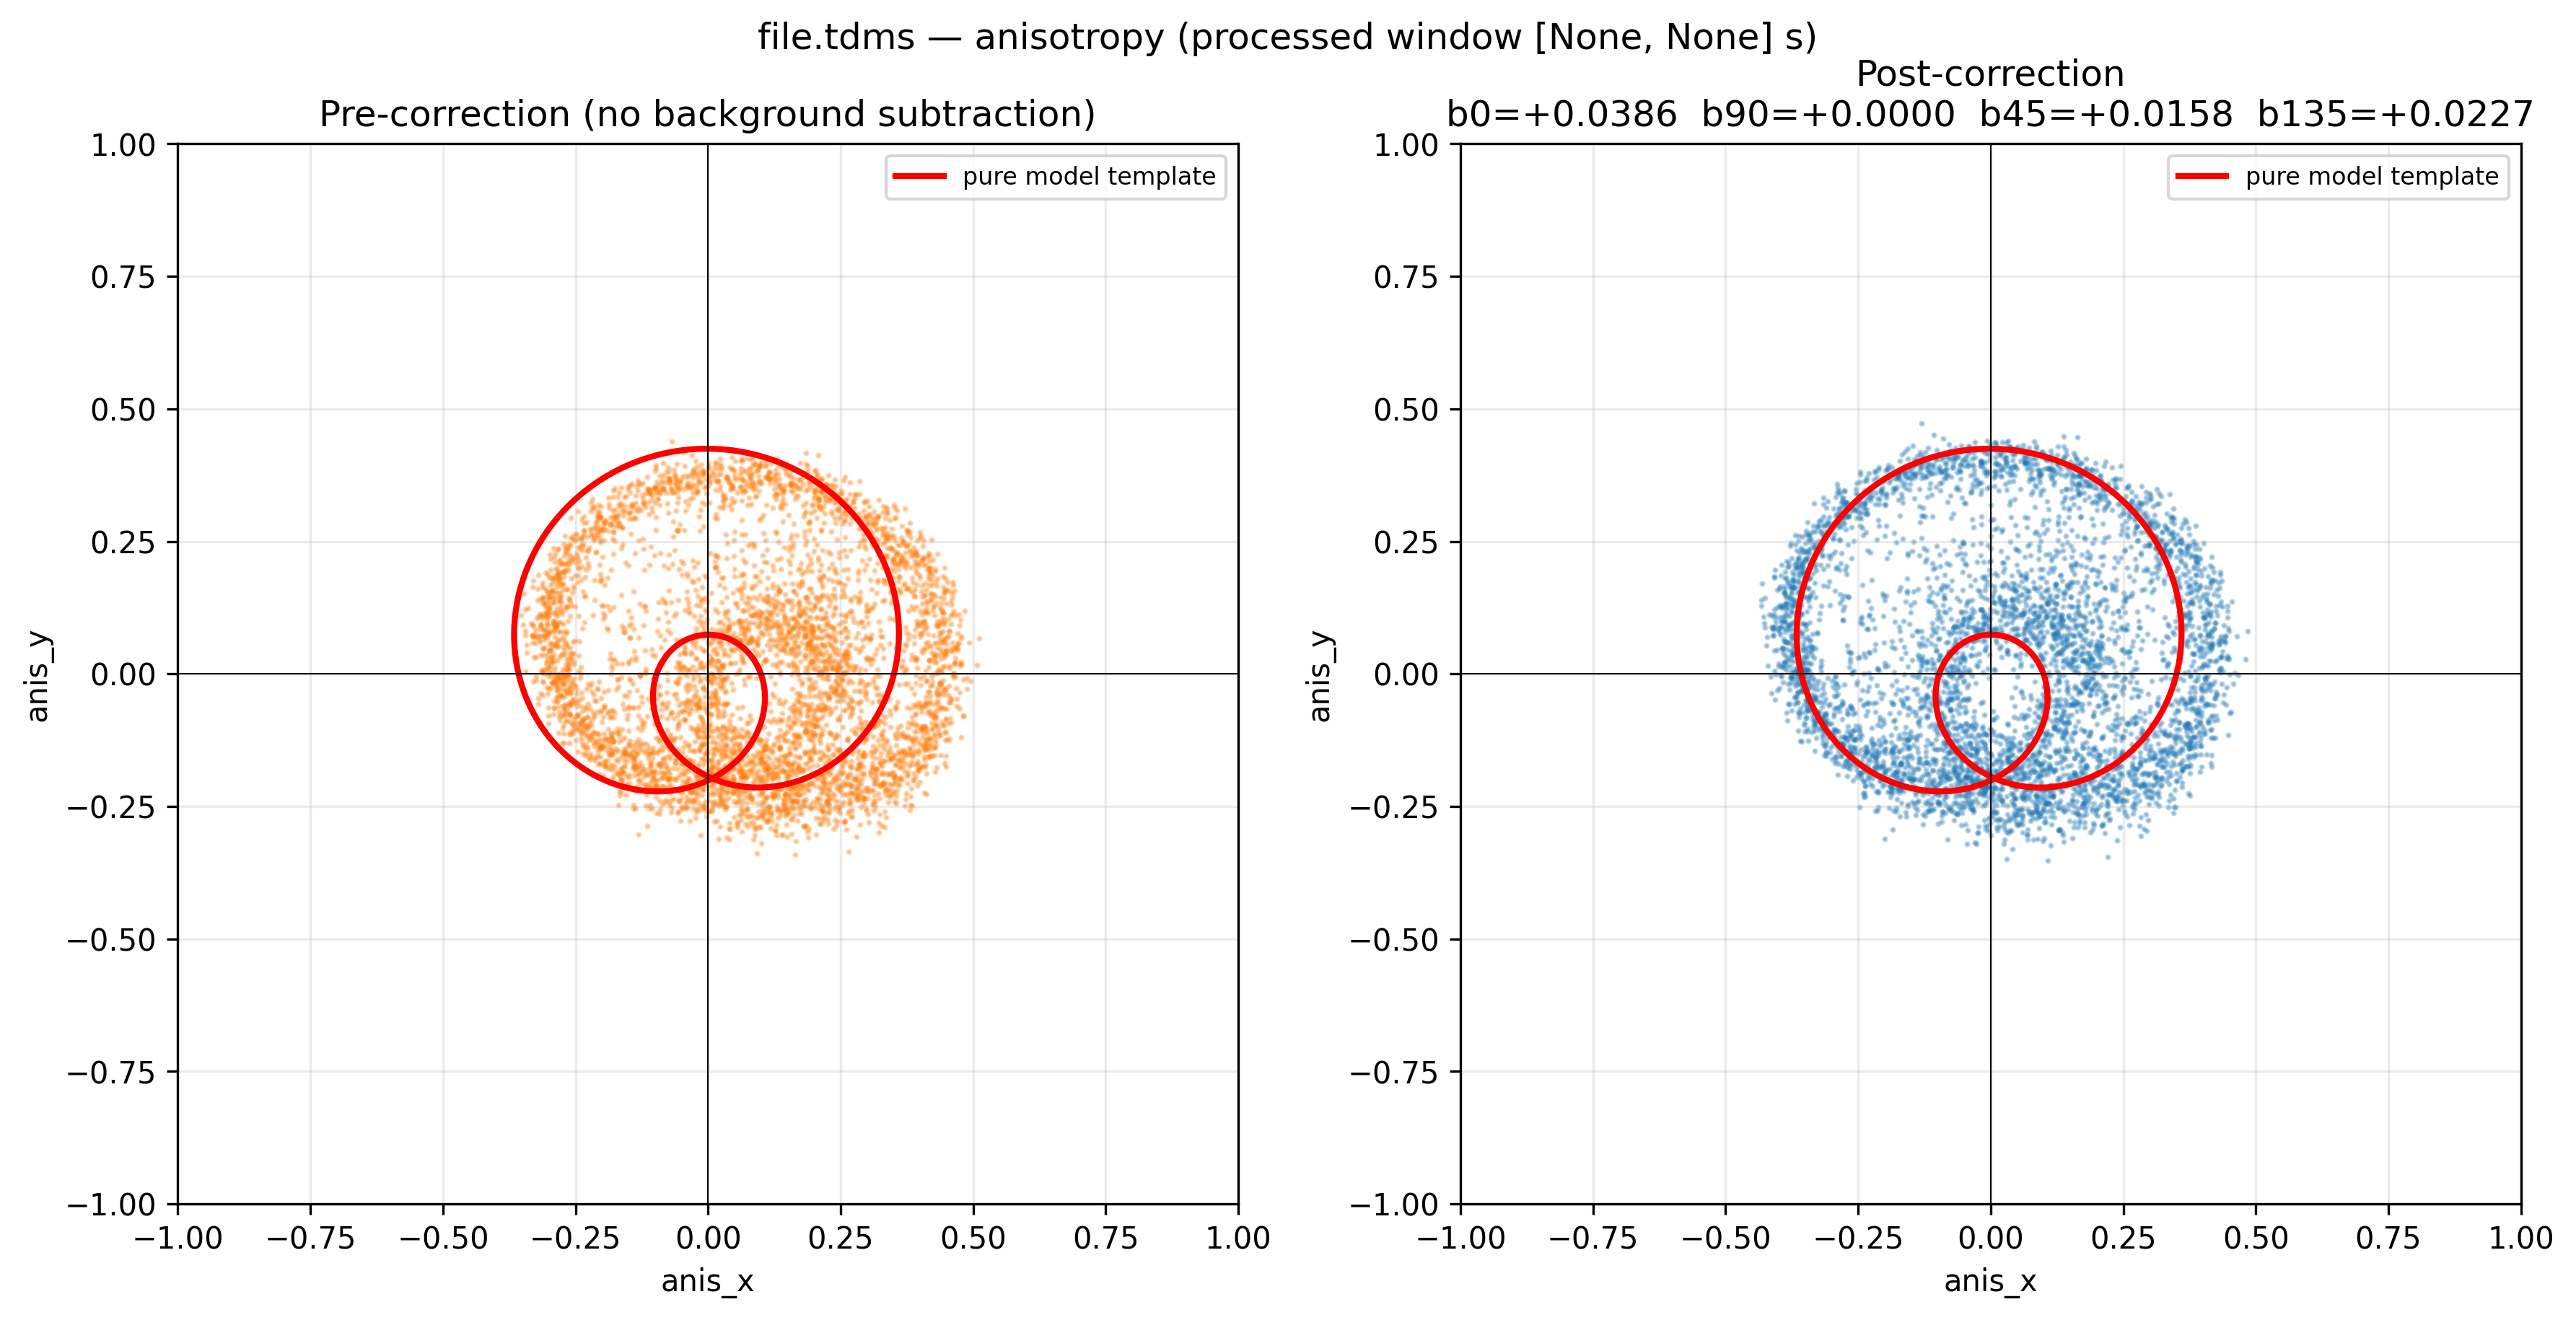

Saved: 01_anisotropy_shape.png


In [209]:
# ── Figure 1: Anisotropy shape (pre- and post-correction) ────────────────────
_dec_sc = max(1, len(anis_x[_mask]) // 5000)
_ax_sc  = anis_x[_mask][::_dec_sc]
_ay_sc  = anis_y[_mask][::_dec_sc]
_ax_nc  = anis_x_nocor[_mask][::_dec_sc]
_ay_nc  = anis_y_nocor[_mask][::_dec_sc]

# Pure model template
_ax_model_pure, _ay_model_pure = fourkas_template(
    Theta_axis_fitted, Phi_axis_fitted, Lambda_fitted, A_cal, B_cal, C_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

ax1.scatter(_ax_nc, _ay_nc, s=1, alpha=0.3, c="tab:orange", rasterized=True)
ax1.plot(np.append(_ax_model_pure, _ax_model_pure[0]),
         np.append(_ay_model_pure, _ay_model_pure[0]),
         'r-', lw=2, label='pure model template')
ax1.set_title("Pre-correction (no background subtraction)")
ax1.legend(fontsize=8)

ax2.scatter(_ax_sc, _ay_sc, s=1, alpha=0.3, c="tab:blue", rasterized=True)
ax2.plot(np.append(_ax_model_pure, _ax_model_pure[0]),
         np.append(_ay_model_pure, _ay_model_pure[0]),
         'r-', lw=2, label='pure model template')
ax2.set_title(f"Post-correction\n"
              f"b0={b0_fitted:+.4f}  b90={b90_fitted:+.4f}  "
              f"b45={b45_fitted:+.4f}  b135={b135_fitted:+.4f}")
ax2.legend(fontsize=8)

for _ax in (ax1, ax2):
    _ax.axhline(0, color="k", lw=0.5, zorder=3)
    _ax.axvline(0, color="k", lw=0.5, zorder=3)
    _ax.set_xlabel("anis_x"); _ax.set_ylabel("anis_y")
    _ax.set_xlim(-1, 1); _ax.set_ylim(-1, 1)
    _ax.set_aspect("equal"); _ax.grid(alpha=0.25)

_proc_label = f"processed window [{data_t_start}, {data_t_end}] s"
fig.suptitle(f"{tdms_path.name} — anisotropy ({_proc_label})")
plt.tight_layout()
fig.savefig(_output_dir / "01_anisotropy_shape.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: 01_anisotropy_shape.png")

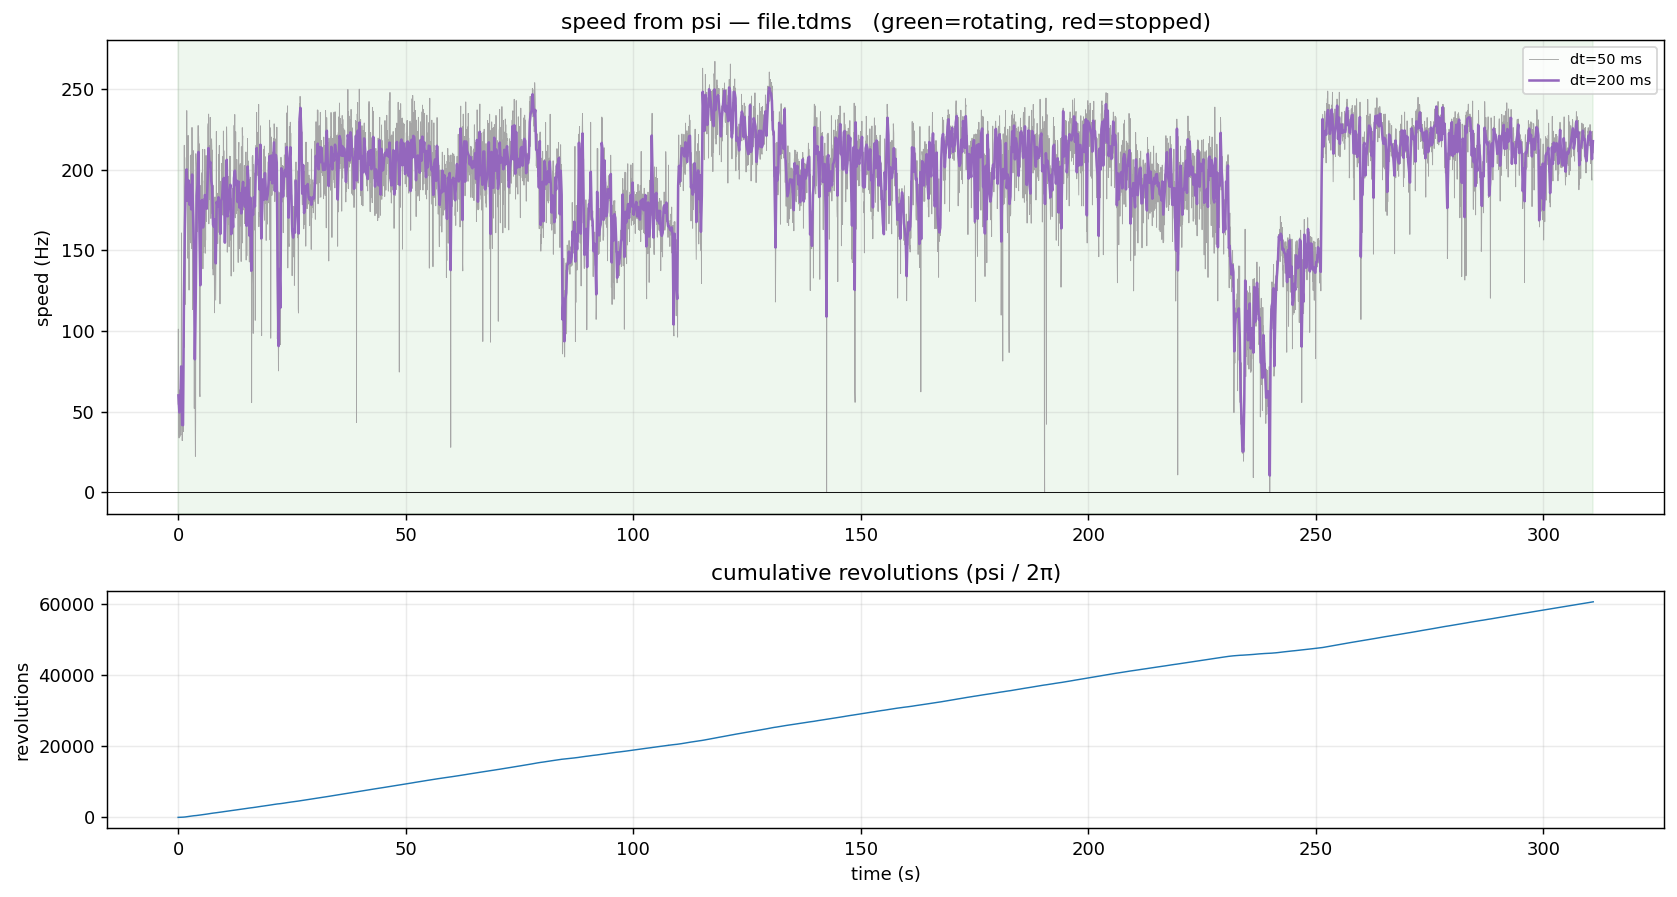

saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\02_speed_from_psi.png
|speed| over file: median=203.2 Hz, max=267.1 Hz
rotating regions : [(0.1, 310.9)]


In [210]:
# ── 13b. Speed time-series + region map ───────────────────────────────────────
# Speed straight from psi via `speed_at_dt` at a sensible averaging time (no more
# 5 ms micro-windows). One coarse trace shows the rotating/stopped structure; a
# finer trace shows the detail. Shaded = auto-detected regions.
SPEED_DT_FINE   = 0.05    # s — detail trace
SPEED_DT_COARSE = 0.20    # s — structure / region map

tf, vf = speed_at_dt(SPEED_DT_FINE)
tcs, vc = speed_at_dt(SPEED_DT_COARSE)

fig, (ax_sp, ax_z) = plt.subplots(2, 1, figsize=(13, 7), dpi=130,
                                  gridspec_kw=dict(height_ratios=[2, 1]))

ax_sp.plot(tf, vf, lw=0.5, color="0.65", label=f"dt={SPEED_DT_FINE*1e3:.0f} ms")
ax_sp.plot(tcs, vc, lw=1.4, color="tab:purple", label=f"dt={SPEED_DT_COARSE*1e3:.0f} ms")
for a, b in ROT_REGIONS:
    ax_sp.axvspan(a, b, color="tab:green", alpha=0.08)
for a, b in STOP_REGIONS:
    ax_sp.axvspan(a, b, color="tab:red", alpha=0.10)
ax_sp.axhline(0, color="k", lw=0.5)
ax_sp.set_ylabel("speed (Hz)")
ax_sp.set_title(f"speed from psi — {Path(tdms_path).name}   "
                f"(green=rotating, red=stopped)")
ax_sp.legend(loc="upper right", fontsize=8); ax_sp.grid(alpha=0.25)

# revolutions integral (monotone winding check) --------------------------------
ax_z.plot(_TPH, psi / (2 * np.pi), lw=0.8, color="tab:blue")
ax_z.set_xlabel("time (s)"); ax_z.set_ylabel("revolutions")
ax_z.set_title("cumulative revolutions (psi / 2π)"); ax_z.grid(alpha=0.25)

plt.tight_layout()
fig.savefig(_output_dir / "02_speed_from_psi.png", dpi=150, bbox_inches="tight")
plt.show()

_vc_rot = np.abs(vc[(vc != 0)])
print(f"saved: {_output_dir / '02_speed_from_psi.png'}")
print(f"|speed| over file: median={np.median(np.abs(vf)):.1f} Hz, "
      f"max={np.max(np.abs(vf)):.1f} Hz")
print(f"rotating regions : {[(round(a,1), round(b,1)) for a, b in ROT_REGIONS]}")


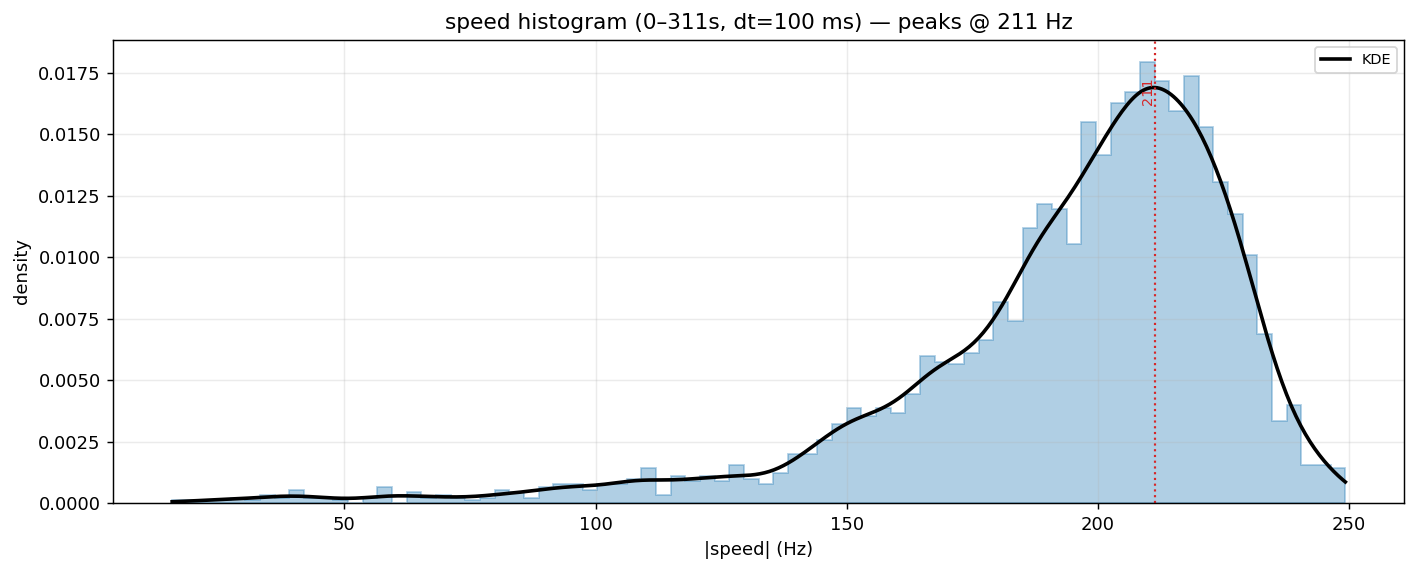

saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\03_speed_histogram.png
KDE peaks (Hz): [211.3]


In [211]:
# ── 13c. Speed histogram + KDE peaks (candidate quantised levels) ──────────────
# Occupancy histogram of |speed| over a region (default: the longest rotating
# stretch CLEAN_ROT; set HIST_REGION=None for the whole file). KDE peaks mark
# candidate speed levels — a multi-stator BFM tends to dwell at discrete rates.
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

HIST_REGION = CLEAN_ROT      # (t0, t1) or None for whole file
HIST_DT     = 0.10           # s — averaging time for the histogram
HIST_KDE_BW = 0.15

_t0, _t1 = (None, None) if HIST_REGION is None else HIST_REGION
_t, vv = speed_at_dt(HIST_DT, t0=_t0, t1=_t1)
vv = np.abs(vv)
vv = vv[(vv > 5) & (vv < np.percentile(vv, 99.5))]

fig, ax_hist = plt.subplots(figsize=(11, 4.5), dpi=130)
peaks_hz = np.array([])
if len(vv) > 30:
    ax_hist.hist(vv, bins=80, density=True, histtype="stepfilled",
                 color="tab:blue", alpha=0.35, edgecolor="tab:blue")
    g = np.linspace(vv.min(), vv.max(), 500)
    k = gaussian_kde(vv, bw_method=HIST_KDE_BW)(g)
    ax_hist.plot(g, k, color="k", lw=2.0, label="KDE")
    pk, _ = find_peaks(k, prominence=k.max() * 0.05)
    peaks_hz = g[pk]
    for p in peaks_hz:
        ax_hist.axvline(p, color="tab:red", ls=":", lw=1.2)
        ax_hist.text(p, ax_hist.get_ylim()[1] * 0.92, f"{p:.0f}",
                     rotation=90, va="top", ha="right", fontsize=8, color="tab:red")
_reg = "whole file" if HIST_REGION is None else f"{HIST_REGION[0]:.0f}–{HIST_REGION[1]:.0f}s"
ax_hist.set_xlabel("|speed| (Hz)"); ax_hist.set_ylabel("density")
ax_hist.set_title(f"speed histogram ({_reg}, dt={HIST_DT*1e3:.0f} ms) — "
                  f"peaks @ " + ", ".join(f"{p:.0f}" for p in peaks_hz) + " Hz")
ax_hist.legend(fontsize=8); ax_hist.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(_output_dir / "03_speed_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {_output_dir / '03_speed_histogram.png'}")
print(f"KDE peaks (Hz): {np.round(peaks_hz, 1)}")


# 14. Allan deviation — noise-source summary (final 3-panel view)

This section is now the **single final Allan analysis** used for interpretation before step detection.

It separates three sources with matched controls:

| panel | source focus | what is compared | signature |
|---|---|---|---|
| **(a)** | motor dynamics | rotating vs stopped (same rod) | short-τ fall, mid-τ flicker-like floor, long-τ rise |
| **(c)** | linkage wobble | tethered-stopped PSD vs fixed-rod PSD | Lorentzian shoulder with corner $f_c$ |
| **(d)** | overall comparison | fixed rod + stopped + rotating | combined rate-ADEV budget |

Why this is the right section to use:

- It directly links to the `dt` choice used in step detection (§15).
- It keeps all Allan evidence in one place, with one figure.
- It avoids duplicated exploratory Allan cells later in the notebook.

Output:

- A single saved figure: `14_allan_general_summary.png` (and compatibility copy as `20_allan_general_summary.png`).

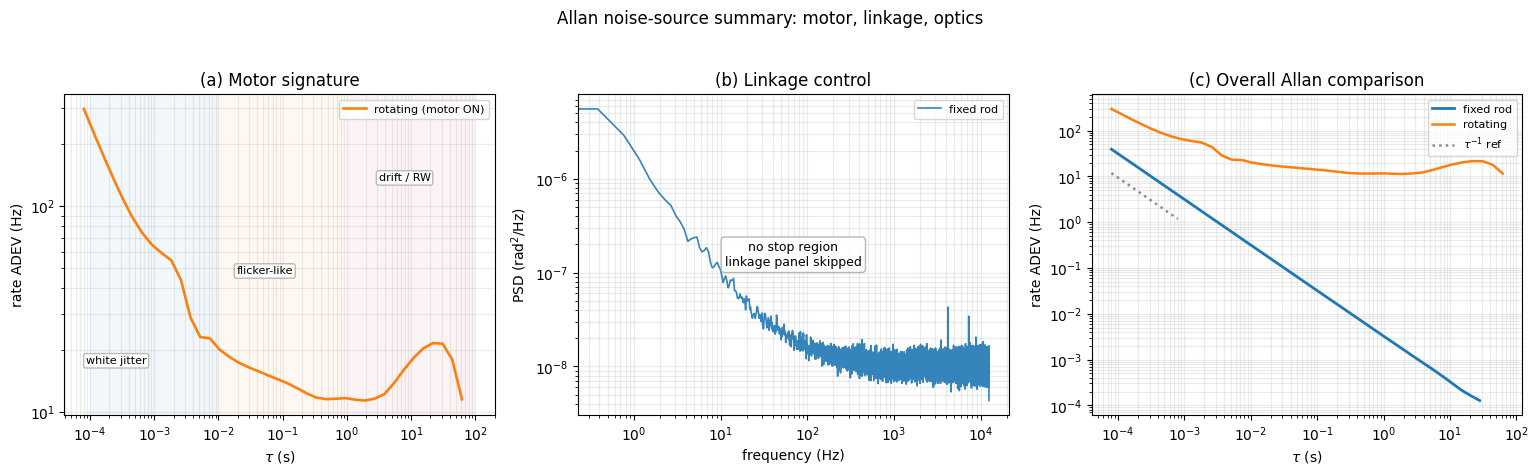

saved:
  C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\14_allan_general_summary.png
  C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\20_allan_general_summary.png
  linkage corner: unavailable (no stop region)


In [212]:
# SECTION 14 — FINAL Allan summary (3 panels: a/c/d)
from scipy.signal import welch
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- config -----------------------------------------------------------------
FIXED_ROD_TDMS = Path(r"C:\Users\denny\workspace\pyqtrod\data\2024_08_01_fixed_gold\fixed\fixed7.tdms")
FIXED_ROD_DEC = 10

# ---- helpers ----------------------------------------------------------------
def _wrap(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def _lorentz_white(f, A, fc, W):
    return A / (1.0 + (f / fc) ** 2) + W

def process_fixed_rod(path, chcor=None, decimate=10, clip_sigma=6.0):
    path = Path(path)
    o = TdmsFile.open(str(path)); ch = o.groups()[0].channels()
    inc = float(ch[0].properties.get("wf_increment", 4e-6))
    idx = get_pol_ind(["0", "90", "45", "135"]); sl = slice(None, None, decimate)
    c0 = np.asarray(ch[idx[0]][sl], float); c90 = np.asarray(ch[idx[1]][sl], float)
    c45 = np.asarray(ch[idx[2]][sl], float); c135 = np.asarray(ch[idx[3]][sl], float)
    o.close()
    fs_eff = 1.0 / (inc * decimate)
    a = [1.0, 1.0, 1.0, 1.0] if chcor is None else list(np.ravel(chcor))[:4]
    stack = np.vstack((c90, c45, c135, c0))
    for i in range(4):
        stack[i] *= a[i]
    tcor = np.dot(matcor, stack)
    c0c, c90c, c45c, c135c = tcor[idx[0]], tcor[idx[1]], tcor[idx[2]], tcor[idx[3]]
    dx, dy = c0c + c90c, c45c + c135c
    good = (dx > 0) & (dy > 0)
    ax = np.where(dx > 0, (c0c - c90c) / dx, 0.0)
    ay = np.where(dy > 0, (c45c - c135c) / dy, 0.0)
    ang2 = np.arctan2(ay, ax)
    mean_dir = np.angle(np.mean(np.exp(1j * ang2[good])))
    phi = 0.5 * _wrap(ang2 - mean_dir)
    s = np.std(phi[good]); m = (np.abs(phi) > clip_sigma * s) | ~good
    phi[m] = 0.0
    return np.arange(len(phi)) / fs_eff, phi, fs_eff

def phase_adev(phase_rad, fs, n=40, tau_max_frac=5.0):
    if allantools is None or len(phase_rad) < 1000:
        return np.array([]), np.array([])
    span = len(phase_rad) / fs
    taus = np.logspace(np.log10(2.0 / fs), np.log10(span / tau_max_frac), n)
    tau, adev, _, _ = allantools.oadev(np.asarray(phase_rad, float), rate=fs,
                                       data_type="phase", taus=taus)
    ah = adev / (2.0 * np.pi)
    ok = np.isfinite(ah) & (ah > 0)
    return tau[ok], ah[ok]

# ---- compute controls --------------------------------------------------------
_chcor_path = FIXED_ROD_TDMS.with_name(FIXED_ROD_TDMS.stem + "_chcor.npy")
_FX_CHCOR = np.load(_chcor_path, allow_pickle=True) if _chcor_path.exists() else None
_fxt, _fxphi, _fxfs = process_fixed_rod(FIXED_ROD_TDMS, _FX_CHCOR, decimate=FIXED_ROD_DEC)
_fx_tau, _fx_adev = phase_adev(_fxphi, _fxfs)

_axd = anis_x[::PHASE_DECIMATION][:len(psi)]
_ayd = anis_y[::PHASE_DECIMATION][:len(psi)]
_ang2_all = np.arctan2(_ayd, _axd)

def phi_fluct_segment(t0, t1):
    sel = (_TPH >= t0) & (_TPH <= t1)
    a2 = _ang2_all[sel]
    return 0.5 * _wrap(a2 - np.angle(np.mean(np.exp(1j * a2)))), _FS_EFF

_stop = max(STOP_REGIONS, key=lambda r: r[1] - r[0]) if STOP_REGIONS else None
_have_stop = _stop is not None
if _have_stop:
    _ts, _as = omega_adev(*_stop)
    _pstop, _ = phi_fluct_segment(*_stop)
    _fS, _PS = welch(_pstop, fs=_FS_EFF, nperseg=1 << 16)
else:
    _ts, _as = np.array([]), np.array([])
    _pstop = np.array([])
    _fS, _PS = np.array([]), np.array([])

_fF, _PF = welch(_fxphi, fs=_fxfs, nperseg=1 << 16)
if _have_stop and len(_fS):
    _band = (_fS > 5.0) & (_fS < 5000)
    _popt, _ = curve_fit(_lorentz_white, _fS[_band], _PS[_band],
                         p0=[_PS[_band][0], 30.0, np.median(_PS[_fS > 800])],
                         bounds=([0, 3, 0], [np.inf, 1000, np.inf]), maxfev=30000)
    _A_fit, _fc_fit, _W_fit = _popt
else:
    _A_fit, _fc_fit, _W_fit = np.nan, np.nan, np.nan

_tau_c_ms = 1.0 / (2 * np.pi * _fc_fit) * 1e3 if np.isfinite(_fc_fit) else np.nan

# rotating (longest clean rotating segment)
tau_rot, adev_rot = np.array([]), np.array([])
_rot_segs = [r for r in ROT_REGIONS if (r[1] - r[0]) > 20]
if _rot_segs:
    _longest_rot = max(_rot_segs, key=lambda r: r[1] - r[0])
    tau_rot, adev_rot = omega_adev(_longest_rot[0], _longest_rot[1])

# ---- plot final 3-panel summary ----------------------------------------------
try:
    _outdir = Path(_output_dir)
except Exception:
    _outdir = Path.cwd()
_outdir.mkdir(parents=True, exist_ok=True)

fig, (axA, axC, axD) = plt.subplots(1, 3, figsize=(15.5, 4.8))

# (a) MOTOR
if len(tau_rot):
    axA.loglog(tau_rot, adev_rot, color='C1', lw=1.9, label='rotating (motor ON)')
if len(_ts):
    axA.loglog(_ts, _as, color='0.45', lw=2.1, label='stopped (motor OFF)')
axA.axvspan(1e-4, 1e-2, color='C0', alpha=0.06, ec='none')
axA.axvspan(1e-2, 1e0, color='C1', alpha=0.05, ec='none')
axA.axvspan(1e0, 1e2, color='C3', alpha=0.05, ec='none')
axA.text(0.05, 0.16, 'white jitter', transform=axA.transAxes, fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.9))
axA.text(0.40, 0.44, 'flicker-like', transform=axA.transAxes, fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.9))
axA.text(0.73, 0.73, 'drift / RW', transform=axA.transAxes, fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.9))
axA.set_title('(a) Motor signature')
axA.set_xlabel(r'$\tau$ (s)')
axA.set_ylabel('rate ADEV (Hz)')
axA.grid(True, which='both', alpha=0.25)
axA.legend(fontsize=8)

# (b) LINKAGE
if _have_stop and len(_fS):
    axC.loglog(_fS, _PS, color='C3', lw=1.2, alpha=0.9, label='tethered stopped')
if len(_fF):
    axC.loglog(_fF, _PF, color='C0', lw=1.2, alpha=0.9, label='fixed rod')
if np.isfinite(_fc_fit):
    fsm = np.logspace(np.log10(1.0), np.log10(_FS_EFF / 2.0), 400)
    axC.loglog(fsm, _lorentz_white(fsm, _A_fit, _fc_fit, _W_fit), 'k--', lw=1.5,
               label=f'Lorentzian fit ($f_c$={_fc_fit:.1f} Hz)')
    axC.axvline(_fc_fit, color='0.3', ls=':', lw=1.0)
else:
    axC.text(0.5, 0.5, 'no stop region\nlinkage panel skipped',
             transform=axC.transAxes, ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.95))
axC.set_title('(b) Linkage control')
axC.set_xlabel('frequency (Hz)')
axC.set_ylabel('PSD (rad$^2$/Hz)')
axC.grid(True, which='both', alpha=0.25)
axC.legend(fontsize=8)

# (c) OVERALL
if len(_fx_tau):
    axD.loglog(_fx_tau, _fx_adev, color='C0', lw=2.0, label='fixed rod')
if len(_ts):
    axD.loglog(_ts, _as, color='C2', lw=1.8, label='stopped')
if len(tau_rot):
    axD.loglog(tau_rot, adev_rot, color='C1', lw=1.8, label='rotating')
all_taus = np.concatenate([_ts if len(_ts) else np.array([]),
                           tau_rot if len(tau_rot) else np.array([]),
                           _fx_tau if len(_fx_tau) else np.array([])])
if len(all_taus):
    t0 = float(np.min(all_taus[np.isfinite(all_taus)]))
    if len(_fx_tau):
        y0 = float(_fx_adev[np.argmin(_fx_tau)])
    elif len(tau_rot):
        y0 = float(adev_rot[np.argmin(tau_rot)])
    else:
        y0 = float(_as[np.argmin(_ts)])
    y0 *= 0.3
    tref = np.array([t0, t0 * 10.0])
    yref = y0 * (tref / t0) ** -1.0
    axD.loglog(tref, yref, color='0.5', ls=':', lw=1.8, alpha=0.9, label=r'$\tau^{-1}$ ref')
axD.set_title('(c) Overall Allan comparison')
axD.set_xlabel(r'$\tau$ (s)')
axD.set_ylabel('rate ADEV (Hz)')
axD.grid(True, which='both', alpha=0.25)
axD.legend(fontsize=8)

fig.suptitle('Allan noise-source summary: motor, linkage, optics', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])

_p14 = _outdir / '14_allan_general_summary.png'
_p20compat = _outdir / '20_allan_general_summary.png'
fig.savefig(_p14, dpi=170, bbox_inches='tight')
fig.savefig(_p20compat, dpi=170, bbox_inches='tight')
plt.show()

print('saved:')
print(' ', _p14)
print(' ', _p20compat)
if np.isfinite(_fc_fit):
    print(f'  linkage corner: fc={_fc_fit:.2f} Hz  (tau_c={_tau_c_ms:.2f} ms)')
else:
    print('  linkage corner: unavailable (no stop region)')

# 15. Step Detection (Screening)

Use the next cell as the single quick screening pass.

Set:
- `STEP_REGION` to `None`, `"file"`, or `(t0, t1)`
- `STEP_DTS` to test temporal robustness
- `STEP_PEN_K` to control strictness

Interpretation:
- Keep only longer-lived, repeatable plateaus across `dt` as plausible stator-state changes.
- Treat this as a scan tool, not final proof of a two-state model.

step region: 0.1–310.9 s   [CLEAN_ROT — longest rotating stretch]   penalty k=9


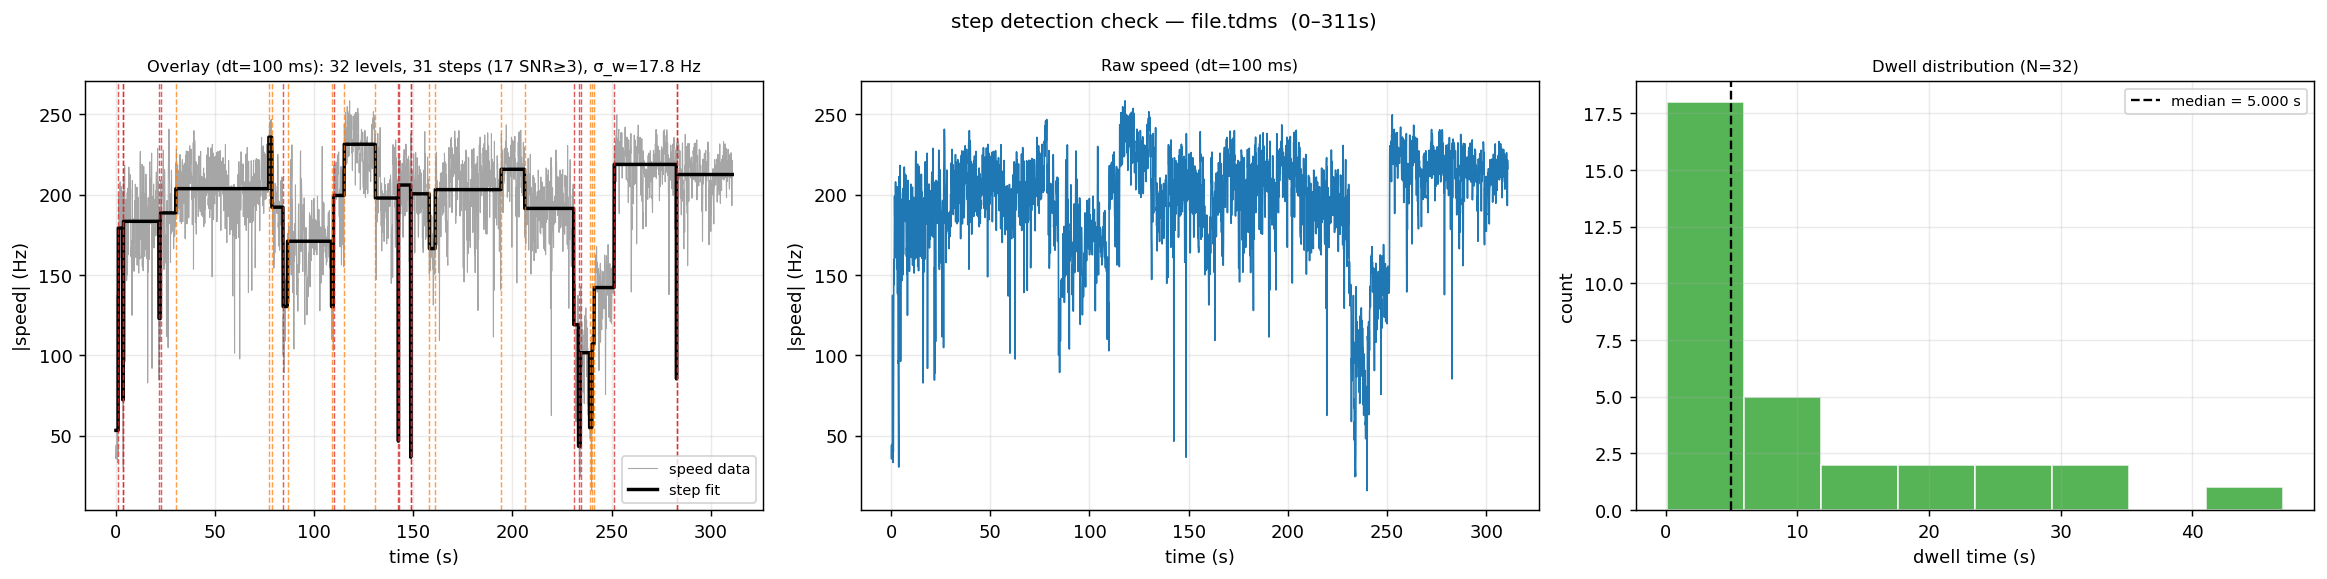

  dt= 100 ms :  31 steps,  17 confident, median |step|=107 Hz, median dwell=5.000 s


In [213]:
# ── 15a. Step detection — one figure per dt (overlay + raw speed + dwell dist) ──
STEP_REGION = None               # None  -> CLEAN_ROT (longest rotating stretch)
                                 # (t0, t1) -> manual window in seconds
                                 # "file" -> full file span
STEP_DTS = [0.1]                 # averaging times to compare
STEP_PEN_K = 9                   # penalty (higher = fewer steps)

if STEP_REGION is None:
    _sr = CLEAN_ROT
    _src = "CLEAN_ROT — longest rotating stretch"
elif STEP_REGION == "file":
    _sr = (float(_TPH[0]), float(_TPH[-1]))
    _src = "full file"
else:
    _sr = STEP_REGION
    _src = "manual window"
print(f"step region: {_sr[0]:.1f}–{_sr[1]:.1f} s   [{_src}]   penalty k={STEP_PEN_K}")

_fits = {dt: fit_steps(_sr[0], _sr[1], dt=dt, penk=STEP_PEN_K) for dt in STEP_DTS}

for dt in STEP_DTS:
    r = _fits[dt]
    nconf = int(np.sum(r["snr"] >= 3))

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 4.5), dpi=130)

    # Panel 1: speed + step-fit overlay
    ax0.plot(r["t"], r["v"], lw=0.6, color="0.65", label="speed data")
    ax0.plot(r["t"], r["fit"], lw=1.9, color="k", label="step fit")
    for e, sn in zip(r["edges"], r["snr"]):
        ax0.axvline(e, color="tab:red" if sn >= 3 else "tab:orange", ls="--", lw=0.8, alpha=0.75)
    ax0.set_ylabel("|speed| (Hz)")
    ax0.set_xlabel("time (s)")
    ax0.set_title(
        f"Overlay (dt={dt*1e3:.0f} ms): {len(r['levels'])} levels, "
        f"{len(r['steps'])} steps ({nconf} SNR≥3), σ_w={r['sigma_w']:.1f} Hz",
        fontsize=9,
    )
    ax0.grid(alpha=0.25)
    ax0.legend(fontsize=8, loc="best")

    # Panel 2: raw speed only at this dt (no step overlay)
    ax1.plot(r["t"], r["v"], lw=0.9, color="tab:blue")
    ax1.set_ylabel("|speed| (Hz)")
    ax1.set_xlabel("time (s)")
    ax1.set_title(f"Raw speed (dt={dt*1e3:.0f} ms)", fontsize=9)
    ax1.grid(alpha=0.25)

    # Panel 3: dwell-time distribution (time spent on each detected level)
    dw = np.asarray(r["dwells"], dtype=float)
    if dw.size:
        bins_dw = min(30, max(8, int(np.sqrt(dw.size))))
        ax2.hist(dw, bins=bins_dw, color="tab:green", alpha=0.8, edgecolor="white")
        med_dw = float(np.median(dw))
        ax2.axvline(med_dw, color="k", ls="--", lw=1.3, label=f"median = {med_dw:.3f} s")
        ax2.legend(fontsize=8)
    else:
        ax2.text(0.5, 0.5, "no dwells", transform=ax2.transAxes,
                 ha="center", va="center", fontsize=11)
    ax2.set_xlabel("dwell time (s)")
    ax2.set_ylabel("count")
    ax2.set_title(f"Dwell distribution (N={dw.size})", fontsize=9)
    ax2.grid(alpha=0.25)

    fig.suptitle(
        f"step detection check — {Path(tdms_path).name}  ({_sr[0]:.0f}–{_sr[1]:.0f}s)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

for dt in STEP_DTS:
    r = _fits[dt]
    conf = np.abs(r["steps"])[r["snr"] >= 3]
    med = np.median(conf) if len(conf) else np.nan
    dw = np.asarray(r["dwells"], dtype=float)
    med_dw = float(np.median(dw)) if dw.size else np.nan
    print(
        f"  dt={dt*1e3:4.0f} ms : {len(r['steps']):3d} steps, "
        f"{len(conf):3d} confident, median |step|={med:.0f} Hz, median dwell={med_dw:.3f} s"
    )

# 16. Diagnostics (Interactive)

Per-point projection walk-through for manual sanity checks.

Keep this section for deep inspection of interesting files after the quick scan.

In [214]:
# ── Section 16: per-point mapping / projection diagnostic ─────────────────────
# Interactive walk-through of the phase tracker. Pick a window [start, end] in
# decimated phase-sample units, then step a slider through each point to see:
#   (1) raw corrected channel signals over the window,
#   (2) anisotropy after correction with the Fourkas template + how THIS point is
#       projected onto the template (tracked projection vs naive global-nearest),
#   (3) the tracked phase psi over the window.
# Use it to confirm the continuity-constrained projection behaves as intended.
import ipywidgets as widgets
from IPython.display import display, clear_output

if ("psi" not in globals()) or (psi is None) or (len(psi) < 2):
    raise RuntimeError("Run Section 12 (phase tracking) first — `psi` is not available.")

# Rebuild the decimated phase-sample arrays from stored results (self-contained).
_Dg = int(max(1, PHASE_DECIMATION))
_Ng = int(max(60, PHASE_KDTREE_N_MODEL))
_tg = time_proc[::_Dg]
_axg = anis_x[::_Dg]
_ayg = anis_y[::_Dg]
_Mg = min(len(_tg), len(psi))
_tg, _axg, _ayg, _psig = _tg[:_Mg], _axg[:_Mg], _ayg[:_Mg], psi[:_Mg]

# Decimated corrected channels (post background subtraction), aligned to _tg.
_c0g   = c0[::_Dg][:_Mg]
_c90g  = c90[::_Dg][:_Mg]
_c45g  = c45[::_Dg][:_Mg]
_c135g = c135[::_Dg][:_Mg]

# Per-point geometry (fall back to fitted scalars if per-sample arrays absent).
_has_geom = (
    "theta_axis_used" in globals() and len(theta_axis_used) >= _Mg
    and "phi_axis_used" in globals() and "lambda_used" in globals()
)

def _geom_at(i):
    if _has_geom:
        return float(theta_axis_used[i]), float(phi_axis_used[i]), float(lambda_used[i])
    return float(Theta_axis_fitted), float(Phi_axis_fitted), float(Lambda_fitted)

_w_start = widgets.IntText(value=0, description="start idx:",
                           style={"description_width": "70px"},
                           layout=widgets.Layout(width="220px"))
_w_end = widgets.IntText(value=min(_Mg, 200), description="end idx:",
                         style={"description_width": "70px"},
                         layout=widgets.Layout(width="220px"))
_w_pt = widgets.IntSlider(value=0, min=0, max=max(0, _Mg - 1), step=1,
                          description="point:", continuous_update=False,
                          layout=widgets.Layout(width="80%"),
                          style={"description_width": "70px"})
_diag_plot = widgets.Output()
_diag_info = widgets.Output()

def _clamp_window():
    s = int(np.clip(_w_start.value, 0, _Mg - 2))
    e = int(np.clip(_w_end.value, s + 2, _Mg))
    return s, e

def _on_window_change(*_):
    s, e = _clamp_window()
    _w_pt.min = s
    _w_pt.max = e - 1
    # Setting _w_pt.value fires the _w_pt observer, which calls _draw(). To avoid
    # drawing twice, only draw explicitly when the point is already in range
    # (no value change -> no observer); otherwise let the observer handle it.
    if _w_pt.value < s or _w_pt.value > e - 1:
        _w_pt.value = s
    else:
        _draw()

def _draw(*_):
    s, e = _clamp_window()
    i = int(np.clip(_w_pt.value, s, e - 1))

    th, ph, lam = _geom_at(i)
    _axm, _aym = fourkas_template(th, ph, lam, A_cal, B_cal, C_cal, N_model=_Ng)
    _axm_c = np.append(_axm, _axm[0]); _aym_c = np.append(_aym, _aym[0])

    # Tracked projection of this point: continuous fractional template index from psi.
    _frac = (_psig[i] * _Ng / (2.0 * np.pi)) % _Ng
    _j0 = int(np.floor(_frac)) % _Ng
    _j1 = (_j0 + 1) % _Ng
    _wgt = _frac - np.floor(_frac)
    _px = _axm[_j0] * (1 - _wgt) + _axm[_j1] * _wgt
    _py = _aym[_j0] * (1 - _wgt) + _aym[_j1] * _wgt

    # Naive global-nearest vertex (for contrast).
    _d2 = (_axm - _axg[i]) ** 2 + (_aym - _ayg[i]) ** 2
    _jg = int(np.argmin(_d2))

    with _diag_plot:
        clear_output(wait=True)
        fig, axd = plt.subplots(1, 3, figsize=(16, 5), dpi=110)

        # Panel 1: raw corrected channel signals over window.
        _ts = _tg[s:e]
        axd[0].plot(_ts, _c0g[s:e], lw=0.8, label="c0")
        axd[0].plot(_ts, _c90g[s:e], lw=0.8, label="c90")
        axd[0].plot(_ts, _c45g[s:e], lw=0.8, label="c45")
        axd[0].plot(_ts, _c135g[s:e], lw=0.8, label="c135")
        axd[0].axvline(_tg[i], color="k", lw=1.0, ls="--")
        axd[0].set_xlabel("time (s)"); axd[0].set_ylabel("corrected signal")
        axd[0].set_title("1. Raw (corrected) channel signals")
        axd[0].legend(fontsize=8); axd[0].grid(alpha=0.25)

        # Panel 2: anisotropy + template + this point's projection.
        axd[1].scatter(_axg[s:e], _ayg[s:e], s=8, c="grey", alpha=0.35, label="window points")
        axd[1].plot(_axm_c, _aym_c, "-", c="tab:red", lw=1.2, alpha=0.8, label="Fourkas template")
        axd[1].scatter([_axg[i]], [_ayg[i]], s=70, c="tab:blue", zorder=6, label="data point")
        axd[1].scatter([_px], [_py], s=70, c="tab:green", marker="*", zorder=7, label="tracked projection")
        axd[1].plot([_axg[i], _px], [_ayg[i], _py], "-", c="tab:green", lw=1.0, zorder=5)
        axd[1].scatter([_axm[_jg]], [_aym[_jg]], s=50, c="tab:orange", marker="x", zorder=6,
                       label="naive global-nearest")
        axd[1].set_xlim(-1, 1); axd[1].set_ylim(-1, 1); axd[1].set_aspect("equal")
        axd[1].axhline(0, color="k", lw=0.4); axd[1].axvline(0, color="k", lw=0.4)
        axd[1].set_xlabel("anis_x"); axd[1].set_ylabel("anis_y")
        axd[1].set_title("2. Anisotropy + projection"); axd[1].legend(fontsize=7, loc="lower left")
        axd[1].grid(alpha=0.2)

        # Panel 3: tracked phase over window (in revolutions).
        _rev = _psig[s:e] / (2.0 * np.pi)
        axd[2].plot(_tg[s:e], _rev, lw=0.9, c="tab:purple")
        axd[2].scatter([_tg[i]], [_psig[i] / (2.0 * np.pi)], s=60, c="k", zorder=6)
        axd[2].set_xlabel("time (s)"); axd[2].set_ylabel("psi (revolutions)")
        axd[2].set_title("3. Tracked phase psi"); axd[2].grid(alpha=0.25)

        plt.tight_layout(); plt.show()

    with _diag_info:
        clear_output(wait=True)
        _proj_err = float(np.hypot(_axg[i] - _px, _ayg[i] - _py))
        _step = float(_psig[i] - _psig[i - 1]) if i > s else 0.0
        print(f"point {i}  (window [{s}, {e}), {e - s} pts)")
        print(f"  t          = {_tg[i]:.6f} s")
        print(f"  data (ax,ay) = ({_axg[i]:+.4f}, {_ayg[i]:+.4f})")
        print(f"  geometry   = Theta {th:.2f}°, Phi {ph:.2f}°, Lambda {lam:.2f}°")
        print(f"  tracked frac index = {_frac:.3f} / {_Ng}")
        print(f"  projection (ax,ay) = ({_px:+.4f}, {_py:+.4f})   |residual| = {_proj_err:.4f}")
        print(f"  naive global-nearest index = {_jg} / {_Ng}")
        print(f"  psi        = {_psig[i]:.4f} rad  ({_psig[i] / (2 * np.pi):.4f} rev)")
        print(f"  d_psi from prev = {_step:+.4f} rad")

# Clear observers left over from a previous run of this cell before re-registering
# — otherwise re-running stacks duplicate listeners and produces multiple plots.
_w_start.unobserve_all()
_w_end.unobserve_all()
_w_pt.unobserve_all()
_w_start.observe(_on_window_change, names="value")
_w_end.observe(_on_window_change, names="value")
_w_pt.observe(_draw, names="value")

_on_window_change()
display(widgets.VBox([
    widgets.HBox([_w_start, _w_end]),
    _w_pt,
    _diag_info,
    _diag_plot,
]))

# 17. Speed survey — definitions, multi-timescale zoom, level sharpness

A focused follow-up to the whole-trace speed plots, built to answer: *is there an
averaging timescale at which the rotation speed resolves into clean discrete
levels — and if not, why not?*

### How "speed" is defined and filtered (recap)
`speed_at_dt(dt)` fits a straight line to `psi(t)` over each non-overlapping window
of width `dt` and returns slope ÷ 2π in Hz. **The averaging time `dt` is the
filter** — there is no separate smoothing stage. A small `dt` is the *raw* speed
(noisy); a larger `dt` is the *filtered* speed. The trade-off is physical:

- **below the linkage corner** (`τc ≈ 15–20 ms`, from §14) the rod reports elastic
  wobble, not the motor — no `dt` recovers motor dynamics faster than the linkage;
- **above the shortest dwell** genuine level changes smear into ramps.

### How change-points are extracted
`fit_steps(t0, t1, dt, penk)` runs a penalised-L2 optimal-partition fit on `|speed|`
(cost = within-level SSE + `penk·σ²·log n`, with `σ` = MAD of `diff(|speed|)`),
returning levels, step sizes, dwell times and `SNR = |step| / σ_within`.

### What this section adds
- **17a** — speed vs time on a clean stepping patch (a 13b/13c winner), shown raw +
  filtered + change-points at **shrinking windows (10 → 2 → 0.5 → 0.1 s)**.
- **17b** — a `dt` sweep with a **level-contrast** metric (trough depth between the
  two tallest KDE peaks, 0–1) for two window sizes, to find a timescale that gives
  discrete levels — or show the smear is physical (linkage floor / drift / short
  dwells). Figures save under `…/17_speed_survey/`.


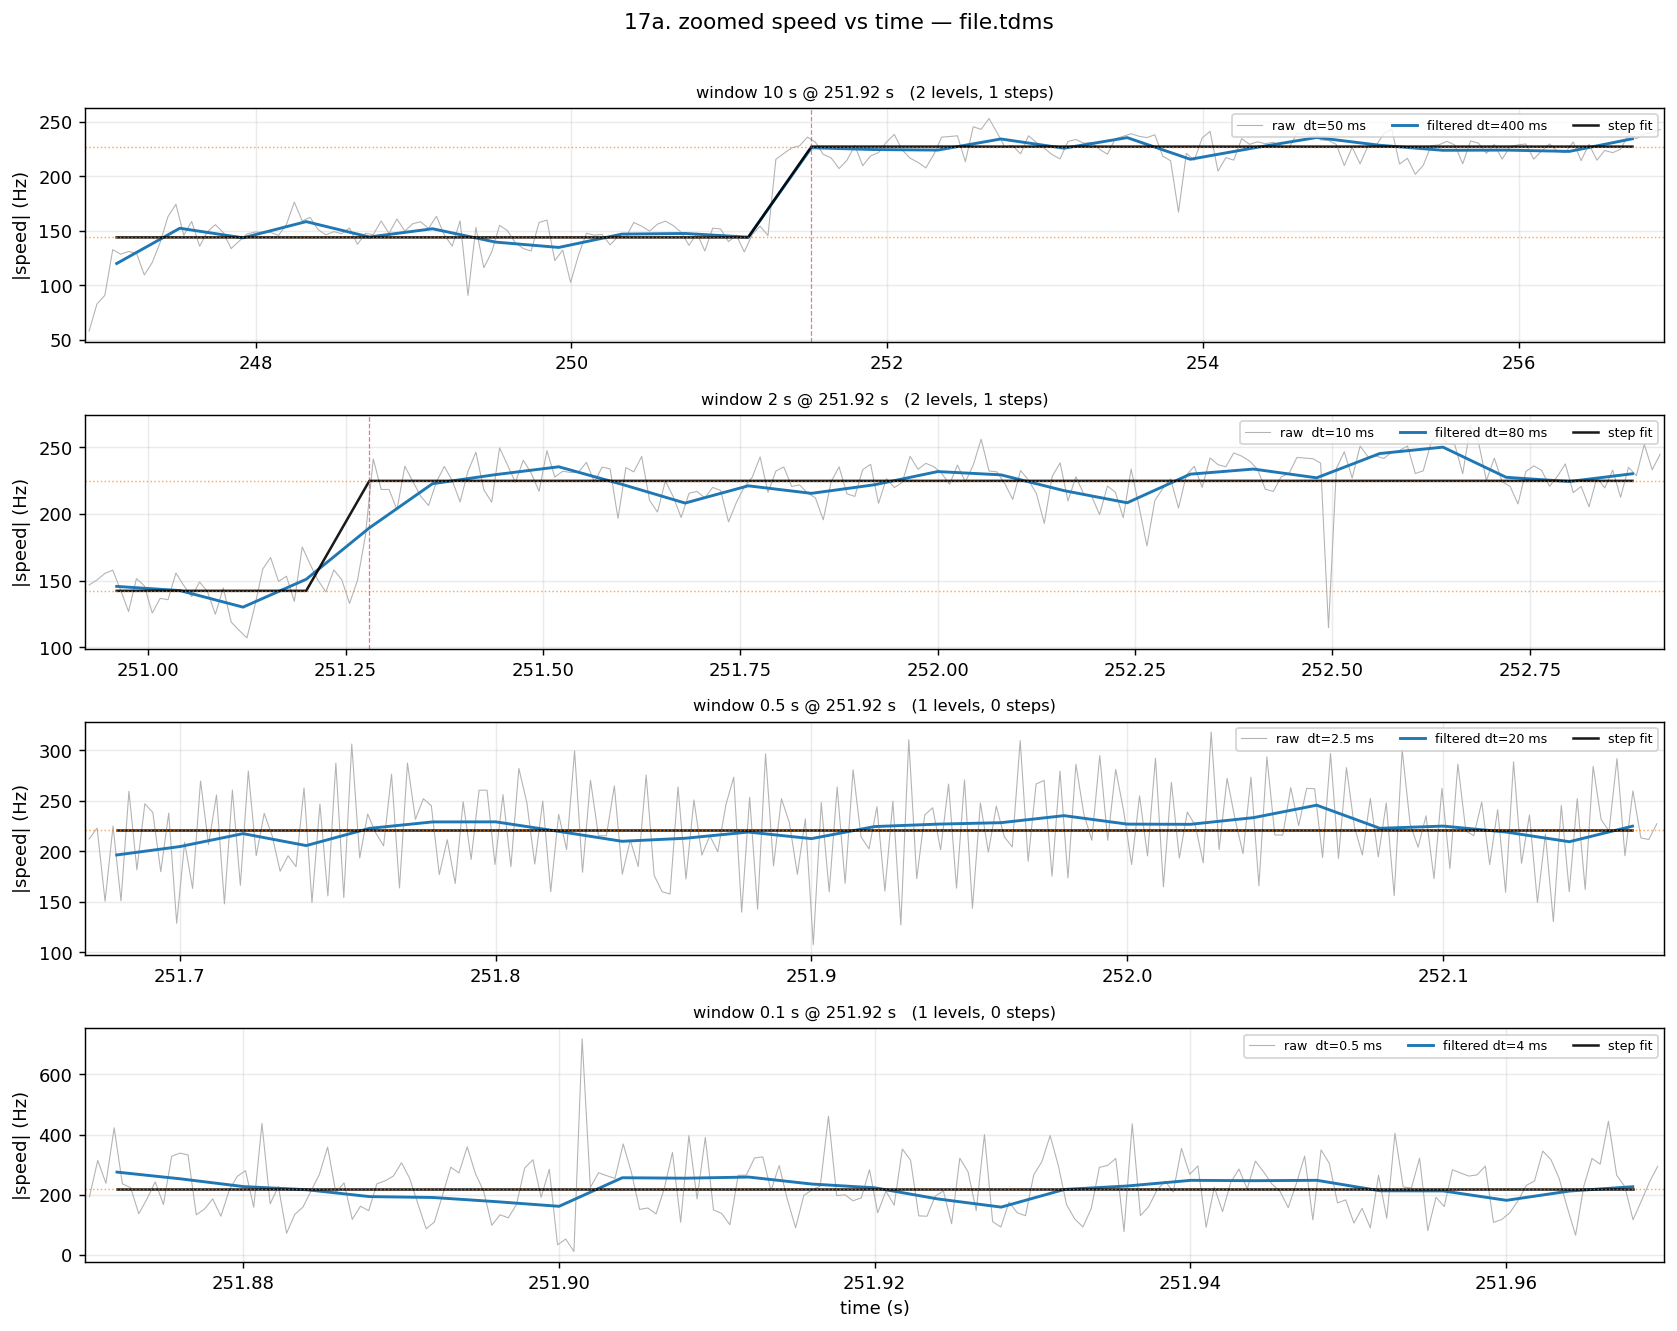

saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\17_speed_survey\17a_zoom_speed_251.92s.png


In [215]:
# ── 17a. Zoomed multi-timescale speed vs time (raw + filtered + change-points) ─
# "Speed vs time, raw and filtered, at different timescales" — zoomed onto a clean
# stepping patch (a 13b/13c winner) and progressively narrowed so we can see whether
# discrete speed levels emerge as the window becomes more stationary.
#   speed = windowed least-squares slope of psi / 2π  (speed_at_dt). The averaging
#   time `dt` IS the filter: small dt = raw/noisy, larger dt = filtered. Change-points
#   (black) are the penalised-L2 fit from fit_steps at the panel's filtered dt; dashed
#   orange lines are the candidate discrete speed levels, dashed red the step edges.
ZOOM_ANCHOR  = 251.92                  # s — centre of the zoom (winner #4; try 31.75)
ZOOM_WINDOWS = [10.0, 2.0, 0.5, 0.1]   # s, largest -> smallest
ZOOM_PENK    = 8.0                     # change-point penalty for the overlay fit

_zdir = _output_dir / "17_speed_survey"; _zdir.mkdir(parents=True, exist_ok=True)
_lo_clip = max(CLEAN_ROT[0], float(_TPH[0]))
_hi_clip = min(CLEAN_ROT[1], float(_TPH[-1]))

def _dt_pair(W):
    dt_raw  = float(np.clip(W / 200.0, 4.0 / _FS_EFF, W / 10.0))
    dt_filt = float(np.clip(W / 25.0,  8.0 / _FS_EFF, W / 4.0))
    return dt_raw, dt_filt

fig, axes = plt.subplots(len(ZOOM_WINDOWS), 1,
                         figsize=(13, 2.6 * len(ZOOM_WINDOWS)), dpi=130)
axes = np.atleast_1d(axes)
for ax, W in zip(axes, ZOOM_WINDOWS):
    t0 = max(_lo_clip, ZOOM_ANCHOR - W / 2.0); t1 = min(_hi_clip, t0 + W)
    t0 = max(_lo_clip, t1 - W)
    dt_raw, dt_filt = _dt_pair(W)

    tr_, vr_ = speed_at_dt(dt_raw,  t0=t0, t1=t1)
    tf_, vf_ = speed_at_dt(dt_filt, t0=t0, t1=t1)
    vr_ = np.abs(vr_); vf_ = np.abs(vf_)

    ax.plot(tr_, vr_, lw=0.6, color="0.70", label=f"raw  dt={dt_raw*1e3:.3g} ms")
    ax.plot(tf_, vf_, lw=1.6, color="tab:blue", label=f"filtered dt={dt_filt*1e3:.3g} ms")

    r_ = fit_steps(t0, t1, dt=dt_filt, penk=ZOOM_PENK)
    if len(r_["t"]) > 3:
        ax.plot(r_["t"], r_["fit"], lw=1.4, color="k", alpha=0.9, label="step fit")
        for lv in r_["levels"]:
            ax.axhline(lv, color="tab:orange", ls=":", lw=0.8, alpha=0.7)
        for e in r_["edges"]:
            ax.axvline(e, color="tab:red", ls="--", lw=0.7, alpha=0.6)

    ax.set_xlim(t0, t1); ax.set_ylabel("|speed| (Hz)")
    ax.set_title(f"window {W:g} s @ {ZOOM_ANCHOR:g} s   "
                 f"({len(r_['levels'])} levels, {len(r_['steps'])} steps)", fontsize=9)
    ax.grid(alpha=0.25); ax.legend(fontsize=7, loc="upper right", ncol=3)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"17a. zoomed speed vs time — {Path(tdms_path).name}", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(_zdir / f"17a_zoom_speed_{ZOOM_ANCHOR:.2f}s.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved: {_zdir / f'17a_zoom_speed_{ZOOM_ANCHOR:.2f}s.png'}")


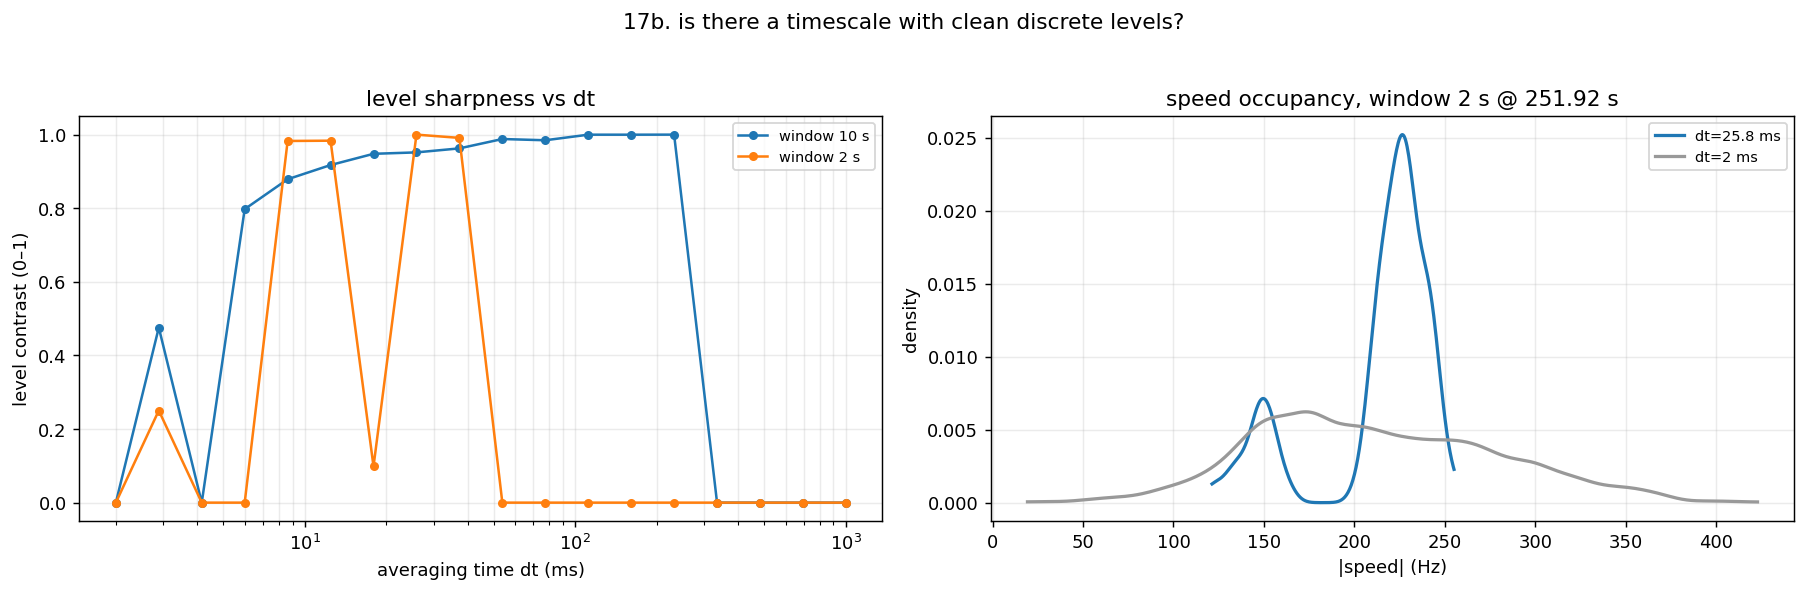

window 10 s: best dt=232 ms  contrast=1.00  (2 peaks)
window 2 s: best dt=25.8 ms  contrast=1.00  (2 peaks)
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\17_speed_survey\17b_dt_sweep_251.92s.png


In [216]:
# ── 17b. Does a timescale give clean discrete levels?  dt sweep + sharpness ────
# For a fixed zoom window we sweep the averaging time dt and measure how cleanly
# the |speed| occupancy separates into discrete levels. "Level contrast" = depth
# of the deepest trough between the two tallest KDE peaks, normalised to the lower
# peak (0 = unimodal smear, 1 = fully separated). We run it for two window sizes
# to test the hypothesis that SHORTER (more stationary) windows give cleaner levels.
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

SWEEP_WINDOWS = [10.0, 2.0]                                   # s, anchored at ZOOM_ANCHOR
SWEEP_DTS = np.logspace(np.log10(2e-3), np.log10(1.0), 18)    # 2 ms .. 1 s

_zdir = _output_dir / "17_speed_survey"; _zdir.mkdir(parents=True, exist_ok=True)
_lo_clip = max(CLEAN_ROT[0], float(_TPH[0]))
_hi_clip = min(CLEAN_ROT[1], float(_TPH[-1]))

def _level_contrast(v):
    """Return (contrast in 0..1, n_peaks) of the |speed| KDE occupancy."""
    v = np.abs(np.asarray(v, float)); v = v[np.isfinite(v)]
    if v.size < 40 or np.ptp(v) < 1e-6:
        return 0.0, 0
    g = np.linspace(v.min(), v.max(), 400)
    try:
        k = gaussian_kde(v, bw_method=0.15)(g)
    except Exception:
        return 0.0, 0
    pk, _ = find_peaks(k, prominence=k.max() * 0.05)
    if pk.size < 2:
        return 0.0, int(pk.size)
    two = pk[np.argsort(k[pk])[-2:]]
    a, b = int(min(two)), int(max(two))
    trough = k[a:b + 1].min()
    contrast = 1.0 - trough / max(k[a], k[b])
    return float(np.clip(contrast, 0.0, 1.0)), int(pk.size)

# linkage corner (from Section 14 if it has been run) for context
try:
    _tau_c = float(_tau_c_ms) * 1e-3
except Exception:
    _tau_c = None

fig, (axM, axH) = plt.subplots(1, 2, figsize=(14, 4.6), dpi=130)
_best = {}
for W in SWEEP_WINDOWS:
    t0 = max(_lo_clip, ZOOM_ANCHOR - W / 2.0); t1 = min(_hi_clip, t0 + W)
    t0 = max(_lo_clip, t1 - W)
    con = []; npk = []
    for dt in SWEEP_DTS:
        _, v_ = speed_at_dt(dt, t0=t0, t1=t1)
        c_, n_ = _level_contrast(v_)
        con.append(c_); npk.append(n_)
    con = np.array(con)
    axM.semilogx(SWEEP_DTS * 1e3, con, "o-", lw=1.4, ms=4, label=f"window {W:g} s")
    _bi = int(np.argmax(con))
    _best[W] = (float(SWEEP_DTS[_bi]), float(con[_bi]), int(npk[_bi]))

if _tau_c is not None:
    axM.axvline(_tau_c * 1e3, color="0.4", ls=":", lw=1.2)
    axM.text(_tau_c * 1e3, 0.02, f" linkage τc≈{_tau_c*1e3:.0f} ms",
             rotation=90, fontsize=8, va="bottom", ha="left", color="0.4")
axM.set_xlabel("averaging time dt (ms)"); axM.set_ylabel("level contrast (0–1)")
axM.set_title("level sharpness vs dt"); axM.grid(alpha=0.25, which="both")
axM.legend(fontsize=8)

# occupancy KDEs at the best dt vs the extremes, for the SMALLEST sweep window
W = SWEEP_WINDOWS[-1]
t0 = max(_lo_clip, ZOOM_ANCHOR - W / 2.0); t1 = min(_hi_clip, t0 + W)
t0 = max(_lo_clip, t1 - W)
for dt, sty in zip([_best[W][0], float(SWEEP_DTS[0]), float(SWEEP_DTS[-1])],
                   ["tab:blue", "0.6", "tab:red"]):
    _, v_ = speed_at_dt(dt, t0=t0, t1=t1); v_ = np.abs(v_); v_ = v_[np.isfinite(v_)]
    if v_.size > 10 and np.ptp(v_) > 1e-6:
        g = np.linspace(v_.min(), v_.max(), 300)
        k = gaussian_kde(v_, bw_method=0.15)(g)
        axH.plot(g, k, color=sty, lw=1.8, label=f"dt={dt*1e3:.3g} ms")
axH.set_xlabel("|speed| (Hz)"); axH.set_ylabel("density")
axH.set_title(f"speed occupancy, window {W:g} s @ {ZOOM_ANCHOR:g} s")
axH.grid(alpha=0.25); axH.legend(fontsize=8)
fig.suptitle("17b. is there a timescale with clean discrete levels?", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(_zdir / f"17b_dt_sweep_{ZOOM_ANCHOR:.2f}s.png", dpi=140, bbox_inches="tight")
plt.show()
for W in SWEEP_WINDOWS:
    dtb, cb, nb = _best[W]
    print(f"window {W:g} s: best dt={dtb*1e3:.3g} ms  contrast={cb:.2f}  ({nb} peaks)")
print(f"saved: {_zdir / f'17b_dt_sweep_{ZOOM_ANCHOR:.2f}s.png'}")


## 18. Apples-to-apples: treat the nanorod like the BFM reference data

The published BFM `.p` files look like clean staircases largely because their
**derived speed carries an undocumented low-pass** (the paper's methods only go up
to the angle $\theta=\arctan(y/x)$ at the 1 kHz camera rate; nothing is said about
how speed is computed). We measured that low-pass on the longest single-stator
dwells in each bead file:

| bead | $\tau_{1/e}$ of speed fluctuation | AC at 1 ms |
|------|----------------------------------|-----------|
| 300 nm | 483 ms | 1.000 |
| 500 nm | 406 ms | 0.999 |
| 1300 nm | 331 ms | 0.995 |

An *unfiltered* 1 ms speed estimate would decorrelate within ~1 sample
(AC ≈ 0 at 1 ms). Theirs stays ≈ 1 out to hundreds of ms ⇒ effective smoothing
$\tau\sim0.3$–$0.5$ s (see `Archive/inspect_plots/bfm_prefilter_evidence.png`).

So the fair comparison is **not** nanorod speed at 1 ms vs BFM "1 ms". Below we:

1. compute the nanorod speed at `dt = 1 ms` (matching the BFM *camera* sampling),
2. apply the **same low-pass** (Gaussian with $\sigma=\tau/2$, so a white input
   reproduces AC$_{1/e}=\tau$) for the three BFM $\tau$ values, and
3. show what happens to the within-state spread and to any apparent levels.

The expected conclusion: the nanorod's real structure lives **below** the BFM
smoothing window, so applying their recipe **erases** it — i.e. the BFM staircases
owe much of their cleanliness to (a) huge bead drag (physical low-pass) and
(b) this analysis low-pass, neither of which apply to the lightly-loaded nanorod.


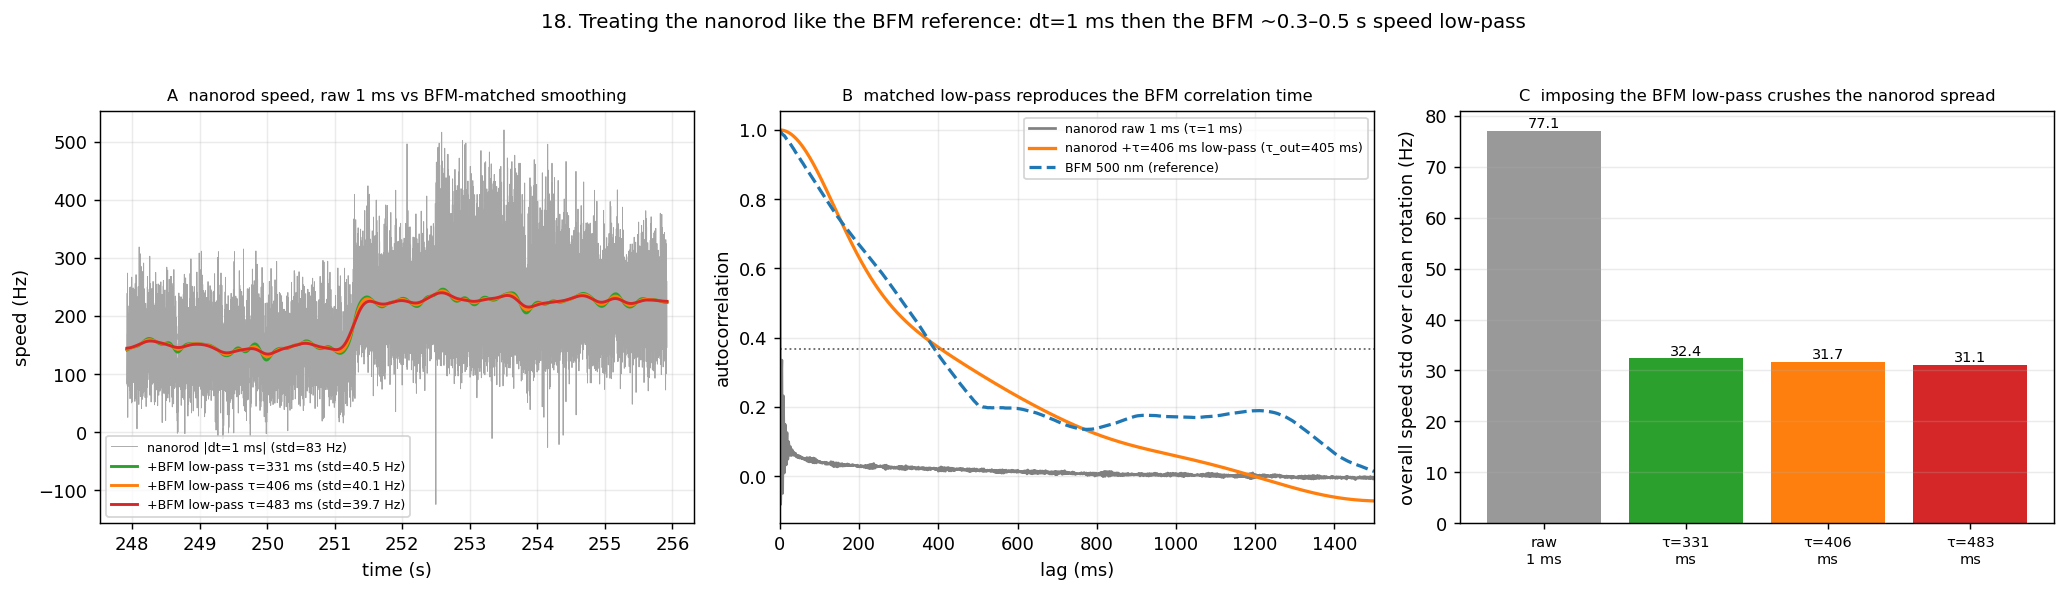

nanorod speed over clean rotation [0.10, 310.90] s at dt=1 ms: n=310,800, mean=194.6 Hz, std=77.1 Hz
raw 1 ms autocorr 1/e = 1 ms  (BFM is ~330–480 ms)
  +matched low-pass τ=331 ms -> std=32.4 Hz (42% of raw)
  +matched low-pass τ=406 ms -> std=31.7 Hz (41% of raw)
  +matched low-pass τ=483 ms -> std=31.1 Hz (40% of raw)
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\18_bfm_matched\18_bfm_matched_smoothing.png


In [217]:
# ── 18. Apply the BFM speed low-pass to the nanorod (dt=1 ms, then matched smoothing) ──
# BFM effective smoothing times (1/e autocorrelation of the within-dwell speed
# fluctuation), measured on the longest single-stator dwell of each bead file.
from scipy.ndimage import gaussian_filter1d

BFM_TAU_MS = {300: 483.0, 500: 406.0, 1300: 331.0}   # ms, per bead size
_BFM_NPZ   = Path("Archive/inspect_plots/bfm_dwell_examples.npz")

_18dir = _output_dir / "18_bfm_matched"; _18dir.mkdir(parents=True, exist_ok=True)
_lo = max(CLEAN_ROT[0], float(_TPH[0])); _hi = min(CLEAN_ROT[1], float(_TPH[-1]))

# 1) nanorod speed at the BFM CAMERA rate: dt = 1 ms, contiguous (overlap=0 -> 1 kHz)
DT_CAM = 1e-3
t_ms, v_ms = speed_at_dt(DT_CAM, t0=_lo, t1=_hi)       # v in Hz, signed
v_ms = np.asarray(v_ms, float); t_ms = np.asarray(t_ms, float)
_ok  = np.isfinite(v_ms); t_ms, v_ms = t_ms[_ok], v_ms[_ok]
_fs_cam = 1.0 / DT_CAM                                  # 1000 Hz, == BFM

def _ac_fft(v):
    """Normalised autocorrelation via FFT (fast for long series)."""
    x = np.asarray(v, float); x = x - x.mean()
    n = 1 << int(np.ceil(np.log2(2 * x.size)))
    f = np.fft.rfft(x, n)
    ac = np.fft.irfft(f * np.conj(f), n)[:x.size]
    return ac / ac[0]

_DETREND_SAMP = 3000                                   # 3 s Gaussian high-pass

def _ac_1e_ms(v, fs=_fs_cam):
    ac = _ac_fft(v - gaussian_filter1d(v, _DETREND_SAMP, mode="nearest"))
    return float(np.argmax(ac < 1.0 / np.e)) / fs * 1e3, ac

def _matched_lowpass(v, tau_ms, fs=_fs_cam):
    """Gaussian low-pass calibrated so the smoothed-then-detrended speed has
    autocorrelation 1/e == tau_ms — i.e. it actually matches the BFM correlation
    time, instead of relying on the white-input sigma=tau/2 approximation."""
    lo, hi = 5.0, 800.0                                # search sigma (ms)
    for _ in range(22):
        mid = 0.5 * (lo + hi)
        t1e, _ = _ac_1e_ms(gaussian_filter1d(v, mid * 1e-3 * fs, mode="nearest"), fs)
        if t1e < tau_ms:                               # under-smoothed -> more sigma
            lo = mid
        else:
            hi = mid
    return gaussian_filter1d(v, 0.5 * (lo + hi) * 1e-3 * fs, mode="nearest")

# 2) smoothed versions, each calibrated to reproduce its BFM tau
v_lp = {tau: _matched_lowpass(v_ms, tau) for tau in BFM_TAU_MS.values()}

# autocorrelation of the nanorod (raw 1 ms) and of a representative smoothed copy
_tau_rep = BFM_TAU_MS[500]                              # ~406 ms, mid bead
ac_raw_1e, ac_raw = _ac_1e_ms(v_ms)
ac_lp_1e, ac_lp = _ac_1e_ms(v_lp[_tau_rep])

# ---- figure ----------------------------------------------------------------
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(16, 4.6), dpi=130)

# Panel A: time-domain zoom around ZOOM_ANCHOR (~8 s)
_w = 8.0
_c = float(np.clip(ZOOM_ANCHOR, _lo + _w / 2, _hi - _w / 2))
_sel = (t_ms >= _c - _w / 2) & (t_ms <= _c + _w / 2)
axA.plot(t_ms[_sel], v_ms[_sel], lw=0.5, color="0.65",
         label=f"nanorod |dt=1 ms| (std={v_ms[_sel].std():.0f} Hz)")
for tau, col in zip(sorted(BFM_TAU_MS.values()), ["tab:green", "tab:orange", "tab:red"]):
    axA.plot(t_ms[_sel], v_lp[tau][_sel], lw=1.6, color=col,
             label=f"+BFM low-pass τ={tau:.0f} ms (std={v_lp[tau][_sel].std():.1f} Hz)")
axA.set_xlabel("time (s)"); axA.set_ylabel("speed (Hz)")
axA.set_title("A  nanorod speed, raw 1 ms vs BFM-matched smoothing", fontsize=9)
axA.grid(alpha=0.25); axA.legend(fontsize=7, loc="best")

# Panel B: autocorrelation — confirm we reproduce the BFM correlation time
_lag = np.arange(ac_raw.size) / _fs_cam * 1e3
_m = _lag <= 1500
axB.plot(_lag[_m], ac_raw[_m], lw=1.5, color="0.5",
         label=f"nanorod raw 1 ms (τ={ac_raw_1e:.0f} ms)")
axB.plot(_lag[_m], ac_lp[_m], lw=1.8, color="tab:orange",
         label=f"nanorod +τ={_tau_rep:.0f} ms low-pass (τ_out={ac_lp_1e:.0f} ms)")
if _BFM_NPZ.exists():
    _d = np.load(_BFM_NPZ)
    _bfm = _d["500nm_speed"].astype(float)
    _bf = _bfm - gaussian_filter1d(_bfm, 3000, mode="nearest")
    _xb = _bf - _bf.mean()
    _acb = np.correlate(_xb, _xb, "full")[_xb.size - 1:]; _acb /= _acb[0]
    _lb = np.arange(_acb.size) / 1000.0 * 1e3
    _mb = _lb <= 1500
    axB.plot(_lb[_mb], _acb[_mb], lw=1.8, ls="--", color="tab:blue",
             label="BFM 500 nm (reference)")
axB.axhline(1 / np.e, ls=":", color="0.4", lw=1)
axB.set_xlabel("lag (ms)"); axB.set_ylabel("autocorrelation")
axB.set_title("B  matched low-pass reproduces the BFM correlation time", fontsize=9)
axB.set_xlim(0, 1500); axB.grid(alpha=0.25); axB.legend(fontsize=7, loc="upper right")

# Panel C: within-state spread collapses as we impose the BFM smoothing
_taus = [0.0] + sorted(BFM_TAU_MS.values())
_stds = [v_ms.std()] + [v_lp[t].std() for t in sorted(BFM_TAU_MS.values())]
_lbls = ["raw\n1 ms"] + [f"τ={t:.0f}\nms" for t in sorted(BFM_TAU_MS.values())]
_bars = axC.bar(range(len(_stds)), _stds,
                color=["0.6", "tab:green", "tab:orange", "tab:red"])
for _b, _s in zip(_bars, _stds):
    axC.text(_b.get_x() + _b.get_width() / 2, _s, f"{_s:.1f}",
             ha="center", va="bottom", fontsize=8)
axC.set_xticks(range(len(_stds))); axC.set_xticklabels(_lbls, fontsize=8)
axC.set_ylabel("overall speed std over clean rotation (Hz)")
axC.set_title("C  imposing the BFM low-pass crushes the nanorod spread", fontsize=9)
axC.grid(alpha=0.25, axis="y")

fig.suptitle("18. Treating the nanorod like the BFM reference: dt=1 ms then the BFM "
             "~0.3–0.5 s speed low-pass", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(_18dir / "18_bfm_matched_smoothing.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"nanorod speed over clean rotation [{_lo:.2f}, {_hi:.2f}] s at dt=1 ms: "
      f"n={v_ms.size:,}, mean={v_ms.mean():.1f} Hz, std={v_ms.std():.1f} Hz")
print(f"raw 1 ms autocorr 1/e = {ac_raw_1e:.0f} ms  (BFM is ~330–480 ms)")
for tau in sorted(BFM_TAU_MS.values()):
    print(f"  +matched low-pass τ={tau:.0f} ms -> std={v_lp[tau].std():.1f} Hz "
          f"({v_lp[tau].std() / v_ms.std() * 100:.0f}% of raw)")
print(f"saved: {_18dir / '18_bfm_matched_smoothing.png'}")


## 19. Slope-fit vs endpoint speed, and our own 0.4 s smoothing test

**Why least-squares slope, not $\Delta\psi/\Delta t$ from the two endpoints?**
Both measure the same average rotation rate over a window of width `dt`, but they
treat measurement noise very differently. Each $\psi$ sample carries an independent
tracking/photon noise $\sigma$. Over a window of $N$ samples (at `dt=1 ms`,
$N=\texttt{dt}/\texttt{_DTP}=1\,\text{ms}/40\,\mu\text{s}=25$):

| estimator | what it uses | noise variance |
|-----------|--------------|----------------|
| **endpoint** $\;(\psi_N-\psi_1)/T$ | only the **2** end samples | $\operatorname{Var}=2\sigma^2/T^2$ |
| **LS slope** (our `speed_at_dt`) | **all $N$** samples | $\operatorname{Var}=\dfrac{12\,\sigma^2}{T^2}\dfrac{N-1}{N(N+1)}\approx\dfrac{12\sigma^2}{N\,T^2}$ |

So the noise ratio is

$$\frac{\sigma_{\text{LS}}}{\sigma_{\text{endpoint}}}=\sqrt{\frac{6(N-1)}{N(N+1)}}\;\xrightarrow{N=25}\;0.47 .$$

The endpoint difference throws away the 23 interior points, so its noise is fixed by
just two samples no matter how finely you sample; the LS slope averages all of them
and is **~2× less noisy** at `dt=1 ms` — **but only if the $\psi$-noise is white**.
The LS slope is also the *maximum-likelihood* rate under white $\psi$-noise, a gentle
low-pass (ramp kernel) instead of the endpoint difference (a bare high-pass that
**amplifies** noise), and it is **robust to a single bad endpoint sample** (the
endpoint estimator is fully exposed to an outlier at either end). Both are unbiased
for a constant rate; for a curved $\psi(t)$ both report the window-average rate.

> **What we actually measure (see code below):** at `dt=1 ms` the LS and endpoint
> speeds have **the same scatter** (ratio ≈ 1.0, not 0.47) and disagree by only a few
> Hz. That means the 1 ms scatter is **not white tracking noise** — averaging the
> interior samples buys nothing — it is **genuine sub-millisecond motion**. This is
> itself the point: our nanorod really resolves fast dynamics, which is exactly why
> the BFM-style 0.4 s smoothing below is erasing *signal*, not noise. We still keep
> the LS slope as the default (ML-optimal, robust, and it does win once white noise
> dominates or `dt` grows).

**Then the BFM test on our own data:** take the `dt=1 ms` LS speed and apply the
same ~0.4 s low-pass the BFM analysis silently used, and look at the trace with and
without it.


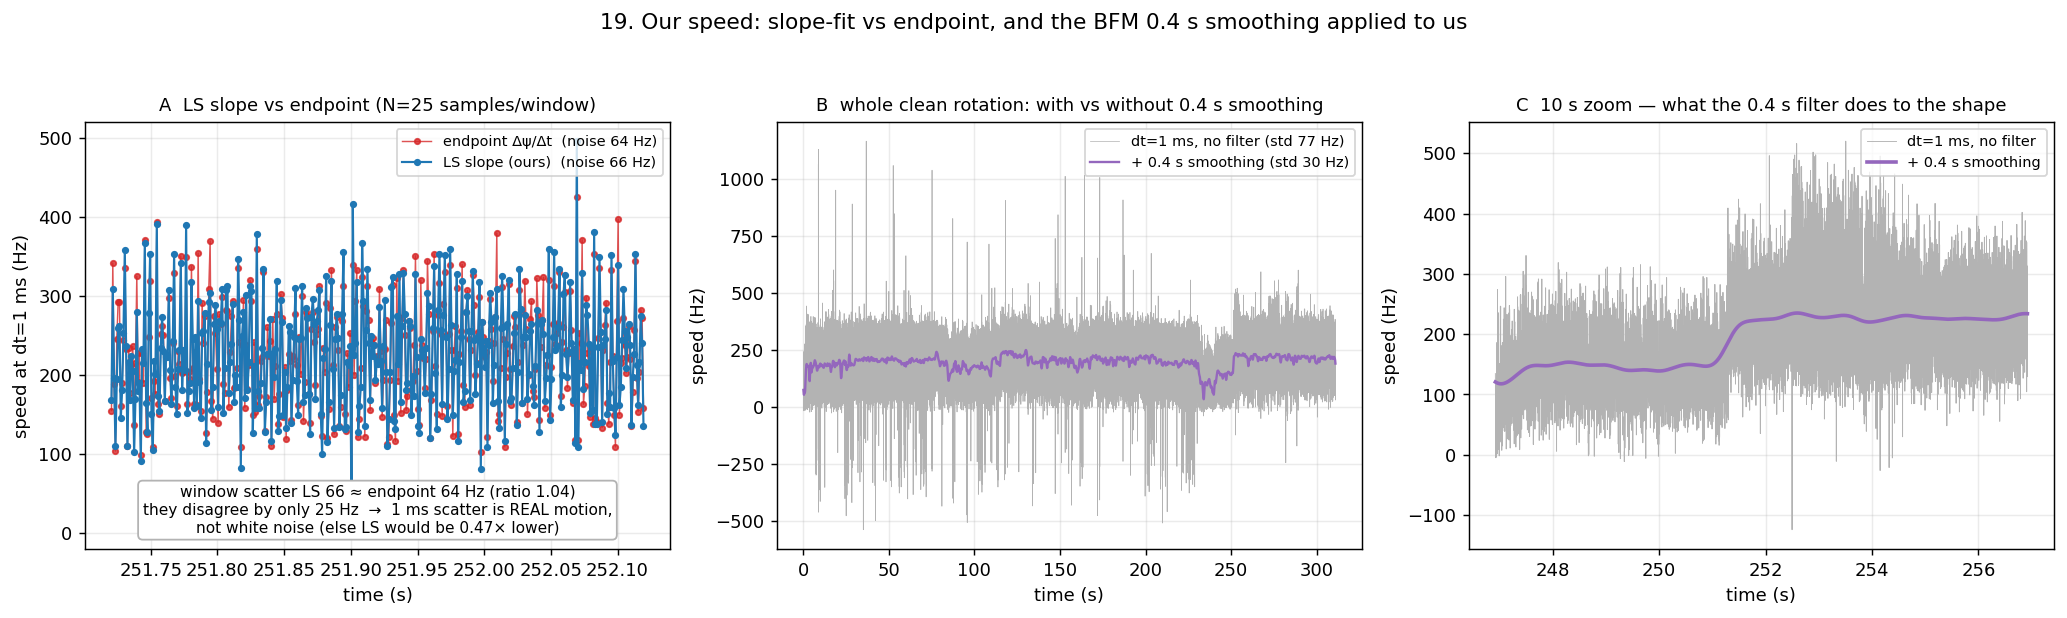

dt=1 ms over clean rotation [0.10, 310.90] s, N=25 samples/window
  LS-slope   speed: mean 194.6 Hz, overall std 77.1 Hz, high-freq noise 65.9 Hz
  endpoint   speed: mean 194.6 Hz, overall std 75.1 Hz, high-freq noise 63.6 Hz
  noise ratio LS/endpoint measured 1.036  vs white-noise theory 0.471
  LS vs endpoint disagree by only 25.1 Hz (<< 66 Hz scatter)
  => within-window psi scatter is correlated REAL motion, not white noise,
     so averaging interior points (LS) gives ~no noise win at dt=1 ms here.
     LS is still preferred: ML-optimal for white noise, robust to a bad
     endpoint sample, and wins at larger dt (more independent samples).
  + 0.4 s smoothing: std 77.1 -> 30.2 Hz (39% of unfiltered)
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\19_speed_filtering\19_speed_filtering.png


In [218]:
# ── 19. LS-slope vs endpoint noise + dt=1 ms with/without 0.4 s smoothing ──────
from scipy.ndimage import gaussian_filter1d

SMOOTH_TAU_S = 0.4                                  # BFM-style effective smoothing
_lo = max(CLEAN_ROT[0], float(_TPH[0])); _hi = min(CLEAN_ROT[1], float(_TPH[-1]))
_DT = 1e-3                                           # 1 ms windows  ->  N = 25 samples

def _speed_two_ways(dt, t0, t1):
    """Return (t_centres, v_LS, v_endpoint) in Hz over [t0,t1] at window dt."""
    npw = max(5, int(round(dt / _DTP)))
    sel = (_TPH >= t0) & (_TPH <= t1)
    p = psi[sel]; t = _TPH[sel]
    n = len(p) // npw
    tc = np.empty(n); vls = np.empty(n); vep = np.empty(n)
    for w in range(n):
        a = w * npw; b = a + npw; tt = t[a:b] - t[a]
        vls[w] = np.polyfit(tt, p[a:b], 1)[0] / (2.0 * np.pi)        # all N samples
        vep[w] = (p[b - 1] - p[a]) / (t[b - 1] - t[a]) / (2.0 * np.pi)  # 2 endpoints
        tc[w]  = 0.5 * (t[a] + t[b - 1])
    return tc, vls, vep, npw

t_c, v_ls, v_ep, _N = _speed_two_ways(_DT, _lo, _hi)
_fs = 1.0 / _DT

# high-frequency NOISE proxy = std of adjacent-window differences / sqrt(2)
def _noise(v):
    return np.std(np.diff(v)) / np.sqrt(2.0)
_n_ls, _n_ep = _noise(v_ls), _noise(v_ep)
_theory = np.sqrt(6.0 * (_N - 1) / (_N * (_N + 1)))
# how much the two estimators actually DISAGREE (pure noise-driven part):
# for purely real linear motion in a window LS==endpoint, so their difference
# isolates the white-noise contribution.
_disagree = np.std(v_ls - v_ep)

# 0.4 s low-pass on the dt=1 ms LS speed: Gaussian sigma = tau/2 -> AC 1/e ~ tau
v_sm = gaussian_filter1d(v_ls, (SMOOTH_TAU_S / 2.0) * _fs, mode="nearest")

_19dir = _output_dir / "19_speed_filtering"; _19dir.mkdir(parents=True, exist_ok=True)
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(16, 4.8), dpi=130)

# Panel A: endpoint vs LS on a short zoom — endpoint is visibly noisier
_w = 0.4
_c = float(np.clip(ZOOM_ANCHOR, _lo + _w, _hi - _w))
_m = (t_c >= _c - _w / 2) & (t_c <= _c + _w / 2)
axA.plot(t_c[_m], v_ep[_m], "-o", ms=3, lw=0.8, color="tab:red", alpha=0.8,
         label=f"endpoint Δψ/Δt  (noise {_n_ep:.0f} Hz)")
axA.plot(t_c[_m], v_ls[_m], "-o", ms=3, lw=1.2, color="tab:blue",
         label=f"LS slope (ours)  (noise {_n_ls:.0f} Hz)")
axA.set_xlabel("time (s)"); axA.set_ylabel("speed at dt=1 ms (Hz)")
axA.set_title(f"A  LS slope vs endpoint (N={_N} samples/window)", fontsize=10)
axA.text(0.5, 0.04,
         f"window scatter LS {_n_ls:.0f} ≈ endpoint {_n_ep:.0f} Hz (ratio {_n_ls/_n_ep:.2f})\n"
         f"they disagree by only {_disagree:.0f} Hz  →  1 ms scatter is REAL motion,\n"
         f"not white noise (else LS would be {_theory:.2f}× lower)",
         transform=axA.transAxes, ha="center", fontsize=8.5,
         bbox=dict(boxstyle="round", fc="white", ec="0.7"))
axA.grid(alpha=0.25); axA.legend(fontsize=8, loc="upper right")

# Panel B: full clean rotation — raw 1 ms vs 0.4 s-smoothed
axB.plot(t_c, v_ls, lw=0.4, color="0.7",
         label=f"dt=1 ms, no filter (std {v_ls.std():.0f} Hz)")
axB.plot(t_c, v_sm, lw=1.3, color="tab:purple",
         label=f"+ {SMOOTH_TAU_S:g} s smoothing (std {v_sm.std():.0f} Hz)")
axB.set_xlabel("time (s)"); axB.set_ylabel("speed (Hz)")
axB.set_title("B  whole clean rotation: with vs without 0.4 s smoothing", fontsize=10)
axB.grid(alpha=0.25); axB.legend(fontsize=8, loc="upper right")

# Panel C: 10 s zoom so the shape change is visible
_wz = 10.0
_cz = float(np.clip(ZOOM_ANCHOR, _lo + _wz, _hi - _wz))
_mz = (t_c >= _cz - _wz / 2) & (t_c <= _cz + _wz / 2)
axC.plot(t_c[_mz], v_ls[_mz], lw=0.5, color="0.7", label="dt=1 ms, no filter")
axC.plot(t_c[_mz], v_sm[_mz], lw=2.0, color="tab:purple", label=f"+ {SMOOTH_TAU_S:g} s smoothing")
axC.set_xlabel("time (s)"); axC.set_ylabel("speed (Hz)")
axC.set_title("C  10 s zoom — what the 0.4 s filter does to the shape", fontsize=10)
axC.grid(alpha=0.25); axC.legend(fontsize=8, loc="upper right")

fig.suptitle("19. Our speed: slope-fit vs endpoint, and the BFM 0.4 s smoothing applied to us",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(_19dir / "19_speed_filtering.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"dt=1 ms over clean rotation [{_lo:.2f}, {_hi:.2f}] s, N={_N} samples/window")
print(f"  LS-slope   speed: mean {v_ls.mean():.1f} Hz, overall std {v_ls.std():.1f} Hz, "
      f"high-freq noise {_n_ls:.1f} Hz")
print(f"  endpoint   speed: mean {v_ep.mean():.1f} Hz, overall std {v_ep.std():.1f} Hz, "
      f"high-freq noise {_n_ep:.1f} Hz")
print(f"  noise ratio LS/endpoint measured {_n_ls/_n_ep:.3f}  vs white-noise theory {_theory:.3f}")
print(f"  LS vs endpoint disagree by only {_disagree:.1f} Hz (<< {_n_ls:.0f} Hz scatter)")
print(f"  => within-window psi scatter is correlated REAL motion, not white noise,")
print(f"     so averaging interior points (LS) gives ~no noise win at dt=1 ms here.")
print(f"     LS is still preferred: ML-optimal for white noise, robust to a bad")
print(f"     endpoint sample, and wins at larger dt (more independent samples).")
print(f"  + {SMOOTH_TAU_S:g} s smoothing: std {v_ls.std():.1f} -> {v_sm.std():.1f} Hz "
      f"({v_sm.std()/v_ls.std()*100:.0f}% of unfiltered)")
print(f"saved: {_19dir / '19_speed_filtering.png'}")


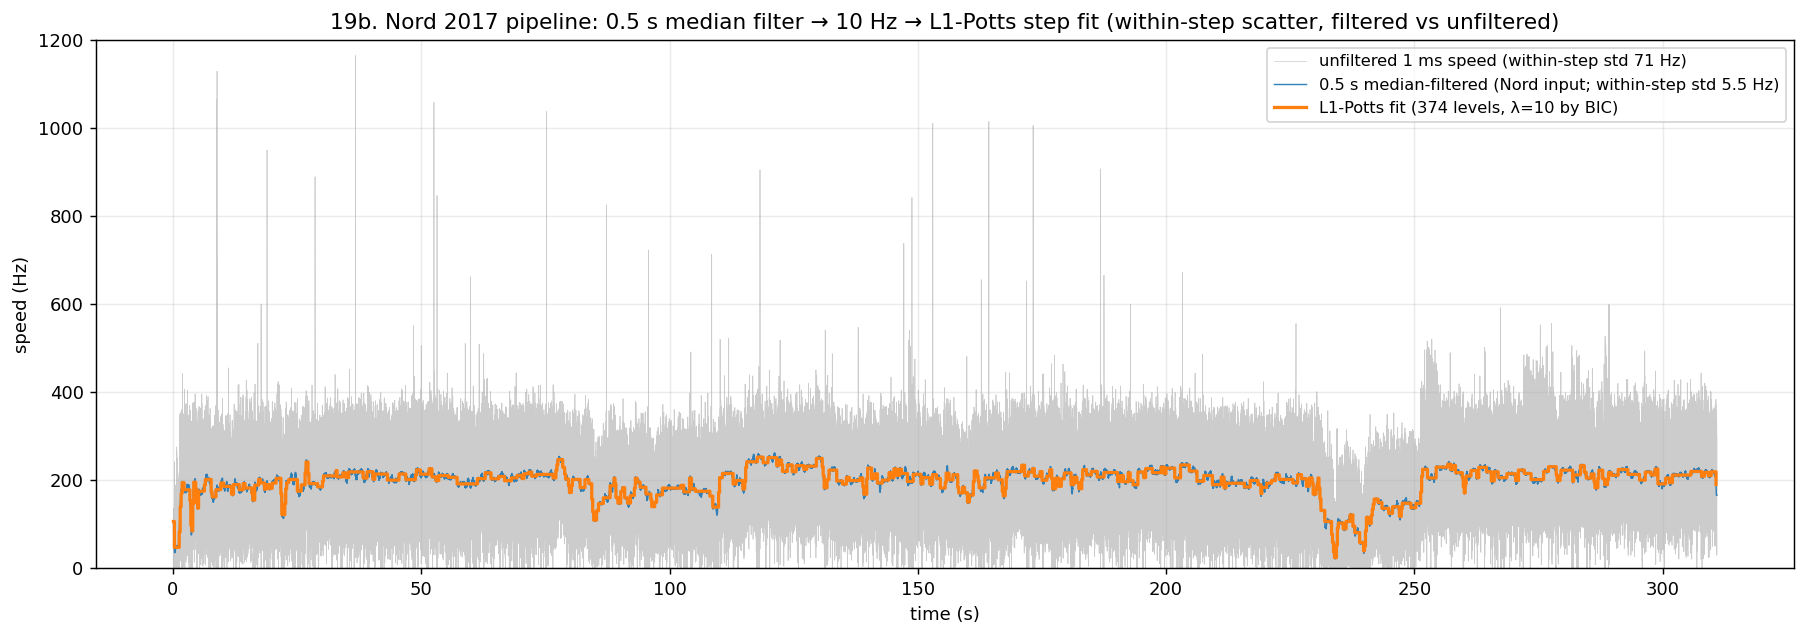

Nord 2017 step-detection pipeline applied to our speed
  1) 0.5 s median filter (window 501 samp @ 1000 Hz)
  2) downsample -> 5.1 Hz (1594 pts; stride 195; Nord used 10 Hz, capped at 1600 for the exact DP)
  3) L1-Potts fit, λ chosen by BIC = 10
     BIC sweep (λ, #levels, BIC):
       λ=     10.0  levels=374  BIC=     7029.4  <- picked
       λ=     23.3  levels=169  BIC=     7096.1
       λ=     54.1  levels= 78  BIC=     7561.6
       λ=    126.0  levels= 28  BIC=     8309.5
       λ=    293.2  levels= 13  BIC=     8717.2
       λ=    682.2  levels=  9  BIC=     8960.2
       λ=   1587.4  levels=  3  BIC=    10156.0
       λ=   3693.8  levels=  3  BIC=    10156.0
       λ=   8595.1  levels=  1  BIC=    11171.1
       λ=  20000.0  levels=  1  BIC=    11171.1
  -> 374 levels / 373 steps  (steps kept as fitted)
  median dwell 0.59 s, median |step| 14.7 Hz, step range -58.8..63.0 Hz

  WITHIN-STEP std (about each step's own mean — comparable to BFM bead):
    0.5 s median-filtered : po

In [219]:
# ── 19b. Nord et al. 2017 step-detection pipeline, applied to our speed ───────
# Faithful reproduction of the BFM step-detection method cited by Perez-Carrasco/
# Nord 2022 (operational details in Nord et al. 2017 PNAS, "Catch bond drives
# stator mechanosensitivity…"). Their pipeline:
#     1 kHz tracking -> angle -> speed
#     -> MEDIAN-FILTER speed with a 0.5 s window
#     -> DOWNSAMPLE to 10 Hz (to cut computation)
#     -> L1-POTTS fit: û = argmin_u  Σ_i |y_i − u_i| + λ·#jumps(u)   (PottsLab)
#     -> λ chosen by a BIC sweep (smallest λ past which residuals stop improving)
# They fit TORQUE (τ = γω); since τ is just drag × speed, fitting speed (Hz) gives
# the identical staircase up to a constant, and keeps within-step std in Hz so it
# is directly comparable to the BFM bead numbers. We start from the UNFILTERED
# 1 ms LS speed v_ls (from §19) — NOT the §19 Gaussian trace.
import heapq
from scipy.ndimage import median_filter

MEDFILT_S     = 0.5      # Nord: 0.5 s median filter on speed/torque
POTTS_DS_HZ   = 10.0     # Nord: downsample to 10 Hz before fitting
POTTS_MAXPTS  = 1600     # cap pts for the exact O(n^2) L1-Potts DP (raise for true 10 Hz)
POTTS_LAMBDA_GRID = np.geomspace(10.0, 2.0e4, 10)   # λ sweep (Hz·samples); BIC picks one
DRAG_PNNM_S   = 8.0e-4   # nanorod rotational drag γ (pN·nm·s/rad) — for a torque note

def _l1_potts(y, lam):
    """Exact L1-Potts DP:  min_u  Σ|y−u| + lam·#jumps.  Returns (bnds, levels).
    Per-segment L1 optimum is the median; segment cost = Σ|y−median| computed
    incrementally with a two-heap running-median SAD (O(n^2) overall)."""
    n = len(y)
    if n == 0:
        return [], np.array([])
    best = np.full(n + 1, np.inf); best[0] = -lam
    back = np.zeros(n + 1, int)
    for r in range(1, n + 1):
        lo = []; hi = []                 # lo: max-heap (neg), hi: min-heap
        slo = shi = 0.0; nlo = nhi = 0
        best_c = np.inf; best_l = 0
        for l in range(r - 1, -1, -1):   # grow segment [l, r) leftward
            x = float(y[l])
            if nlo == 0 or x <= -lo[0]:
                heapq.heappush(lo, -x); slo += x; nlo += 1
            else:
                heapq.heappush(hi, x); shi += x; nhi += 1
            if nlo > nhi + 1:
                v = -heapq.heappop(lo); slo -= v; nlo -= 1
                heapq.heappush(hi, v); shi += v; nhi += 1
            elif nhi > nlo:
                v = heapq.heappop(hi); shi -= v; nhi -= 1
                heapq.heappush(lo, -v); slo += v; nlo += 1
            med = -lo[0]
            sad = (med * nlo - slo) + (shi - med * nhi)
            c = best[l] + sad + lam
            if c < best_c:
                best_c = c; best_l = l
        best[r] = best_c; back[r] = best_l
    bnds = []; j = n
    while j > 0:
        i = back[j]; bnds.append((i, j)); j = i
    bnds.reverse()
    levels = np.array([np.median(y[a:b]) for a, b in bnds])
    return bnds, levels

# ── Nord preprocessing: 0.5 s median filter on the 1 ms speed, then downsample ──
_fs   = 1.0 / np.median(np.diff(t_c))                    # ≈ 1000 Hz (dt = 1 ms grid)
_mw   = int(round(MEDFILT_S * _fs)) | 1                  # odd window
v_med = median_filter(v_ls, size=_mw, mode="nearest")   # 0.5 s median-filtered speed
_ds   = max(int(round(_fs / POTTS_DS_HZ)),
            int(np.ceil(len(v_ls) / POTTS_MAXPTS)))      # honour 10 Hz, cap for the DP
_idx  = np.arange(0, len(v_ls), _ds)
_yv   = v_med[_idx]; _tv = t_c[_idx]
_fs_ds = _fs / _ds

# ── BIC sweep over λ (Nord: smallest λ past which residuals stop improving) ─────
_bic_rows = []
for _lam in POTTS_LAMBDA_GRID:
    _bn, _lv = _l1_potts(_yv, _lam)
    _u = np.empty_like(_yv)
    for (a, b), lv in zip(_bn, _lv):
        _u[a:b] = lv
    _rss = float(np.sum((_yv - _u) ** 2))
    _k = len(_lv)                                         # #levels = #free means
    _bic = len(_yv) * np.log(_rss / len(_yv) + 1e-12) + _k * np.log(len(_yv))
    _bic_rows.append((_lam, _k, _rss, _bic))
_lam_best = min(_bic_rows, key=lambda rr: rr[3])[0]

_bnds, _levels = _l1_potts(_yv, _lam_best)
_vstep = np.empty_like(_yv)
for (a, b), lv in zip(_bnds, _levels):
    _vstep[a:b] = lv

# ── WITHIN-STEP scatter (comparable to BFM "std within a held stator state") ───
# Keep the L1-Potts boundaries as fitted; map each segment back to the FULL 1 ms
# grid and measure scatter about that segment's own mean, for the 0.5 s median-
# filtered speed (Nord's fit input) and the UNFILTERED 1 ms speed.
def _within_step_std(v_full):
    per = []; resid = []
    for a, b in _bnds:
        fa = _idx[a]; fb = _idx[b] if b < len(_idx) else len(v_full)
        seg = v_full[fa:fb]
        if seg.size >= 2:
            per.append(float(np.std(seg))); resid.append(seg - seg.mean())
    per = np.array(per)
    pooled = float(np.sqrt(np.mean(np.concatenate(resid) ** 2))) if resid else np.nan
    return per, pooled

_wstd_med, _pool_med = _within_step_std(v_med)   # 0.5 s median-filtered (Nord input)
_wstd_raw, _pool_raw = _within_step_std(v_ls)    # UNFILTERED 1 ms

_19bdir = _output_dir / "19_speed_filtering"; _19bdir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(14, 5), dpi=130)
ax.plot(t_c, v_ls, lw=0.4, color="0.8", zorder=1,
        label=f"unfiltered 1 ms speed (within-step std {_pool_raw:.0f} Hz)")
ax.plot(t_c, v_med, lw=0.8, color="tab:blue", alpha=0.9, zorder=2,
        label=f"{MEDFILT_S:g} s median-filtered (Nord input; within-step std {_pool_med:.1f} Hz)")
ax.plot(_tv, _vstep, lw=1.8, color="tab:orange", drawstyle="steps-post", zorder=3,
        label=f"L1-Potts fit ({len(_levels)} levels, λ={_lam_best:.0f} by BIC)")
ax.set_xlabel("time (s)"); ax.set_ylabel("speed (Hz)")
ax.set_title("19b. Nord 2017 pipeline: 0.5 s median filter → 10 Hz → L1-Potts step fit "
             "(within-step scatter, filtered vs unfiltered)")
ax.set_ylim(0, 1200)
ax.grid(alpha=0.25); ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
fig.savefig(_19bdir / "19b_nord_l1potts_stepfit.png", dpi=140, bbox_inches="tight")
plt.show()

_dwell = np.array([_tv[min(b, len(_tv) - 1)] - _tv[a] for a, b in _bnds])
_dlev  = np.diff(_levels)
_tq_med = DRAG_PNNM_S * 2 * np.pi * _pool_med    # within-step torque scatter (pN·nm)
print("Nord 2017 step-detection pipeline applied to our speed")
print(f"  1) {MEDFILT_S:g} s median filter (window {_mw} samp @ {_fs:.0f} Hz)")
print(f"  2) downsample -> {_fs_ds:.1f} Hz ({_yv.size} pts; stride {_ds}; "
      f"Nord used 10 Hz, capped at {POTTS_MAXPTS} for the exact DP)")
print(f"  3) L1-Potts fit, λ chosen by BIC = {_lam_best:.0f}")
print(f"     BIC sweep (λ, #levels, BIC):")
for _lam, _k, _rss, _bic in _bic_rows:
    _mark = "  <- picked" if _lam == _lam_best else ""
    print(f"       λ={_lam:9.1f}  levels={_k:3d}  BIC={_bic:11.1f}{_mark}")
print(f"  -> {len(_levels)} levels / {len(_dlev)} steps  (steps kept as fitted)")
if len(_dlev):
    print(f"  median dwell {np.median(_dwell):.2f} s, "
          f"median |step| {np.median(np.abs(_dlev)):.1f} Hz, "
          f"step range {_dlev.min():.1f}..{_dlev.max():.1f} Hz")
print(f"\n  WITHIN-STEP std (about each step's own mean — comparable to BFM bead):")
print(f"    0.5 s median-filtered : pooled {_pool_med:.2f} Hz  "
      f"(per-step median {np.median(_wstd_med):.2f}, range {_wstd_med.min():.2f}..{_wstd_med.max():.2f} Hz)")
print(f"    UNFILTERED 1 ms       : pooled {_pool_raw:.2f} Hz  "
      f"(per-step median {np.median(_wstd_raw):.2f}, range {_wstd_raw.min():.2f}..{_wstd_raw.max():.2f} Hz)")
print(f"    => the 0.5 s median filter shrinks within-step scatter "
      f"{_pool_raw:.0f} -> {_pool_med:.1f} Hz ({_pool_med/_pool_raw*100:.0f}% of unfiltered)")
print(f"    (as torque: γ·2π·{_pool_med:.1f} Hz = {_tq_med:.3f} pN·nm within-step)")
print(f"  BFM reference within-state std: 300nm 11.3 Hz, 500nm 5.2 Hz, 1300nm 1.08 Hz")
print(f"saved: {_19bdir / '19b_nord_l1potts_stepfit.png'}")


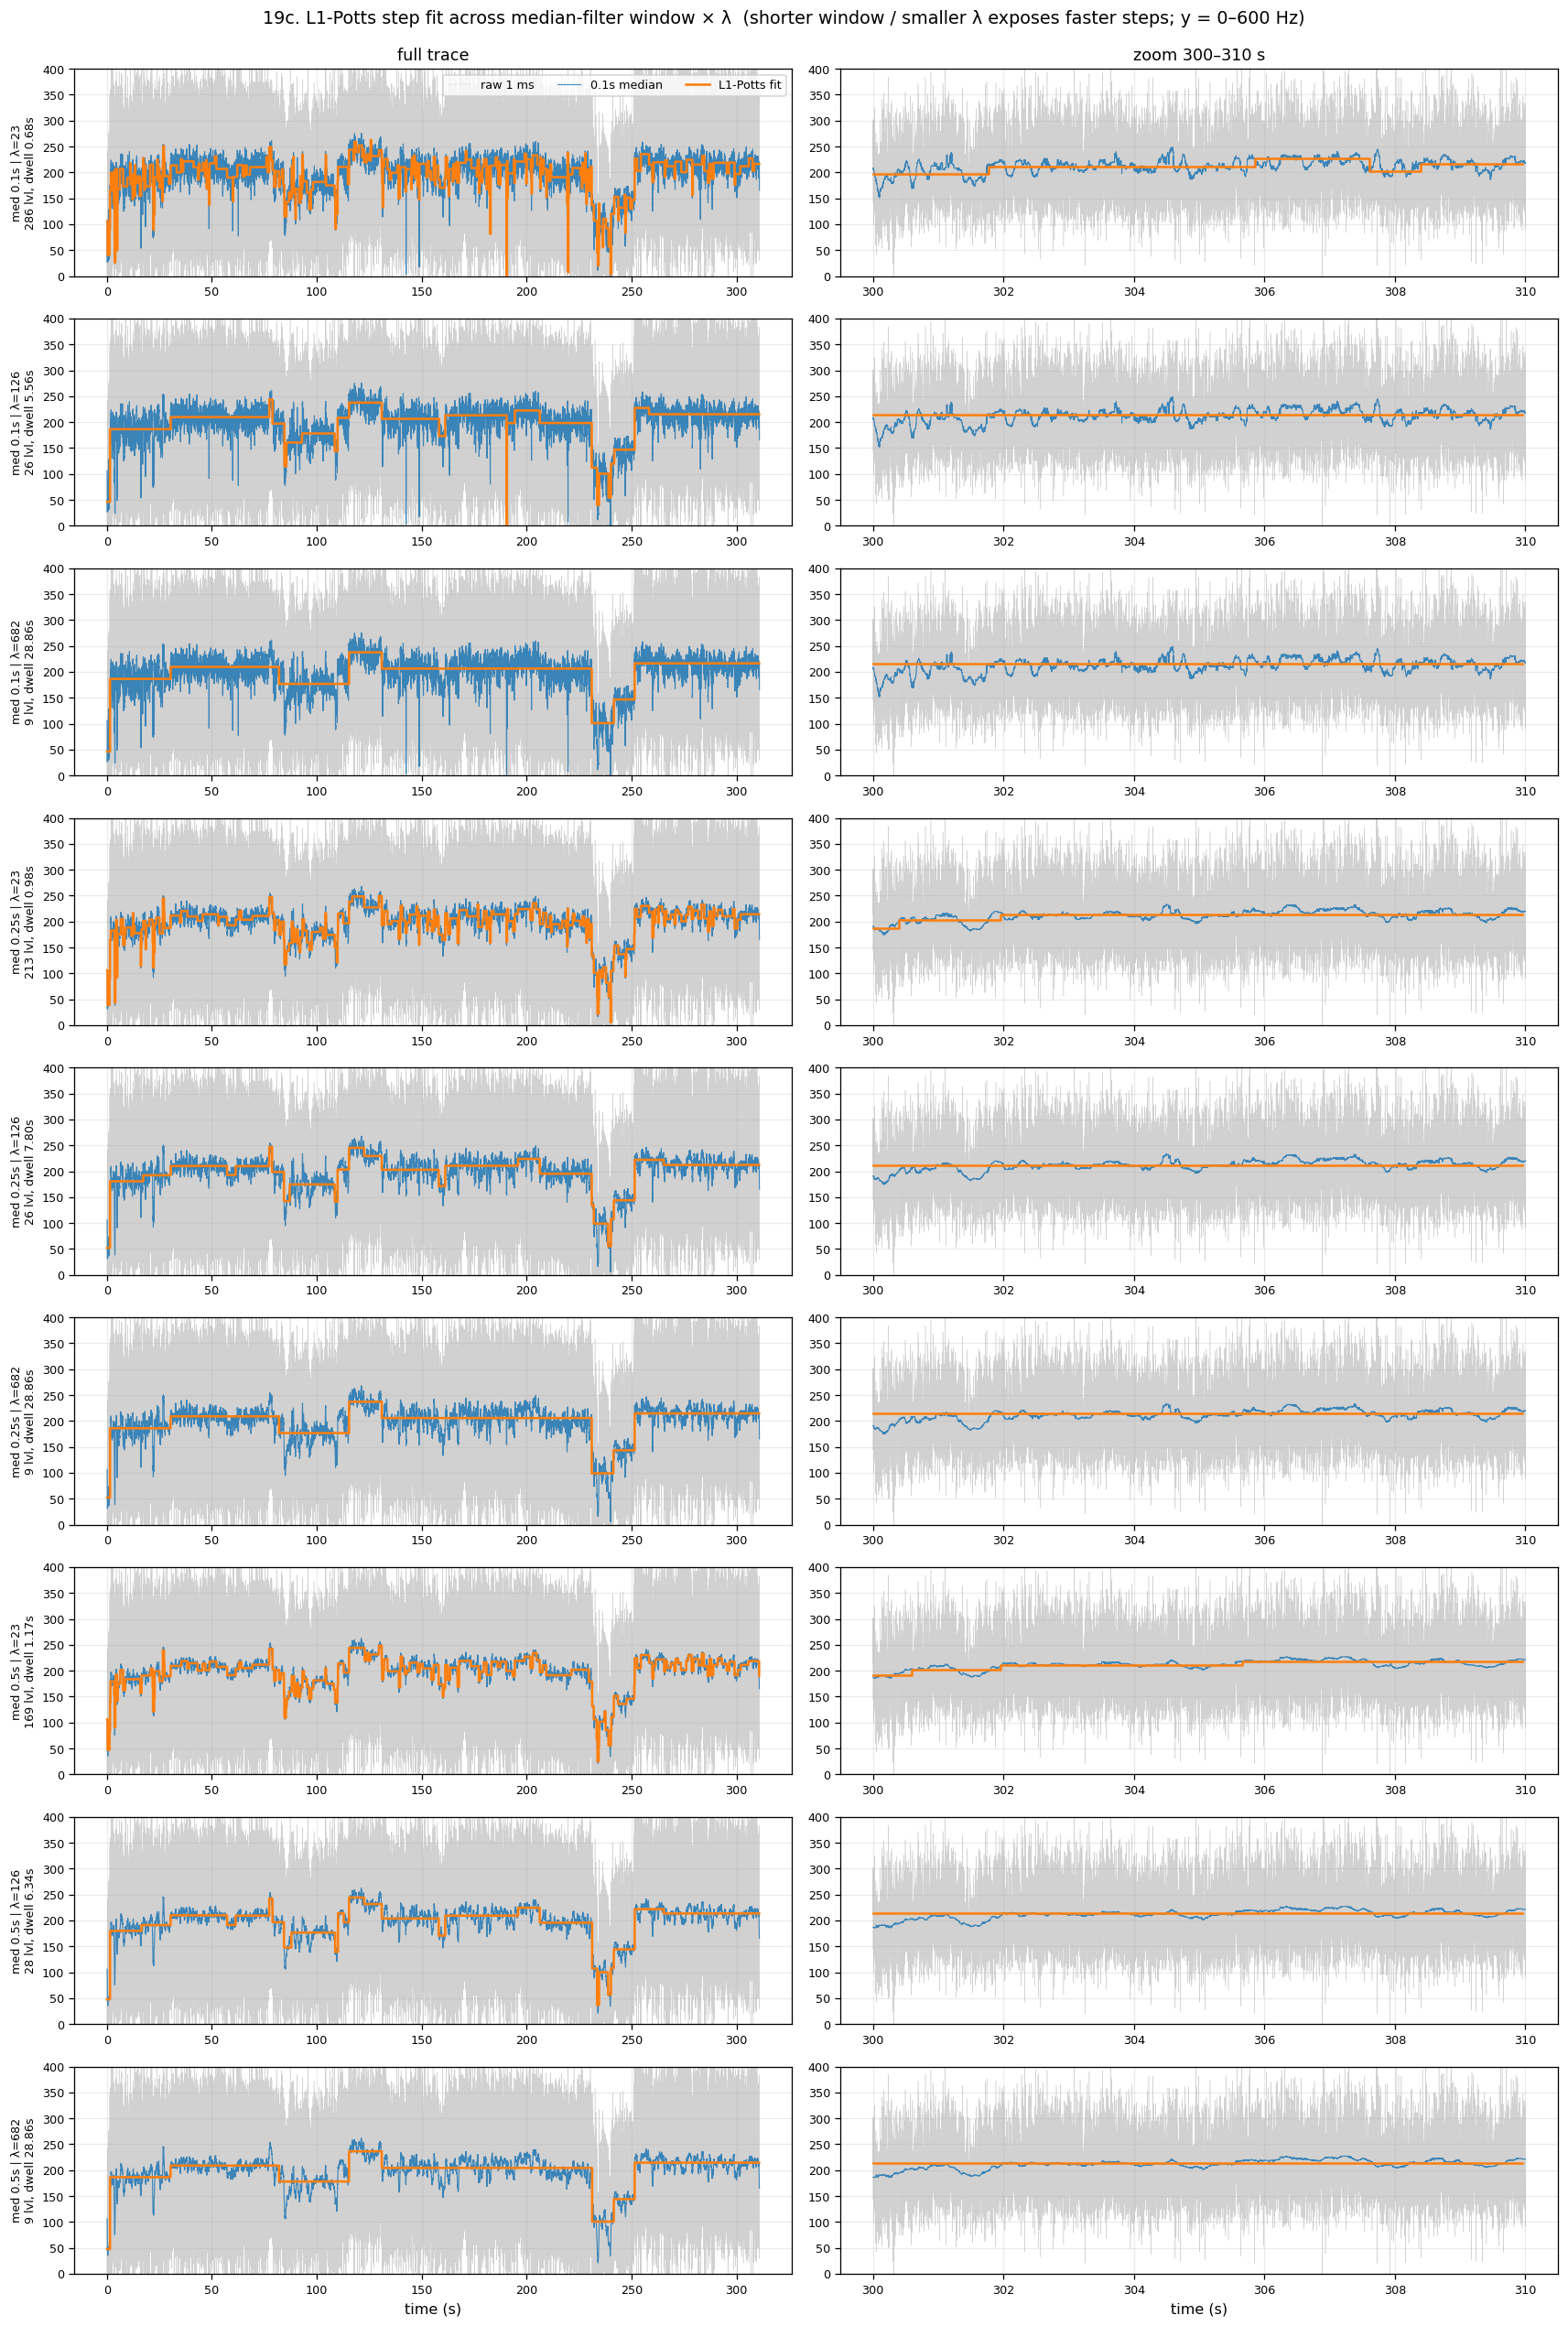

L1-Potts sweep (median-filter window × λ):
 med(s)       λ  #levels  median dwell(s)
   0.10      23      286             0.68
   0.10     126       26             5.56
   0.10     682        9            28.86
   0.25      23      213             0.98
   0.25     126       26             7.80
   0.25     682        9            28.86
   0.50      23      169             1.17
   0.50     126       28             6.34
   0.50     682        9            28.86
  shorter median window -> more/faster steps survive to the fit;
  smaller λ -> Potts keeps finer structure (λ≈23 was the BIC upper bound).
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\19_speed_filtering\19c_potts_window_lambda_sweep.png


In [221]:
# ── 19c. Sweep (median-filter window × L1-Potts λ) — full trace + 100–110 s zoom ─
# Two independent knobs:
#   • median-filter window = the MASKING stage: sets the fastest resolvable step
#     (steps shorter than the window are smeared away before the fit sees them).
#   • λ = the L1-Potts step price: large λ -> few steps, small λ -> many steps.
# BIC picked λ≈23 (≈ the FINEST / upper-bound segmentation), so here we walk λ
# from that fine end up to coarse, and shorten the median window to expose steps
# faster than Nord's 0.5 s. Reuses _l1_potts, median_filter, v_ls, t_c from §19b.
from scipy.ndimage import median_filter

MED_WINDOWS_S = [0.10, 0.25, 0.50]      # median-filter windows to try (Nord = 0.5)
LAMBDAS       = [23.0, 126.0, 682.0]    # fine (BIC pick) -> coarse (BFM-look)
ZOOM_S        = (300.0, 310.0)
SWEEP_DS_HZ   = 10.0                     # Nord downsample target
SWEEP_MAXPTS  = 1600                     # cap for the exact O(n^2) L1-Potts DP

_fs_sw = 1.0 / np.median(np.diff(t_c))   # ≈ 1000 Hz

def _potts_fit_for(win_s, lam):
    """0.5 s-style median filter (win_s) -> 10 Hz downsample -> L1-Potts(lam)."""
    mw = int(round(win_s * _fs_sw)) | 1
    vm = median_filter(v_ls, size=mw, mode="nearest")
    ds = max(int(round(_fs_sw / SWEEP_DS_HZ)), int(np.ceil(len(v_ls) / SWEEP_MAXPTS)))
    idx = np.arange(0, len(v_ls), ds)
    yv = vm[idx]; tv = t_c[idx]
    bn, lv = _l1_potts(yv, lam)
    u = np.empty_like(yv)
    for (a, b), l in zip(bn, lv):
        u[a:b] = l
    # median dwell (s) for a quick readout
    dwell = np.median([tv[min(b, len(tv) - 1)] - tv[a] for a, b in bn]) if bn else np.nan
    return tv, vm, u, len(lv), float(dwell)

_nrows = len(MED_WINDOWS_S) * len(LAMBDAS)
fig, axes = plt.subplots(_nrows, 2, figsize=(15, 2.5 * _nrows), dpi=115, squeeze=False)
_r = 0
for _win in MED_WINDOWS_S:
    for _lam in LAMBDAS:
        _tv, _vm, _u, _nlev, _dw = _potts_fit_for(_win, _lam)
        for _c, (_t0, _t1) in enumerate([(t_c[0], t_c[-1]), ZOOM_S]):
            ax = axes[_r][_c]
            _mr = (t_c >= _t0) & (t_c <= _t1)
            _md = (_tv >= _t0) & (_tv <= _t1)
            ax.plot(t_c[_mr], v_ls[_mr], lw=0.3, color="0.82", zorder=1,
                    label="raw 1 ms" if _r == 0 and _c == 0 else None)
            ax.plot(t_c[_mr], _vm[_mr], lw=0.7, color="tab:blue", alpha=0.85, zorder=2,
                    label=f"{_win:g}s median" if _r == 0 and _c == 0 else None)
            ax.plot(_tv[_md], _u[_md], lw=1.6, color="tab:orange", drawstyle="steps-post",
                    zorder=3, label="L1-Potts fit" if _r == 0 and _c == 0 else None)
            ax.set_ylim(0, 400); ax.grid(alpha=0.25)
            ax.tick_params(labelsize=8)
        axes[_r][0].set_ylabel(f"med {_win:g}s | λ={_lam:g}\n{_nlev} lvl, dwell {_dw:.2f}s",
                               fontsize=8)
        _r += 1
axes[0][0].set_title("full trace", fontsize=11)
axes[0][1].set_title(f"zoom {ZOOM_S[0]:g}–{ZOOM_S[1]:g} s", fontsize=11)
axes[0][0].legend(fontsize=8, loc="upper right", ncol=3)
for _c in range(2):
    axes[-1][_c].set_xlabel("time (s)")
fig.suptitle("19c. L1-Potts step fit across median-filter window × λ  "
             "(shorter window / smaller λ exposes faster steps; y = 0–600 Hz)",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.985])
_19cpath = _19bdir / "19c_potts_window_lambda_sweep.png"
fig.savefig(_19cpath, dpi=135, bbox_inches="tight")
plt.show()

print("L1-Potts sweep (median-filter window × λ):")
print(f"{'med(s)':>7} {'λ':>7} {'#levels':>8} {'median dwell(s)':>16}")
for _win in MED_WINDOWS_S:
    for _lam in LAMBDAS:
        _tv, _vm, _u, _nlev, _dw = _potts_fit_for(_win, _lam)
        print(f"{_win:>7.2f} {_lam:>7.0f} {_nlev:>8d} {_dw:>16.2f}")
print("  shorter median window -> more/faster steps survive to the fit;")
print("  smaller λ -> Potts keeps finer structure (λ≈23 was the BIC upper bound).")
print(f"saved: {_19cpath}")


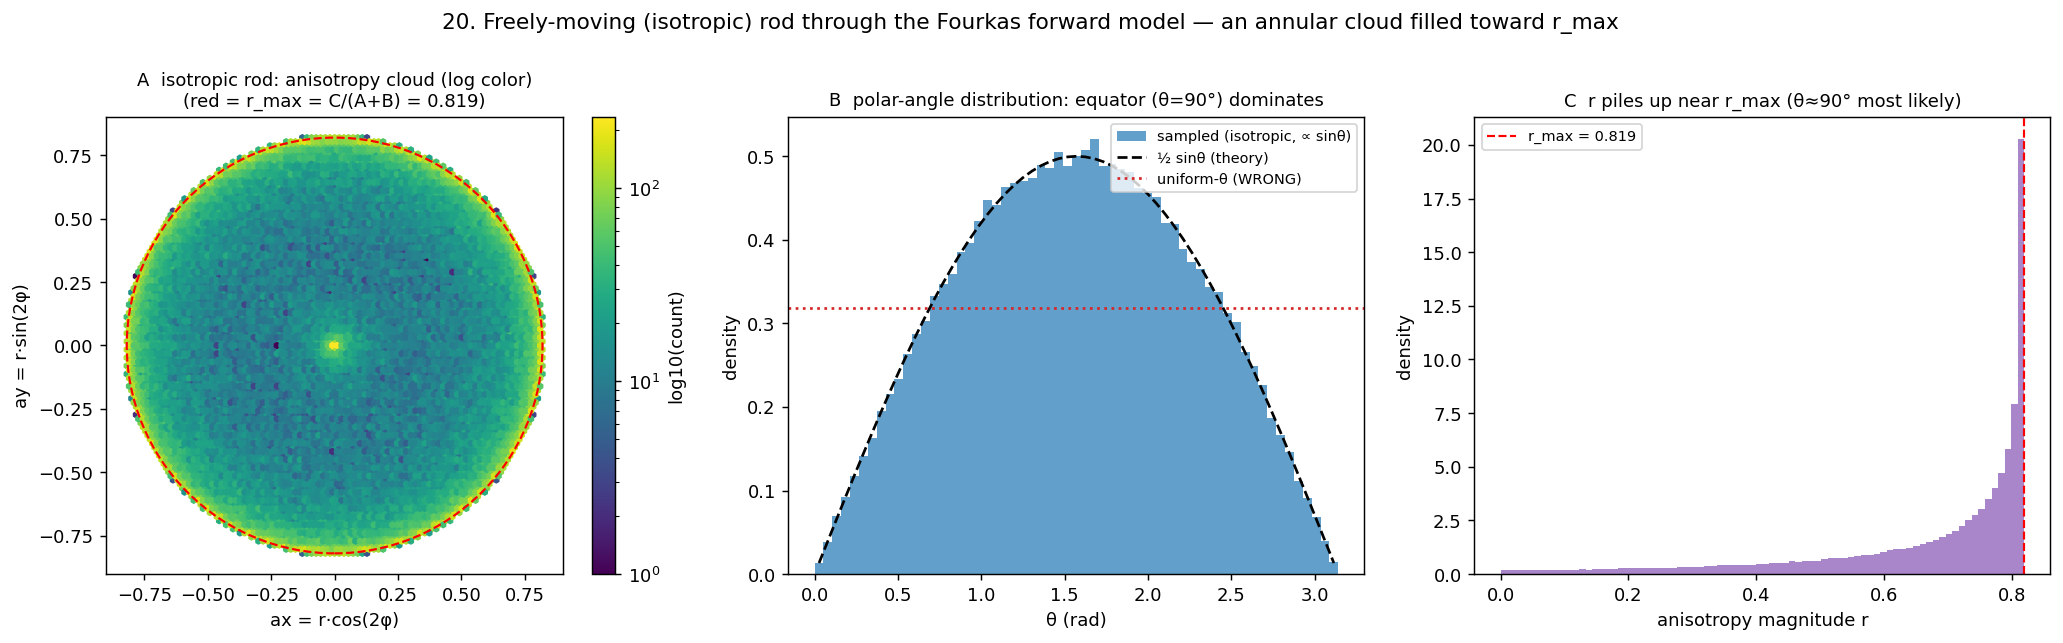

isotropic sim: N=200,000,  A=0.2573 B=0.6514 C=0.7446
  θ: mean 90.1°  (isotropic mean = 90°); most probable θ = 90° because p(θ)=½ sinθ
  r: min 0.000  mean 0.668  max 0.819  (r_max = C/(A+B) = 0.819 at θ=90°)
  cloud shape = annulus (2φ uniform), density rising toward the outer rim.
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\20_isotropic_sim\20_isotropic_anisotropy_cloud.png


In [223]:
# ── 20. Isotropic freely-moving rod: what does the anisotropy cloud look like? ─
# Off-topic sanity sim. If the rod explores ALL orientations isotropically, the
# unit vector d is UNIFORM OVER THE SPHERE (uniform in solid angle dΩ=sinθ dθ dφ),
# NOT uniform in θ. So the θ marginal is p(θ)=½ sinθ: θ=90° (equator) is much more
# likely than θ=0° (pole), simply because there is more sphere area near the
# equator. Correct sampler: draw cosθ ~ Uniform[-1,1] (=> θ=arccos u), φ ~ U[0,2π).
# (Equivalently: normalise a 3D Gaussian.) Sampling θ uniformly would be WRONG.
rng = np.random.default_rng(0)
N_ISO = 200_000

# isotropic directions: cosθ uniform in [-1,1], φ uniform in [0,2π)
cos_th = rng.uniform(-1.0, 1.0, N_ISO)
theta_psi = np.arccos(np.clip(cos_th, -1.0, 1.0))
phi_psi   = rng.uniform(0.0, 2.0 * np.pi, N_ISO)

# Forward Fourkas: θ → r → (ax, ay)   (same A/B/C calibration as the real data)
A, B, C = A_cal, B_cal, C_cal
s2 = np.sin(theta_psi) ** 2
r  = C * s2 / (A + B * s2)
ax_model = r * np.cos(2.0 * phi_psi)
ay_model = r * np.sin(2.0 * phi_psi)

# because φ is uniform, 2φ is uniform on the circle => the cloud is an annulus.
# r depends ONLY on θ; its distribution is set by p(θ)=½ sinθ mapped through
# r(θ)=C sin²θ/(A+B sin²θ). r is maximal at θ=90° (the most probable θ) and 0 at
# the poles, so the cloud piles up near the OUTER radius r_max = C/(A+B).
r_max = C / (A + B)

fig, (axS, axT, axR) = plt.subplots(1, 3, figsize=(16, 5), dpi=130)

# Panel A: the (ax, ay) anisotropy cloud
hb = axS.hexbin(ax_model, ay_model, gridsize=90, cmap="viridis", mincnt=1, bins="log")
axS.add_patch(plt.Circle((0, 0), r_max, fill=False, color="red", lw=1.2, ls="--"))
axS.set_aspect("equal"); axS.set_xlabel("ax = r·cos(2φ)"); axS.set_ylabel("ay = r·sin(2φ)")
axS.set_title(f"A  isotropic rod: anisotropy cloud (log color)\n(red = r_max = C/(A+B) = {r_max:.3f})",
              fontsize=10)
fig.colorbar(hb, ax=axS, label="log10(count)")

# Panel B: θ sampled correctly (∝ sinθ) vs the WRONG uniform-θ, to make the point
_edges = np.linspace(0, np.pi, 60)
axT.hist(theta_psi, bins=_edges, density=True, color="tab:blue", alpha=0.7,
         label="sampled (isotropic, ∝ sinθ)")
_thc = 0.5 * (_edges[:-1] + _edges[1:])
axT.plot(_thc, 0.5 * np.sin(_thc), "k--", lw=1.5, label="½ sinθ (theory)")
axT.axhline(1.0 / np.pi, color="tab:red", ls=":", lw=1.5, label="uniform-θ (WRONG)")
axT.set_xlabel("θ (rad)"); axT.set_ylabel("density"); axT.set_title(
    "B  polar-angle distribution: equator (θ=90°) dominates", fontsize=10)
axT.legend(fontsize=8)

# Panel C: resulting radial (r) distribution of the cloud
axR.hist(r, bins=80, density=True, color="tab:purple", alpha=0.8)
axR.axvline(r_max, color="red", ls="--", lw=1.2, label=f"r_max = {r_max:.3f}")
axR.set_xlabel("anisotropy magnitude r"); axR.set_ylabel("density")
axR.set_title("C  r piles up near r_max (θ≈90° most likely)", fontsize=10)
axR.legend(fontsize=8)

fig.suptitle("20. Freely-moving (isotropic) rod through the Fourkas forward model — "
             "an annular cloud filled toward r_max", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
_20dir = _output_dir / "20_isotropic_sim"; _20dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_20dir / "20_isotropic_anisotropy_cloud.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"isotropic sim: N={N_ISO:,},  A={A:.4g} B={B:.4g} C={C:.4g}")
print(f"  θ: mean {np.degrees(theta_psi.mean()):.1f}°  (isotropic mean = 90°); "
      f"most probable θ = 90° because p(θ)=½ sinθ")
print(f"  r: min {r.min():.3f}  mean {r.mean():.3f}  max {r.max():.3f}  "
      f"(r_max = C/(A+B) = {r_max:.3f} at θ=90°)")
print(f"  cloud shape = annulus (2φ uniform), density rising toward the outer rim.")
print(f"saved: {_20dir / '20_isotropic_anisotropy_cloud.png'}")


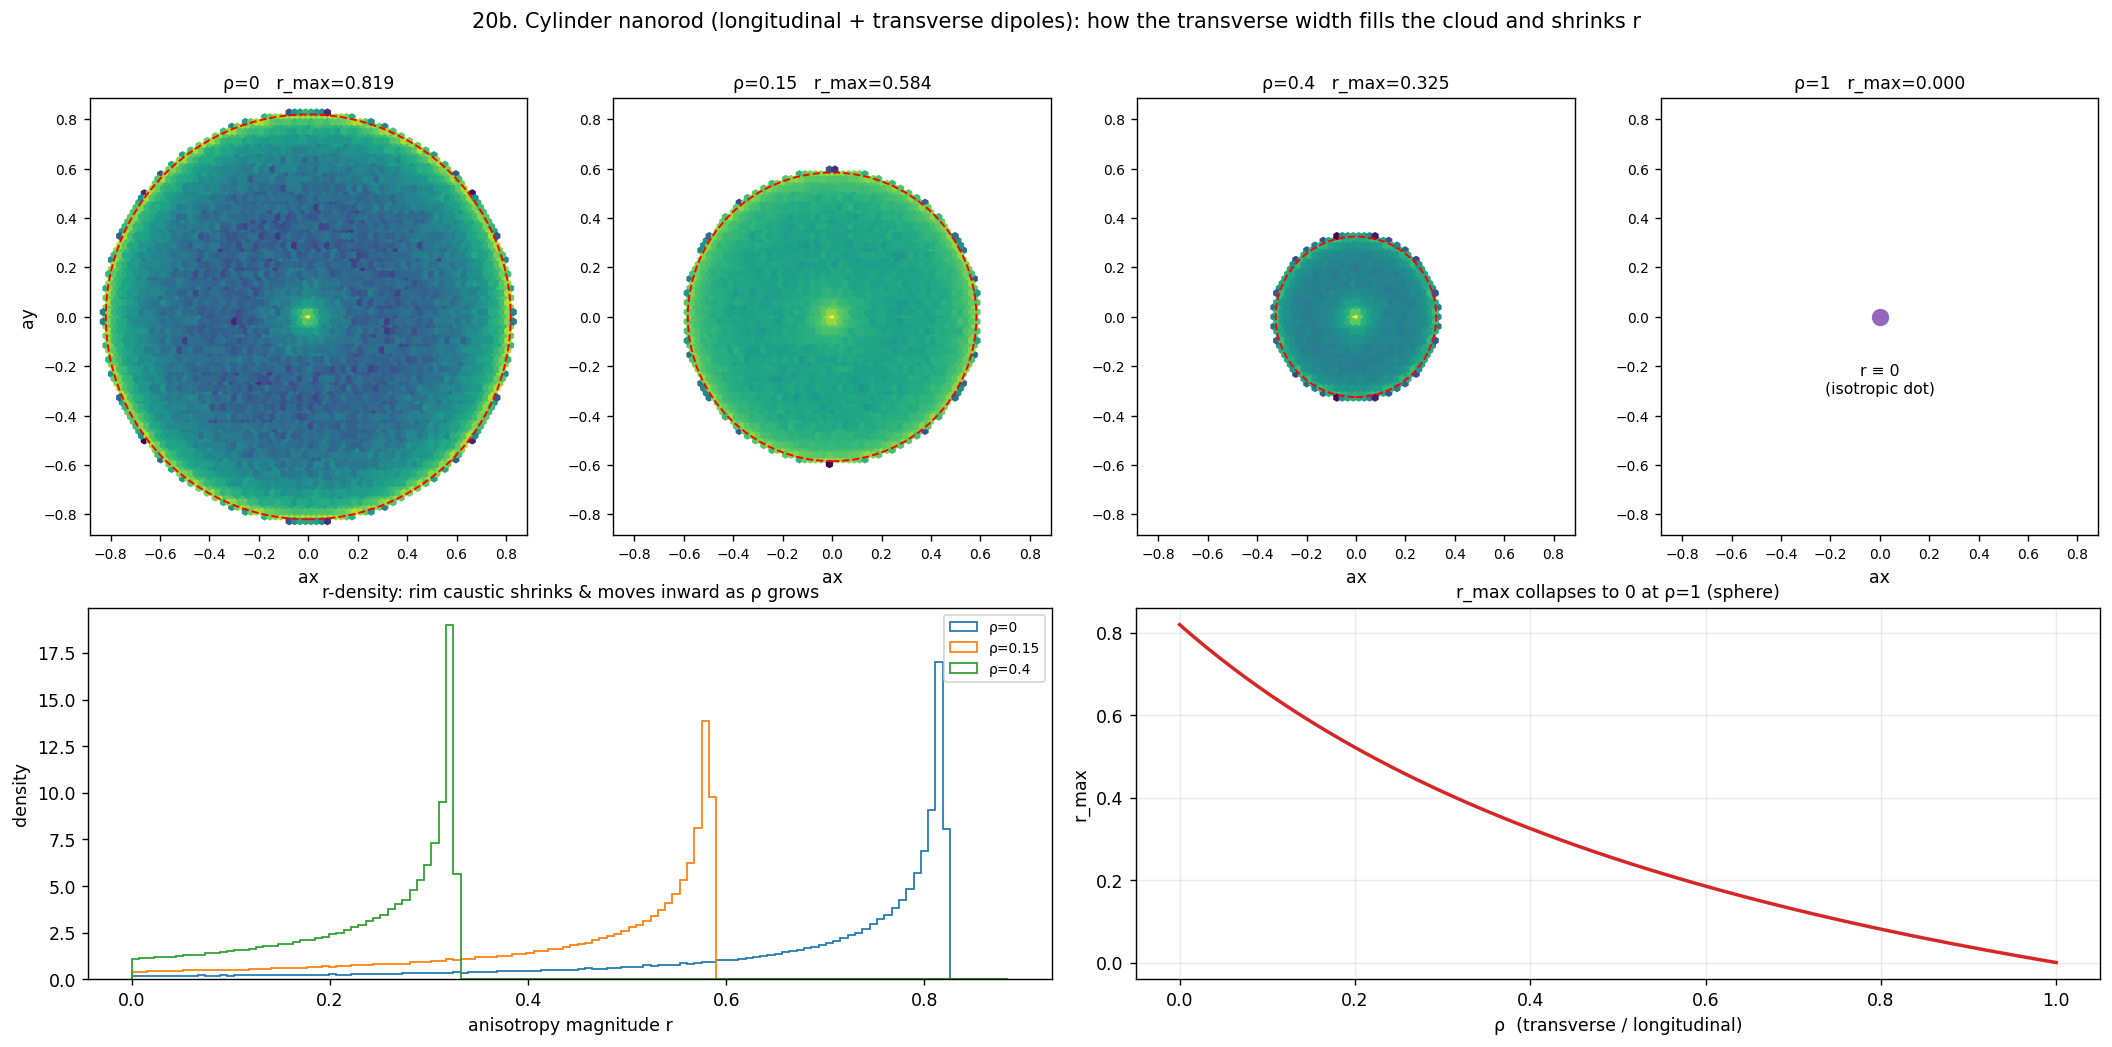

cylinder sim: N=300,000,  A=0.2573 B=0.6514 C=0.7446
    ρ   r_max     <r>   <r> (intensity-weighted)
 0.00   0.819   0.668                      0.718
 0.15   0.584   0.442                      0.469
 0.40   0.325   0.231                      0.239
 1.00   0.000   0.000                      0.000
  ρ>0 pulls the ring inward and fills the disk; a strong transverse
  component (large ρ) gives a small, centrally-filled cloud — NOT the
  sharp outer ring of an ideal rod. Intensity weighting shifts <r> up a
  little (in-plane orientations are brighter), but ρ is the big lever.
saved: C:\Users\denny\workspace\pyqtrod\data_analysed\Patricia\20250311\file\20_isotropic_sim\20b_cylinder_dipole_cloud_vs_rho.png


: 

In [ ]:
# ── 20b. Cylinder (longitudinal + transverse dipole) isotropic cloud vs ρ ─────
# A real nanorod is a CYLINDER: a strong LONGITUDINAL dipole along its long axis
# plus two (degenerate) weaker TRANSVERSE dipoles along its width. Model the
# emission as an INCOHERENT sum of Fourkas single-dipole intensities:
#     longitudinal  n̂            weight 1
#     transverse    ê1, ê2 ⟂ n̂   weight ρ each     (ρ = transverse/longitudinal)
# Per dipole d: DC += w(A + B(dx²+dy²)); Mod += wC(dx²−dy², 2 dx dy).
# Using n̂n̂ᵀ+ê1ê1ᵀ+ê2ê2ᵀ=I, the transverse pair's modulation is EXACTLY opposite
# the longitudinal and only adds DC, giving the closed form:
#     r(θ) = C(1−ρ)sin²θ / [A(1+2ρ) + 2ρB + B(1−ρ)sin²θ]
# ρ=0 → pure rod (bright ring at C/(A+B)); ρ=1 → isotropic sphere (r≡0, a dot).
rng = np.random.default_rng(1)
N_CYL = 300_000
A, B, C = A_cal, B_cal, C_cal

# isotropic long-axis orientations (cosθ uniform => ∝ sinθ), φ uniform
_cos = rng.uniform(-1.0, 1.0, N_CYL)
_th  = np.arccos(np.clip(_cos, -1.0, 1.0))
_ph  = rng.uniform(0.0, 2.0 * np.pi, N_CYL)
_s2  = np.sin(_th) ** 2                      # sin²θ of the LONG axis

RHOS = [0.0, 0.15, 0.4, 1.0]                 # transverse/longitudinal ratios to show

def _cyl_axay(rho):
    dc  = A * (1 + 2 * rho) + 2 * rho * B + B * (1 - rho) * _s2
    mod = C * (1 - rho) * _s2                 # modulation magnitude
    r   = mod / dc
    return r * np.cos(2 * _ph), r * np.sin(2 * _ph), r, dc

def _rmax(rho):
    return C * (1 - rho) / (A * (1 + 2 * rho) + B * (1 + rho))

fig = plt.figure(figsize=(17, 8.5), dpi=125)
gs  = fig.add_gridspec(2, len(RHOS), height_ratios=[1.0, 0.85])

# top row: anisotropy clouds (log color) for each ρ, on a shared axis range
_axlim = _rmax(0.0) * 1.08
for _j, _rho in enumerate(RHOS):
    axc = fig.add_subplot(gs[0, _j])
    _ax, _ay, _r, _dc = _cyl_axay(_rho)
    if _rho >= 1.0:
        axc.plot(0, 0, "o", color="tab:purple", ms=9)
        axc.text(0, -_axlim * 0.35, "r ≡ 0\n(isotropic dot)", ha="center", fontsize=9)
    else:
        axc.hexbin(_ax, _ay, gridsize=80, cmap="viridis", mincnt=1, bins="log",
                   extent=(-_axlim, _axlim, -_axlim, _axlim))
        axc.add_patch(plt.Circle((0, 0), _rmax(_rho), fill=False, color="red",
                                 lw=1.1, ls="--"))
    axc.set_xlim(-_axlim, _axlim); axc.set_ylim(-_axlim, _axlim)
    axc.set_aspect("equal"); axc.tick_params(labelsize=8)
    axc.set_title(f"ρ={_rho:g}   r_max={_rmax(_rho):.3f}", fontsize=10)
    if _j == 0:
        axc.set_ylabel("ay"); 
    axc.set_xlabel("ax")

# bottom-left: r-density curves overlaid for each ρ
axR = fig.add_subplot(gs[1, :2])
for _rho in RHOS:
    if _rho >= 1.0:
        continue
    _, _, _r, _ = _cyl_axay(_rho)
    axR.hist(_r, bins=120, range=(0, _axlim), density=True, histtype="step",
             lw=1.8, label=f"ρ={_rho:g}")
axR.set_xlabel("anisotropy magnitude r"); axR.set_ylabel("density")
axR.set_title("r-density: rim caustic shrinks & moves inward as ρ grows", fontsize=10)
axR.legend(fontsize=8)

# bottom-right: r_max vs ρ, and the effect of intensity (photon) weighting
axM = fig.add_subplot(gs[1, 2:])
_rr = np.linspace(0, 1, 200)
axM.plot(_rr, [_rmax(x) for x in _rr], color="tab:red", lw=2)
axM.set_xlabel("ρ  (transverse / longitudinal)"); axM.set_ylabel("r_max")
axM.set_title("r_max collapses to 0 at ρ=1 (sphere)", fontsize=10)
axM.grid(alpha=0.25)

fig.suptitle("20b. Cylinder nanorod (longitudinal + transverse dipoles): how the "
             "transverse width fills the cloud and shrinks r", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.955])
_20dir = _output_dir / "20_isotropic_sim"; _20dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_20dir / "20b_cylinder_dipole_cloud_vs_rho.png", dpi=140, bbox_inches="tight")
plt.show()

# intensity(DC)-weighted vs unweighted r-mean, to flag the dim-orientation dropout
print(f"cylinder sim: N={N_CYL:,},  A={A:.4g} B={B:.4g} C={C:.4g}")
print(f"{'ρ':>5} {'r_max':>7} {'<r>':>7} {'<r> (intensity-weighted)':>26}")
for _rho in RHOS:
    _, _, _r, _dc = _cyl_axay(_rho)
    _rw = np.average(_r, weights=_dc)         # brighter orientations dominate
    print(f"{_rho:>5.2f} {_rmax(_rho):>7.3f} {_r.mean():>7.3f} {_rw:>26.3f}")
print("  ρ>0 pulls the ring inward and fills the disk; a strong transverse")
print("  component (large ρ) gives a small, centrally-filled cloud — NOT the")
print("  sharp outer ring of an ideal rod. Intensity weighting shifts <r> up a")
print("  little (in-plane orientations are brighter), but ρ is the big lever.")
print(f"saved: {_20dir / '20b_cylinder_dipole_cloud_vs_rho.png'}")
